In [1]:
import sqlite3
from collections import defaultdict
import matplotlib.pyplot as plt

## Load Data from Database

In [2]:
def load_combinations(db_path='global.db', username=None):
    """
    Load all combinations from the database, optionally filtered by username.
    Returns combinations sorted by perUserRank (chronological order of discovery).
    """
    conn = sqlite3.connect(db_path)
    cursor = conn.cursor()
    
    if username:
        cursor.execute("""
            SELECT firstWord, secondWord, resultName, perUserRank
            FROM combinations
            WHERE username = ?
            ORDER BY perUserRank ASC
        """, (username,))
    else:
        # For global view, we need to find the earliest discovery of each combination
        # Group by the combination and take the minimum perUserRank
        cursor.execute("""
            SELECT firstWord, secondWord, resultName, MIN(perUserRank) as min_rank
            FROM combinations
            WHERE perUserRank IS NOT NULL
            GROUP BY firstWord, secondWord, resultName
            ORDER BY min_rank ASC
        """)
    
    combinations = []
    for row in cursor.fetchall():
        combinations.append({
            'from1': row[0],
            'from2': row[1],
            'to': row[2],
            'rank': row[3]
        })
    
    conn.close()
    return combinations

def load_material_ranks(db_path='global.db', username=None):
    """
    Load the rank of each material.
    Rank is the minimum perUserRank from combinations where the word is the result.
    Optionally filtered by username.
    """
    conn = sqlite3.connect(db_path)
    cursor = conn.cursor()
    
    if username:
        cursor.execute("""
            SELECT resultName, MIN(perUserRank) as min_rank
            FROM combinations
            WHERE perUserRank IS NOT NULL AND username = ?
            GROUP BY resultName
        """, (username,))
    else:
        cursor.execute("""
            SELECT resultName, MIN(perUserRank) as min_rank
            FROM combinations
            WHERE perUserRank IS NOT NULL
            GROUP BY resultName
        """)
    
    ranks = {}
    for row in cursor.fetchall():
        ranks[row[0]] = row[1]
    
    conn.close()
    return ranks

def get_top_users(db_path='global.db', n=4):
    """Get the top n users by number of combinations."""
    conn = sqlite3.connect(db_path)
    cursor = conn.cursor()
    
    cursor.execute("""
        SELECT username, COUNT(*) as combo_count
        FROM combinations
        GROUP BY username
        ORDER BY combo_count DESC
        LIMIT ?
    """, (n,))
    
    users = [(row[0], row[1]) for row in cursor.fetchall()]
    conn.close()
    return users

In [3]:
print("Loading combinations from database...")
combinations = load_combinations()
print(f"Loaded {len(combinations)} unique combinations")

print("\nLoading material ranks...")
material_ranks = load_material_ranks()
print(f"Loaded ranks for {len(material_ranks)} materials")

Loading combinations from database...
Loaded 11132 unique combinations

Loading material ranks...
Loaded ranks for 4846 materials


## Build Recipe Map

In [4]:
def build_recipe_map(combinations):
    """
    Build a map of result -> (ingredient1, ingredient2).
    
    IMPORTANT: Combinations must be sorted by perUserRank (chronologically).
    This ensures we only store the FIRST recipe for each result, which is the
    "shortest path" recipe that determined the material's rank.
    """
    recipe_map = {}
    for combo in combinations:
        result = combo['to']
        # Only store the first recipe we encounter (lowest rank = earliest discovery)
        if result not in recipe_map:
            recipe_map[result] = (combo['from1'], combo['from2'])
    return recipe_map

In [5]:
print("Building recipe map...")
recipe_map = build_recipe_map(combinations)
print(f"Built recipe map with {len(recipe_map)} results")

Building recipe map...
Built recipe map with 4846 results


## Count Transitive Dependencies (Shortest Path Only)

For each material, count how many other materials transitively depend on it **via the shortest recipe path**.

**Key insight:** A material's `perUserRank` is determined by the FIRST recipe that creates it (the "shortest path"). We should only count dependencies through this first recipe, not through all possible recipes.

**Algorithm:**
1. Process combinations in chronological order (sorted by perUserRank)
2. For each material, store only the FIRST recipe that creates it (the one that determined its rank)
3. Build dependency sets by tracing back through this "shortest recipe map"
4. Count how many materials depend on each material via their shortest paths

In [6]:
def count_dependencies(combinations, recipe_map):
    """
    For each material, count how many other materials transitively depend on it
    via the SHORTEST recipe path (the first recipe that creates each material).
    
    This matches how perUserRank is calculated - only counting dependencies
    through the recipe that first discovered each material.
    """
    
    base_materials = {'Fire', 'Water', 'Earth', 'Air'}
    
    # For each material, compute the set of materials it depends on (via shortest path)
    # We'll use the recipe_map which contains only the first recipe for each result
    dependencies = {}  # material -> set of materials it depends on
    
    # Initialize base materials (they depend on nothing)
    for base in base_materials:
        dependencies[base] = set()
    
    def get_dependencies(material, visited=None):
        """Recursively get all materials this material depends on via shortest path."""
        if visited is None:
            visited = set()
        
        if material in dependencies:
            return dependencies[material]
        
        if material in visited:
            # Cycle detected, return empty set
            return set()
        visited.add(material)
        
        if material in base_materials:
            dependencies[material] = set()
            return set()
        
        # Get the FIRST (shortest) recipe for this material
        if material not in recipe_map:
            # No recipe found, treat as base material
            dependencies[material] = set()
            return set()
        
        from1, from2 = recipe_map[material]
        
        # Get dependencies for both ingredients
        deps1 = get_dependencies(from1, visited.copy())
        deps2 = get_dependencies(from2, visited.copy())
        
        # This material depends on both ingredients and all their dependencies
        result_deps = set()
        result_deps.add(from1)
        result_deps.add(from2)
        result_deps.update(deps1)
        result_deps.update(deps2)
        
        dependencies[material] = result_deps
        return result_deps
    
    # Compute dependencies for all materials in the recipe map
    for material in recipe_map.keys():
        get_dependencies(material)
    
    # Now count how many materials depend on each material (via shortest path)
    material_usage = defaultdict(int)
    
    for result, deps in dependencies.items():
        # Skip base materials in the count (they're not "recipes")
        if result not in base_materials:
            # This material depends on all materials in deps via its shortest path
            for material in deps:
                material_usage[material] += 1
    
    return material_usage

In [7]:
print("Counting transitive dependencies...")
material_usage = count_dependencies(combinations, recipe_map)
print(f"Analyzed {len(material_usage)} materials")

Counting transitive dependencies...
Analyzed 3433 materials


## Materials by Number of Recipes That Depend on Them

In [8]:
# Sort by usage count (descending)
sorted_materials = sorted(material_usage.items(), key=lambda x: x[1], reverse=True)

print("=" * 100)
print("MATERIALS BY NUMBER OF RECIPES THAT DEPEND ON THEM")
print("=" * 100)
print(f"{'Material':<30} {'Rank':>10} {'Dependencies':>15} {'Dep/Rank Ratio':>15}")
print("-" * 100)

# Calculate ratios
ratios = []
for material, count in sorted_materials:
    rank = material_ranks.get(material)
    if rank and rank > 0:
        ratio = count / rank
        ratios.append(ratio)
        print(f"{material:<30} {rank:>10,} {count:>15,} {ratio:>15.2f}")
    else:
        print(f"{material:<30} {'N/A':>10} {count:>15,} {'N/A':>15}")

print("-" * 100)
print(f"Total materials analyzed: {len(sorted_materials)}")

MATERIALS BY NUMBER OF RECIPES THAT DEPEND ON THEM
Material                             Rank    Dependencies  Dep/Rank Ratio
----------------------------------------------------------------------------------------------------
Earth                                   2           4,148         2074.00
Air                                   N/A           4,016             N/A
Water                                  11           3,953          359.36
Planet                                  1           3,557         3557.00
Mud                                     1           3,445         3445.00
Fire                                  N/A           3,424             N/A
Dirt                                    1           3,363         3363.00
Dust                                    2           3,098         1549.00
Atmosphere                              2           3,059         1529.50
Oxygen                                  3           3,013         1004.33
Inspiration                       

## Average Dependencies-to-Rank Ratio

In [9]:
if ratios:
    avg_ratio = sum(ratios) / len(ratios)
    print(f"Average Dependencies-to-Rank Ratio: {avg_ratio:.4f}")
    print(f"Number of materials with valid ratios: {len(ratios)}")

Average Dependencies-to-Rank Ratio: 34.1619
Number of materials with valid ratios: 2250


## Top 10 Most Critical Materials (by dependency count)

In [10]:
print("=" * 100)
print("TOP 10 MOST CRITICAL MATERIALS (by dependency count)")
print("=" * 100)
for i, (material, count) in enumerate(sorted_materials[:10], 1):
    rank = material_ranks.get(material, 'N/A')
    rank_str = f"{rank:,}" if isinstance(rank, int) else rank
    print(f"{i:2d}. {material:<30} {count:>10,} recipes (Rank: {rank_str})")

TOP 10 MOST CRITICAL MATERIALS (by dependency count)
 1. Earth                               4,148 recipes (Rank: 2)
 2. Air                                 4,016 recipes (Rank: N/A)
 3. Water                               3,953 recipes (Rank: 11)
 4. Planet                              3,557 recipes (Rank: 1)
 5. Mud                                 3,445 recipes (Rank: 1)
 6. Fire                                3,424 recipes (Rank: N/A)
 7. Dirt                                3,363 recipes (Rank: 1)
 8. Dust                                3,098 recipes (Rank: 2)
 9. Atmosphere                          3,059 recipes (Rank: 2)
10. Oxygen                              3,013 recipes (Rank: 3)


## Top 20 Materials with Highest Dependency-to-Rank Ratio

These are materials that "punch above their weight" - many recipes depend on them relative to how early they appear in the game.

In [11]:
# Build list with ratios
materials_with_ratios = []
for material, count in material_usage.items():
    rank = material_ranks.get(material)
    if rank and rank > 0:
        ratio = count / rank
        materials_with_ratios.append((material, count, rank, ratio))

# Sort by ratio descending
materials_with_ratios.sort(key=lambda x: x[3], reverse=True)

print("=" * 100)
print("TOP 20 MATERIALS WITH HIGHEST DEPENDENCY-TO-RANK RATIO")
print("(Materials that punch above their weight - many depend on them relative to how early they appear)")
print("=" * 100)
print(f"{'Material':<30} {'Rank':>10} {'Dependencies':>15} {'Ratio':>15}")
print("-" * 100)
for i, (material, count, rank, ratio) in enumerate(materials_with_ratios[:20], 1):
    print(f"{i:2d}. {material:<27} {rank:>10,} {count:>15,} {ratio:>15.2f}")

TOP 20 MATERIALS WITH HIGHEST DEPENDENCY-TO-RANK RATIO
(Materials that punch above their weight - many depend on them relative to how early they appear)
Material                             Rank    Dependencies           Ratio
----------------------------------------------------------------------------------------------------
 1. Planet                               1           3,557         3557.00
 2. Mud                                  1           3,445         3445.00
 3. Dirt                                 1           3,363         3363.00
 4. Inspiration                          1           2,648         2648.00
 5. Steam                                1           2,578         2578.00
 6. Breeze                               1           2,509         2509.00
 7. Lava                                 1           2,452         2452.00
 8. Inferno                              1           2,440         2440.00
 9. Earth                                2           4,148         2074.

## Scatterplot: Rank vs Dependencies

Visualize the relationship between a material's rank (how early it appears) and how many recipes depend on it.

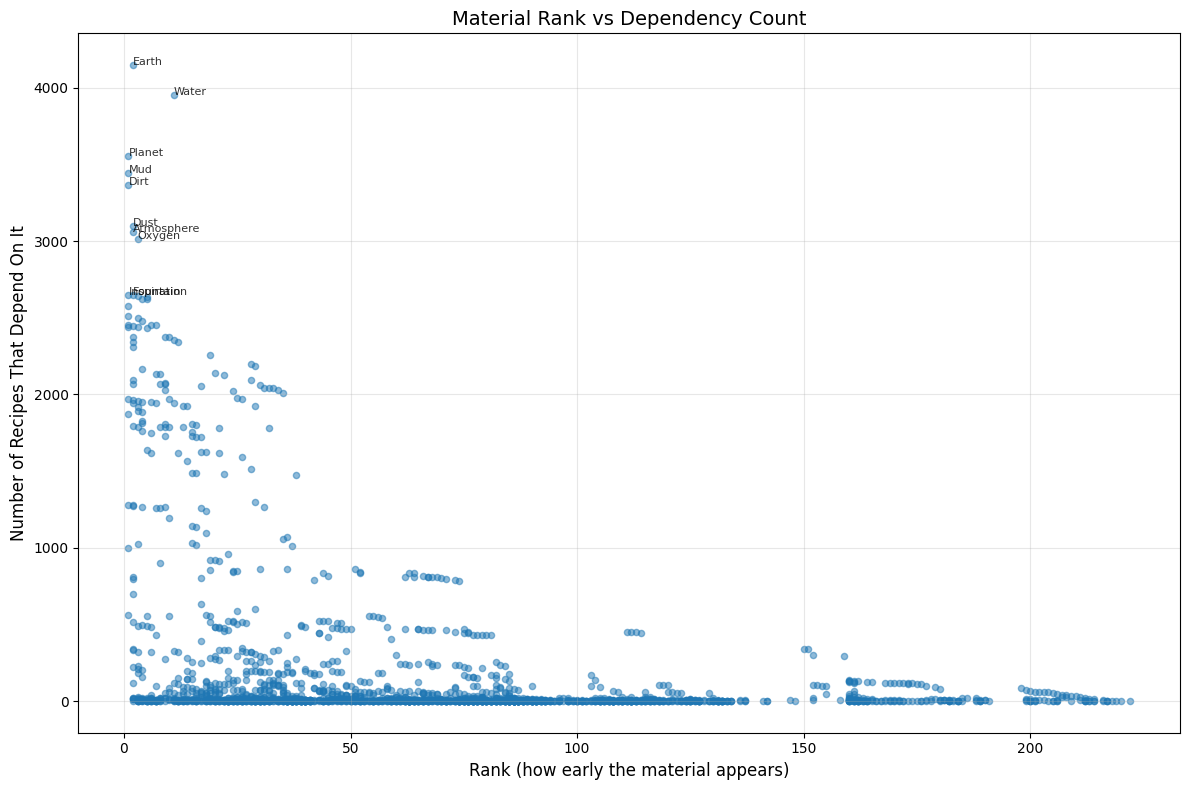

Plotted 2250 materials with valid ranks


In [12]:
# Prepare data for plotting
ranks_list = []
deps_list = []
names_list = []

for material, count in material_usage.items():
    rank = material_ranks.get(material)
    if rank and rank > 0:
        ranks_list.append(rank)
        deps_list.append(count)
        names_list.append(material)

# Create scatterplot
plt.figure(figsize=(12, 8))
plt.scatter(ranks_list, deps_list, alpha=0.5, s=20)

# Add labels for top materials (highest dependencies)
top_indices = sorted(range(len(deps_list)), key=lambda i: deps_list[i], reverse=True)[:10]
for i in top_indices:
    plt.annotate(names_list[i], (ranks_list[i], deps_list[i]), fontsize=8, alpha=0.8)

plt.xlabel('Rank (how early the material appears)', fontsize=12)
plt.ylabel('Number of Recipes That Depend On It', fontsize=12)
plt.title('Material Rank vs Dependency Count', fontsize=14)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Plotted {len(ranks_list)} materials with valid ranks")

## Modeling the Upper Bound

The graph shows a downward-sloping triangle pattern, suggesting that the **maximum possible dependencies** decreases linearly with rank. Let's fit a linear model to the upper envelope (the "ceiling" of dependencies for each rank) and identify outliers that exceed expectations.

In [13]:
import numpy as np
from scipy.optimize import curve_fit

# Convert to numpy arrays
ranks_arr = np.array(ranks_list)
deps_arr = np.array(deps_list)

# Bucket size for smoothing
BUCKET_SIZE = 5

# Find the upper envelope - bucket ranks into groups of size N, find max in each bucket
# Create bucket assignments (0, 5, 10, 15, ...)
bucket_assignments = (ranks_arr // BUCKET_SIZE) * BUCKET_SIZE + BUCKET_SIZE // 2  # center of bucket

unique_buckets = np.unique(bucket_assignments)
max_deps_per_bucket = []
max_material_per_bucket = []  # Track which material has max deps in each bucket

for bucket in unique_buckets:
    bucket_mask = bucket_assignments == bucket
    bucket_deps = deps_arr[bucket_mask]
    max_idx_in_bucket = np.argmax(bucket_deps)
    
    # Find the actual index in the original arrays
    bucket_indices = np.where(bucket_mask)[0]
    max_material_idx = bucket_indices[max_idx_in_bucket]
    
    max_deps_per_bucket.append(bucket_deps.max())
    max_material_per_bucket.append(names_list[max_material_idx])

max_deps_per_bucket = np.array(max_deps_per_bucket)

print(f"Bucketed {len(np.unique(ranks_arr))} unique ranks into {len(unique_buckets)} buckets (size={BUCKET_SIZE})")

# Define different models to fit
def linear_model(x, a, b):
    return a + b * x

def exponential_decay(x, a, b, c):
    return a * np.exp(-b * x) + c

def power_law(x, a, b, c):
    return a * (x + 1)**(-b) + c

def log_model(x, a, b, c):
    return a - b * np.log(x + 1) + c

# Fit each model to bucketed data
models = {}

# Linear fit
popt_linear, _ = curve_fit(linear_model, unique_buckets, max_deps_per_bucket)
models['Linear'] = {
    'func': linear_model,
    'params': popt_linear,
    'predict': lambda x: linear_model(x, *popt_linear)
}

# Exponential decay fit
try:
    popt_exp, _ = curve_fit(exponential_decay, unique_buckets, max_deps_per_bucket, 
                            p0=[3500, 0.01, 0], maxfev=10000)
    models['Exponential Decay'] = {
        'func': exponential_decay,
        'params': popt_exp,
        'predict': lambda x: exponential_decay(x, *popt_exp)
    }
except:
    print("Exponential decay fit failed")

# Power law fit
try:
    popt_power, _ = curve_fit(power_law, unique_buckets, max_deps_per_bucket,
                              p0=[3500, 0.5, 0], maxfev=10000)
    models['Power Law'] = {
        'func': power_law,
        'params': popt_power,
        'predict': lambda x: power_law(x, *popt_power)
    }
except:
    print("Power law fit failed")

# Log fit
try:
    popt_log, _ = curve_fit(log_model, unique_buckets, max_deps_per_bucket,
                            p0=[3500, 500, 0], maxfev=10000)
    models['Logarithmic'] = {
        'func': log_model,
        'params': popt_log,
        'predict': lambda x: log_model(x, *popt_log)
    }
except:
    print("Logarithmic fit failed")

# Calculate R² for each model
def calc_r2(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred)**2)
    ss_tot = np.sum((y_true - np.mean(y_true))**2)
    return 1 - (ss_res / ss_tot)

print("=" * 80)
print(f"MODEL COMPARISON (fitted to upper envelope, bucket size={BUCKET_SIZE})")
print("=" * 80)
print(f"{'Model':<20} {'R²':>12} {'Parameters'}")
print("-" * 80)

for name, model in models.items():
    y_pred = model['predict'](unique_buckets)
    r2 = calc_r2(max_deps_per_bucket, y_pred)
    model['r2'] = r2
    params_str = ', '.join([f'{p:.4f}' for p in model['params']])
    print(f"{name:<20} {r2:>12.6f} {params_str}")

# Find best model
best_model_name = max(models, key=lambda k: models[k]['r2'])
best_model = models[best_model_name]
print("-" * 80)
print(f"Best fit: {best_model_name} (R² = {best_model['r2']:.6f})")

Bucketed 202 unique ranks into 45 buckets (size=5)
MODEL COMPARISON (fitted to upper envelope, bucket size=5)
Model                          R² Parameters
--------------------------------------------------------------------------------
Linear                   0.586628 2032.4746, -12.0755
Exponential Decay        0.933397 4229.4110, 0.0289, 20.6677
Power Law                0.887710 12694.3591, 0.1291, -6535.8897
Logarithmic              0.879466 299231.8329, 1022.9346, -294013.9575
--------------------------------------------------------------------------------
Best fit: Exponential Decay (R² = 0.933397)


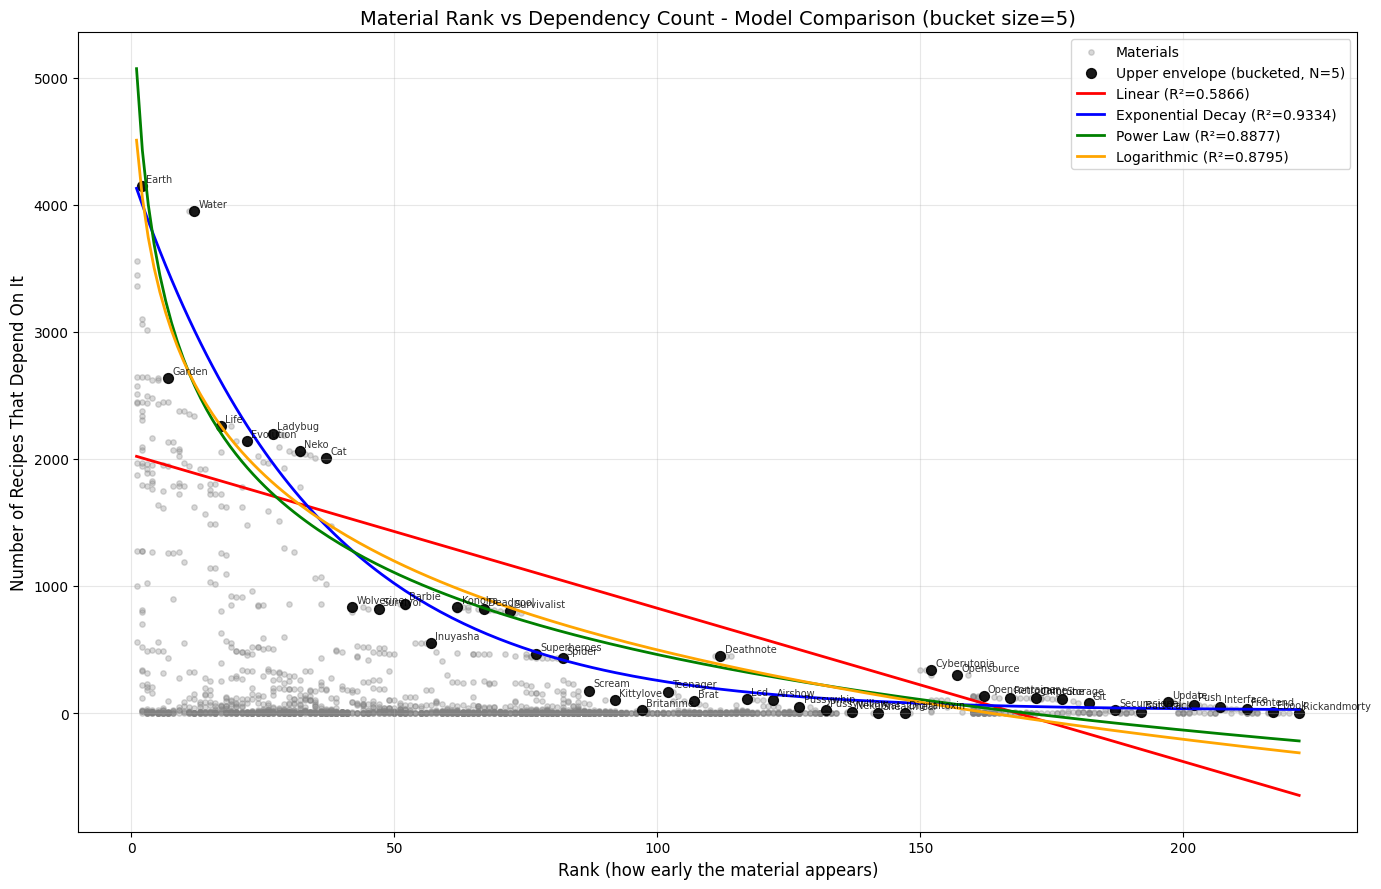

In [14]:
# Plot all models
plt.figure(figsize=(14, 9))
plt.scatter(ranks_arr, deps_arr, alpha=0.3, s=15, label='Materials', c='gray')
plt.scatter(unique_buckets, max_deps_per_bucket, c='black', s=50, alpha=0.9, 
            label=f'Upper envelope (bucketed, N={BUCKET_SIZE})')

# Label the max material in each bucket
for i, (bucket, deps, material) in enumerate(zip(unique_buckets, max_deps_per_bucket, max_material_per_bucket)):
    plt.annotate(material, (bucket, deps), fontsize=7, alpha=0.8,
                 xytext=(3, 3), textcoords='offset points')

x_line = np.linspace(1, max(unique_buckets), 200)

colors = ['red', 'blue', 'green', 'orange', 'purple']
for (name, model), color in zip(models.items(), colors):
    y_line = model['predict'](x_line)
    plt.plot(x_line, y_line, color=color, linewidth=2, 
             label=f"{name} (R²={model['r2']:.4f})")

plt.xlabel('Rank (how early the material appears)', fontsize=12)
plt.ylabel('Number of Recipes That Depend On It', fontsize=12)
plt.title(f'Material Rank vs Dependency Count - Model Comparison (bucket size={BUCKET_SIZE})', fontsize=14)
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Using Exponential Decay model for outlier detection


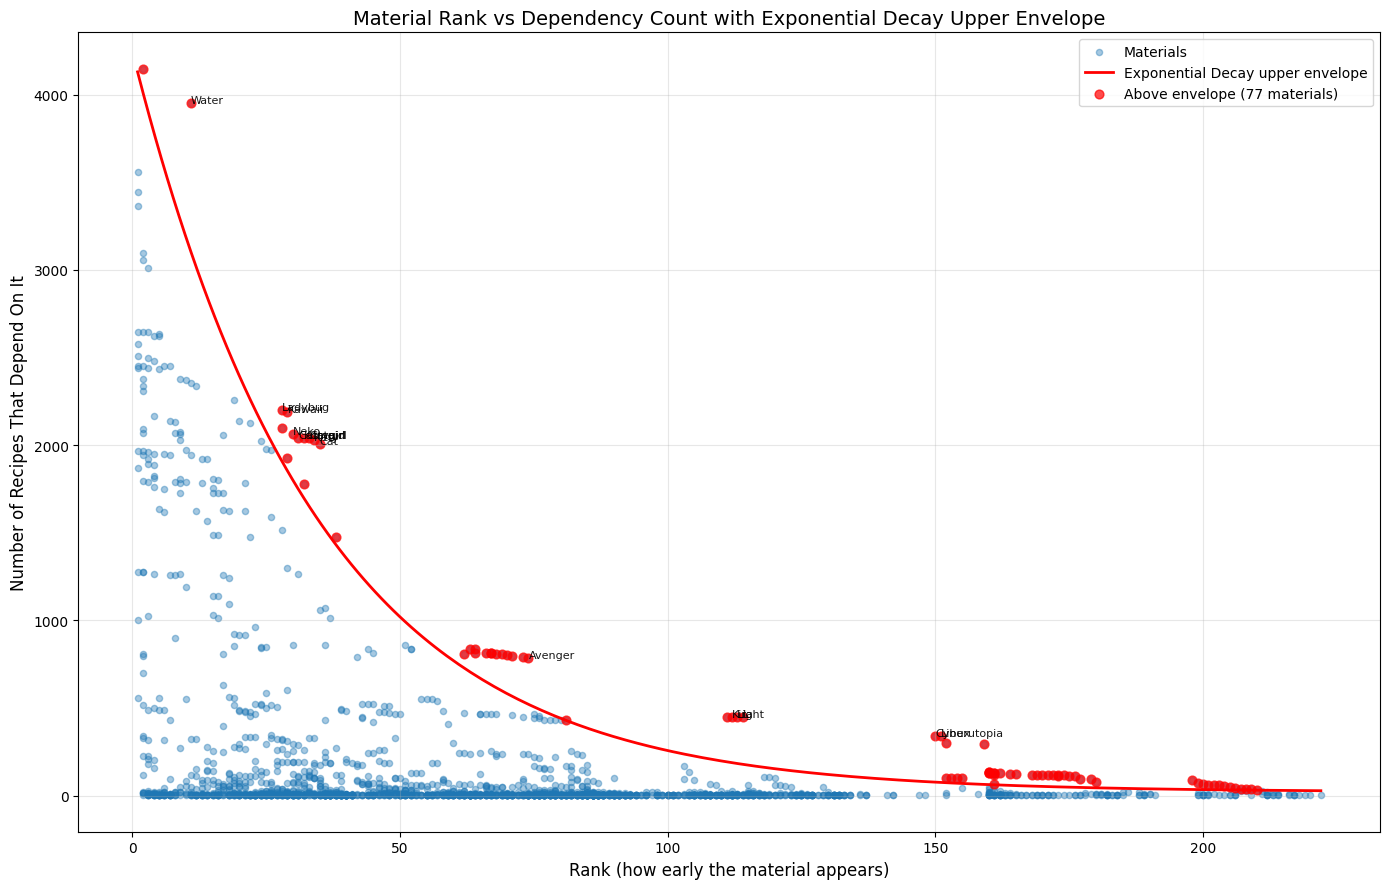

In [15]:
# Use the best model for outlier detection
print(f"\nUsing {best_model_name} model for outlier detection")

# Calculate expected max and residuals using best model
expected_max = best_model['predict'](ranks_arr)
residuals = deps_arr - expected_max

# Plot with the best fit
plt.figure(figsize=(14, 9))
plt.scatter(ranks_arr, deps_arr, alpha=0.4, s=20, label='Materials')

# Plot the best model fit
x_line = np.linspace(1, max(ranks_arr), 200)
y_line = best_model['predict'](x_line)
plt.plot(x_line, y_line, 'r-', linewidth=2, label=f'{best_model_name} upper envelope')

# Highlight outliers (materials above the line)
outlier_threshold = 0
outlier_mask = residuals > outlier_threshold

plt.scatter(ranks_arr[outlier_mask], deps_arr[outlier_mask], 
            c='red', s=40, alpha=0.7, label=f'Above envelope ({outlier_mask.sum()} materials)')

# Label the most extreme outliers
outlier_indices = np.where(outlier_mask)[0]
sorted_outlier_indices = sorted(outlier_indices, key=lambda i: residuals[i], reverse=True)[:15]
for i in sorted_outlier_indices:
    plt.annotate(names_list[i], (ranks_arr[i], deps_arr[i]), fontsize=8, alpha=0.9)

plt.xlabel('Rank (how early the material appears)', fontsize=12)
plt.ylabel('Number of Recipes That Depend On It', fontsize=12)
plt.title(f'Material Rank vs Dependency Count with {best_model_name} Upper Envelope', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Major Outliers: Materials with Unusually High Dependencies for Their Rank

These materials have more recipes depending on them than expected based on the upper envelope model. They "punch above their weight" for how late they appear in the game.

In [16]:
# Build a list of outliers with their stats (using best model)
outliers_data = []
for i in range(len(names_list)):
    rank = ranks_arr[i]
    deps = deps_arr[i]
    expected = best_model['predict'](np.array([rank]))[0]
    residual = deps - expected
    if residual > 0:  # Above the upper envelope
        outliers_data.append({
            'name': names_list[i],
            'rank': rank,
            'dependencies': deps,
            'expected_max': expected,
            'excess': residual,
            'excess_pct': (residual / expected) * 100 if expected > 0 else float('inf')
        })

# Sort by excess (how much above expected)
outliers_data.sort(key=lambda x: x['excess'], reverse=True)

print("=" * 110)
print(f"MAJOR OUTLIERS: Materials with Dependencies ABOVE the {best_model_name} Upper Envelope")
print("=" * 110)
print(f"{'Material':<25} {'Rank':>8} {'Actual Deps':>12} {'Expected Max':>14} {'Excess':>10} {'Excess %':>10}")
print("-" * 110)

for item in outliers_data[:30]:
    print(f"{item['name']:<25} {item['rank']:>8} {item['dependencies']:>12,} {item['expected_max']:>14,.0f} {item['excess']:>10,.0f} {item['excess_pct']:>9.1f}%")

print("-" * 110)
print(f"Total materials above upper envelope: {len(outliers_data)}")
print(f"\nThese materials have unusually high dependency counts for how late they appear in the game.")

MAJOR OUTLIERS: Materials with Dependencies ABOVE the Exponential Decay Upper Envelope
Material                      Rank  Actual Deps   Expected Max     Excess   Excess %
--------------------------------------------------------------------------------------------------------------
Water                           11        3,953          3,100        853      27.5%
Cat                             35        2,007          1,561        446      28.6%
Kitty                           34        2,030          1,606        424      26.4%
Catgirl                         33        2,039          1,653        386      23.4%
Kittygirl                       32        2,040          1,701        339      20.0%
Kawaii                          29        2,187          1,852        335      18.1%
Ladybug                         28        2,200          1,906        294      15.4%
Catmaid                         31        2,043          1,750        293      16.8%
L                              114   

In [17]:
# Focus on the most interesting outliers - those with high rank but still high dependencies
# Filter to materials with rank > 50 that still have high excess
late_outliers = [o for o in outliers_data if o['rank'] > 50]
late_outliers.sort(key=lambda x: x['excess'], reverse=True)

print("=" * 110)
print("LATE-GAME OUTLIERS: Materials with rank > 50 that still have high dependencies")
print("=" * 110)
print(f"{'Material':<25} {'Rank':>8} {'Actual Deps':>12} {'Expected Max':>14} {'Excess':>10} {'Excess %':>10}")
print("-" * 110)

for item in late_outliers[:20]:
    print(f"{item['name']:<25} {item['rank']:>8} {item['dependencies']:>12,} {item['expected_max']:>14,.0f} {item['excess']:>10,.0f} {item['excess_pct']:>9.1f}%")

print("-" * 110)
print(f"Total late-game outliers (rank > 50): {len(late_outliers)}")

LATE-GAME OUTLIERS: Materials with rank > 50 that still have high dependencies
Material                      Rank  Actual Deps   Expected Max     Excess   Excess %
--------------------------------------------------------------------------------------------------------------
L                              114          447            178        269     150.7%
Avenger                         74          786            521        265      51.0%
Light                          113          448            183        265     144.9%
Linux                          151          338             75        263     351.4%
Cyberutopia                    150          339             76        263     343.4%
Kira                           112          449            188        261     139.2%
Deathnote                      111          450            193        257     133.7%
Superhero                       73          791            535        256      47.8%
Opensource                     159          2

## Per-User Outlier Analysis

Analyze the major outliers for each of the top 4 users by examining their individual subgraphs.

In [18]:
# Get top 4 users
top_users = get_top_users(n=4)
print("Top 4 users by combination count:")
for username, count in top_users:
    print(f"  {username}: {count:,} combinations")

Top 4 users by combination count:
  isabel: 4,916 combinations
  tim: 2,179 combinations
  ace: 1,378 combinations
  izzy: 1,191 combinations


In [19]:
def analyze_user_outliers(username, top_n=15):
    """Analyze dependency outliers for a specific user's subgraph."""
    
    # Load user-specific data
    user_combinations = load_combinations(username=username)
    user_ranks = load_material_ranks(username=username)
    
    if len(user_combinations) == 0:
        print(f"No combinations found for user {username}")
        return None
    
    # Build recipe map and count dependencies
    user_recipe_map = build_recipe_map(user_combinations)
    user_material_usage = count_dependencies(user_combinations, user_recipe_map)
    
    # Prepare data for analysis
    user_ranks_list = []
    user_deps_list = []
    user_names_list = []
    
    for material, count in user_material_usage.items():
        rank = user_ranks.get(material)
        if rank and rank > 0:
            user_ranks_list.append(rank)
            user_deps_list.append(count)
            user_names_list.append(material)
    
    if len(user_ranks_list) < 10:
        print(f"Not enough data points for user {username} ({len(user_ranks_list)} materials with valid ranks)")
        return None
    
    user_ranks_arr = np.array(user_ranks_list)
    user_deps_arr = np.array(user_deps_list)
    
    # Find upper envelope for this user (with bucketing)
    user_unique_ranks_raw = np.unique(user_ranks_arr)
    user_max_deps_raw = []
    for r in user_unique_ranks_raw:
        user_max_deps_raw.append(user_deps_arr[user_ranks_arr == r].max())
    user_max_deps_raw = np.array(user_max_deps_raw)
    
    # Bucket the ranks for smoother fitting and track max materials
    user_bucket_centers = []
    user_max_deps_bucketed = []
    user_max_materials_bucketed = []  # Track max material name per bucket
    
    for bucket_start in range(int(min(user_unique_ranks_raw)), int(max(user_unique_ranks_raw)) + 1, BUCKET_SIZE):
        bucket_end = bucket_start + BUCKET_SIZE
        # Find materials in this bucket range (using original data, not unique ranks)
        bucket_mask = (user_ranks_arr >= bucket_start) & (user_ranks_arr < bucket_end)
        if bucket_mask.any():
            bucket_deps = user_deps_arr[bucket_mask]
            max_idx_in_bucket = np.argmax(bucket_deps)
            bucket_indices = np.where(bucket_mask)[0]
            max_material_idx = bucket_indices[max_idx_in_bucket]
            
            user_bucket_centers.append(bucket_start + BUCKET_SIZE / 2)
            user_max_deps_bucketed.append(bucket_deps.max())
            user_max_materials_bucketed.append(user_names_list[max_material_idx])
    
    user_bucket_centers = np.array(user_bucket_centers)
    user_max_deps_bucketed = np.array(user_max_deps_bucketed)
    
    # Fit exponential decay model to bucketed data
    try:
        popt, _ = curve_fit(exponential_decay, user_bucket_centers, user_max_deps_bucketed,
                           p0=[max(user_max_deps_bucketed), 0.01, 0], maxfev=10000)
        user_model = lambda x, p=popt: exponential_decay(x, *p)
        model_name = "Exponential Decay"
    except:
        # Fall back to linear on bucketed data
        popt, _ = curve_fit(linear_model, user_bucket_centers, user_max_deps_bucketed)
        user_model = lambda x, p=popt: linear_model(x, *p)
        model_name = "Linear"
    
    # Calculate residuals
    user_expected = user_model(user_ranks_arr)
    user_residuals = user_deps_arr - user_expected
    
    # Find outliers
    user_outliers = []
    for i in range(len(user_names_list)):
        rank = user_ranks_arr[i]
        deps = user_deps_arr[i]
        expected = user_expected[i]
        residual = user_residuals[i]
        if residual > 0:
            user_outliers.append({
                'name': user_names_list[i],
                'rank': rank,
                'dependencies': deps,
                'expected_max': expected,
                'excess': residual,
                'excess_pct': (residual / expected) * 100 if expected > 0 else 0
            })
    
    user_outliers.sort(key=lambda x: x['excess'], reverse=True)
    
    return {
        'username': username,
        'total_combinations': len(user_combinations),
        'materials_analyzed': len(user_names_list),
        'model': model_name,
        'model_func': user_model,
        'outliers': user_outliers[:top_n],
        'ranks_arr': user_ranks_arr,
        'deps_arr': user_deps_arr,
        'names_list': user_names_list,
        'unique_ranks': user_unique_ranks_raw,
        'max_deps': user_max_deps_raw,
        'bucket_centers': user_bucket_centers,
        'max_deps_bucketed': user_max_deps_bucketed,
        'max_materials_bucketed': user_max_materials_bucketed,
        'residuals': user_residuals
    }

# Analyze each top user
user_analyses = {}
for username, combo_count in top_users:
    print(f"\nAnalyzing {username}...")
    result = analyze_user_outliers(username)
    if result:
        user_analyses[username] = result


Analyzing isabel...

Analyzing tim...

Analyzing ace...

Analyzing izzy...


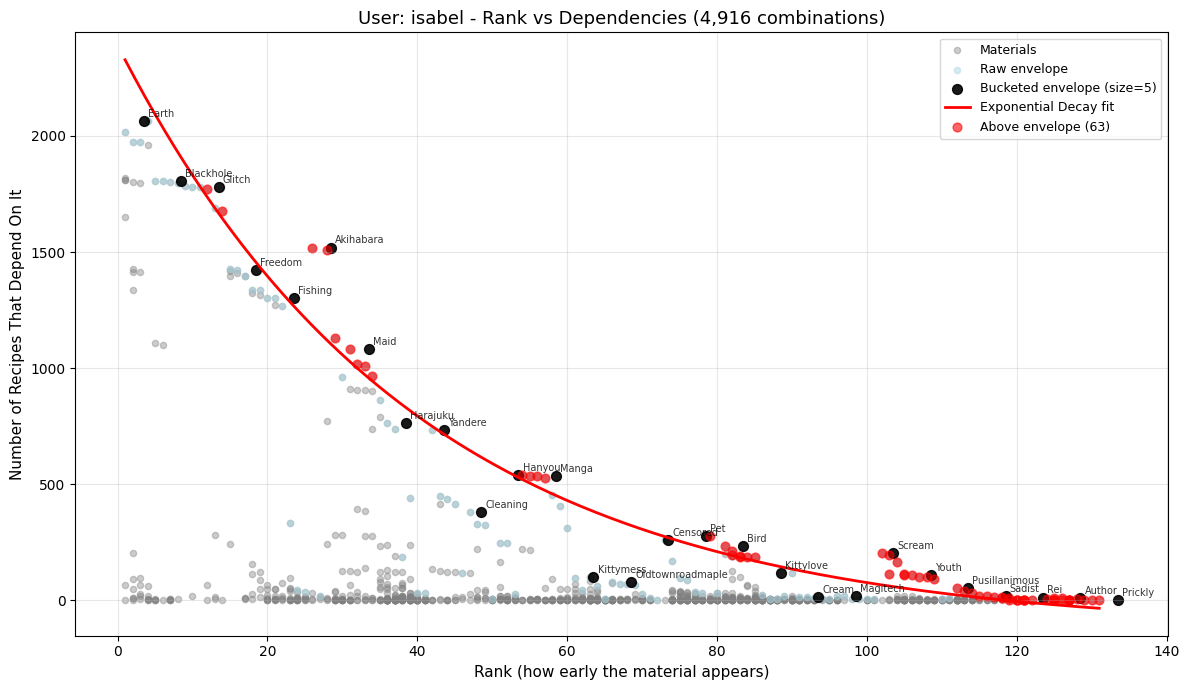

MAJOR OUTLIERS FOR USER: isabel
Total combinations: 4,916 | Materials analyzed: 1,139 | Model: Exponential Decay
Material                           Rank  Actual Deps   Expected Max     Excess   Excess %
--------------------------------------------------------------------------------------------------------------
Moe                                  28        1,511          1,119        392      35.1%
Akihabara                            26        1,519          1,183        336      28.4%
Scream                              102          203             67        136     204.9%
Teenager                            103          196             62        134     217.4%
Children                            104          164             57        107     187.5%
Youth                               106          108             48         60     125.0%
Phobia                              108           99             39         60     151.4%
Oldtownroadkids                     105          112    

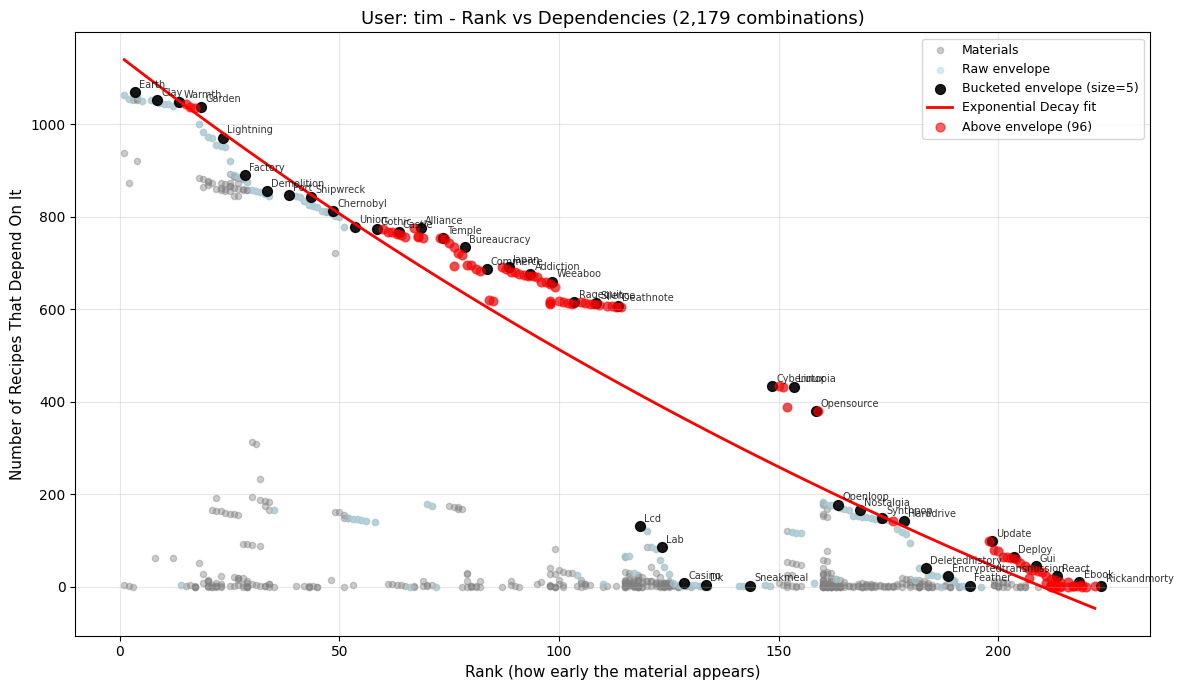

MAJOR OUTLIERS FOR USER: tim
Total combinations: 2,179 | Materials analyzed: 703 | Model: Exponential Decay
Material                           Rank  Actual Deps   Expected Max     Excess   Excess %
--------------------------------------------------------------------------------------------------------------
Linux                               151          433            255        178      70.0%
Cyberutopia                         150          434            259        175      67.3%
L                                   114          605            438        167      38.1%
Light                               113          606            443        163      36.7%
Opensource                          159          380            218        162      74.6%
Kira                                112          607            449        158      35.3%
Deathnote                           111          608            454        154      33.9%
Antihero                            109          610         

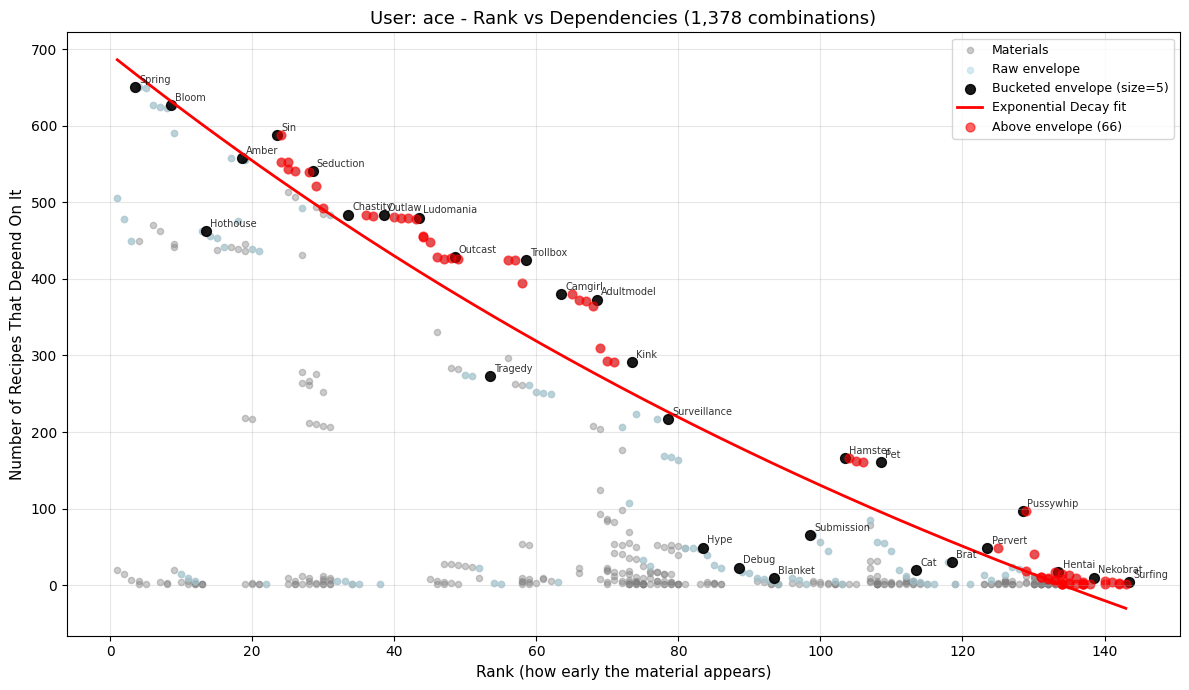

MAJOR OUTLIERS FOR USER: ace
Total combinations: 1,378 | Materials analyzed: 464 | Model: Exponential Decay
Material                           Rank  Actual Deps   Expected Max     Excess   Excess %
--------------------------------------------------------------------------------------------------------------
Internet                             57          424            335         89      26.7%
Pornstar                             67          371            283         88      31.3%
Camgirl                              65          380            293         87      29.8%
Orgy                                 68          364            278         86      31.1%
Adultmodel                           66          373            288         85      29.6%
Trollbox                             56          425            340         85      25.0%
Pussywhip                           129           97             18         79     441.5%
Porn                                 58          395         

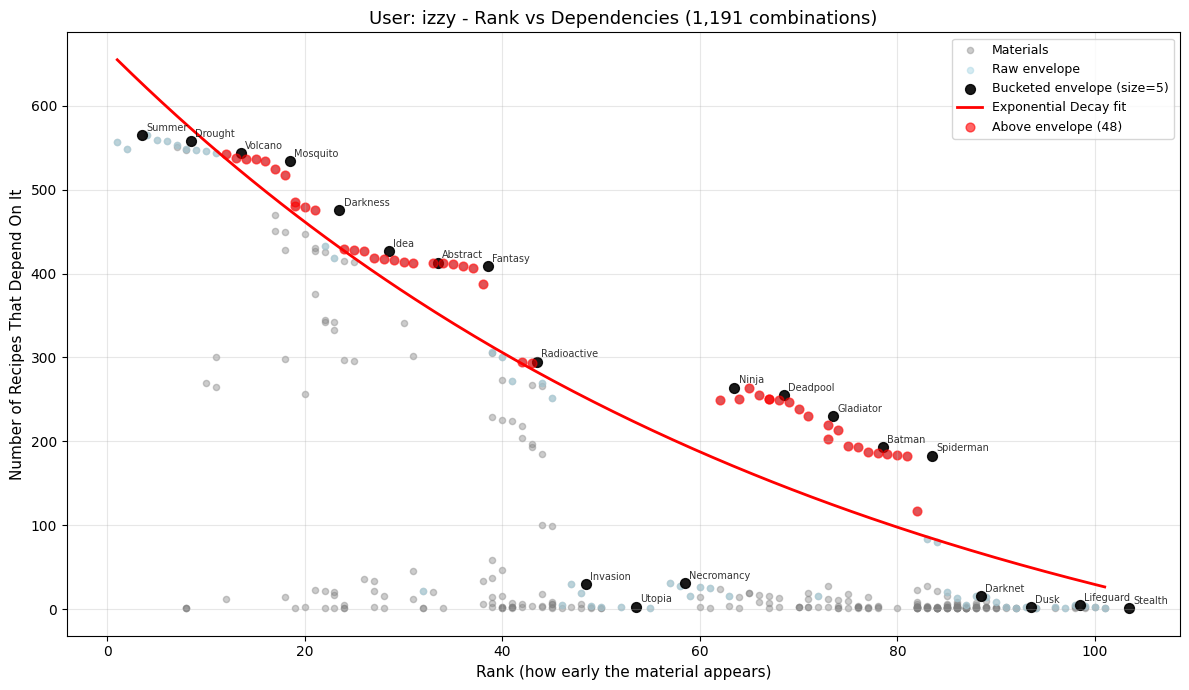

MAJOR OUTLIERS FOR USER: izzy
Total combinations: 1,191 | Materials analyzed: 354 | Model: Exponential Decay
Material                           Rank  Actual Deps   Expected Max     Excess   Excess %
--------------------------------------------------------------------------------------------------------------
Conspiracy                           69          247            144        103      71.5%
Ninja                                65          264            163        101      62.3%
Cable                                68          249            149        100      67.6%
Survivalist                          70          238            140         98      70.6%
Xforce                               67          251            153         98      63.8%
Deadpool                             66          255            158         97      61.5%
Hellspawn                            67          250            153         97      63.2%
Gladiator                            71          230        

In [20]:
# Display graph and outliers for each user
for username, analysis in user_analyses.items():
    # Create the plot
    fig, ax = plt.subplots(figsize=(12, 7))
    
    # Scatter plot of all materials
    ax.scatter(analysis['ranks_arr'], analysis['deps_arr'], alpha=0.4, s=20, label='Materials', c='gray')
    
    # Plot upper envelope points (raw and bucketed)
    ax.scatter(analysis['unique_ranks'], analysis['max_deps'], c='lightblue', s=20, alpha=0.5, label='Raw envelope')
    ax.scatter(analysis['bucket_centers'], analysis['max_deps_bucketed'], c='black', s=50, alpha=0.9, 
               label=f'Bucketed envelope (size={BUCKET_SIZE})')
    
    # Label the max material in each bucket
    for bucket, deps, material in zip(analysis['bucket_centers'], analysis['max_deps_bucketed'], analysis['max_materials_bucketed']):
        ax.annotate(material, (bucket, deps), fontsize=7, alpha=0.8,
                    xytext=(3, 3), textcoords='offset points')
    
    # Plot the fitted model
    x_line = np.linspace(1, max(analysis['ranks_arr']), 200)
    y_line = analysis['model_func'](x_line)
    ax.plot(x_line, y_line, 'r-', linewidth=2, label=f"{analysis['model']} fit")
    
    # Highlight outliers
    outlier_mask = analysis['residuals'] > 0
    ax.scatter(analysis['ranks_arr'][outlier_mask], analysis['deps_arr'][outlier_mask], 
               c='red', s=40, alpha=0.6, label=f'Above envelope ({outlier_mask.sum()})')
    
    ax.set_xlabel('Rank (how early the material appears)', fontsize=11)
    ax.set_ylabel('Number of Recipes That Depend On It', fontsize=11)
    ax.set_title(f"User: {username} - Rank vs Dependencies ({analysis['total_combinations']:,} combinations)", fontsize=13)
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Print outliers table
    print("=" * 110)
    print(f"MAJOR OUTLIERS FOR USER: {username}")
    print(f"Total combinations: {analysis['total_combinations']:,} | Materials analyzed: {analysis['materials_analyzed']:,} | Model: {analysis['model']}")
    print("=" * 110)
    print(f"{'Material':<30} {'Rank':>8} {'Actual Deps':>12} {'Expected Max':>14} {'Excess':>10} {'Excess %':>10}")
    print("-" * 110)
    
    for item in analysis['outliers']:
        print(f"{item['name']:<30} {item['rank']:>8} {item['dependencies']:>12,} {item['expected_max']:>14,.0f} {item['excess']:>10,.0f} {item['excess_pct']:>9.1f}%")
    
    print("-" * 110)
    print()

In [21]:
# Find the first combination that resulted in "L"
conn = sqlite3.connect('global.db')
cursor = conn.cursor()

cursor.execute("""
    SELECT *
    FROM combinations
    WHERE resultName = 'L'
    ORDER BY id ASC
    LIMIT 5
""")

print("First combinations that resulted in 'L':")
print("=" * 80)
print(f"{'id':<20} {'First Word':<20} {'Second Word':<20} {'Rank':>8} {'Username':<20}")
print("-" * 80)
for row in cursor.fetchall():
    print(row)

conn.close()

First combinations that resulted in 'L':
id                   First Word           Second Word              Rank Username            
--------------------------------------------------------------------------------
(4508, 'Light', 'Light yagami', 'L', '🕵', 'tim', '2026-01-10T00:27:46.283234', 114, 1)
(4800, 'Deathnote squad', 'Akihabara', 'L', '🕵', 'tim', '2026-01-10T01:03:52.069477', 124, 0)


## General Graph Statistics

In [22]:
def get_graph_statistics(db_path='global.db'):
    """Get general statistics about the graph."""
    conn = sqlite3.connect(db_path)
    cursor = conn.cursor()
    
    # Total combinations
    cursor.execute("SELECT COUNT(*) FROM combinations")
    total_combinations = cursor.fetchone()[0]
    
    # Unique combinations (by firstWord, secondWord, resultName)
    cursor.execute("""
        SELECT COUNT(*) FROM (
            SELECT DISTINCT firstWord, secondWord, resultName
            FROM combinations
        )
    """)
    unique_combinations = cursor.fetchone()[0]
    
    # Total unique materials
    cursor.execute("""
        SELECT COUNT(DISTINCT name) FROM (
            SELECT firstWord as name FROM combinations
            UNION
            SELECT secondWord as name FROM combinations
            UNION
            SELECT resultName as name FROM combinations
        )
    """)
    total_materials = cursor.fetchone()[0]
    
    # Combinations per user
    cursor.execute("""
        SELECT username, COUNT(*) as combo_count
        FROM combinations
        GROUP BY username
        ORDER BY combo_count DESC
    """)
    user_stats = cursor.fetchall()
    
    # Number of users
    cursor.execute("SELECT COUNT(DISTINCT username) FROM combinations")
    total_users = cursor.fetchone()[0]
    
    conn.close()
    
    return {
        'total_combinations': total_combinations,
        'unique_combinations': unique_combinations,
        'total_materials': total_materials,
        'total_users': total_users,
        'user_stats': user_stats
    }

# Get statistics
stats = get_graph_statistics()

print("=" * 80)
print("GENERAL GRAPH STATISTICS")
print("=" * 80)
print(f"Total combinations in database:     {stats['total_combinations']:,}")
print(f"Unique combinations (recipes):      {stats['unique_combinations']:,}")
print(f"Total unique materials:             {stats['total_materials']:,}")
print(f"Total users:                        {stats['total_users']:,}")
print()
print("=" * 80)
print("COMBINATIONS PER USER")
print("=" * 80)
print(f"{'Username':<30} {'Combinations':>15} {'% of Total':>12}")
print("-" * 80)

for username, count in stats['user_stats']:
    pct = (count / stats['total_combinations']) * 100
    print(f"{username:<30} {count:>15,} {pct:>11.1f}%")

print("-" * 80)
print(f"{'TOTAL':<30} {stats['total_combinations']:>15,} {'100.0%':>12}")

GENERAL GRAPH STATISTICS
Total combinations in database:     12,045
Unique combinations (recipes):      11,132
Total unique materials:             6,533
Total users:                        23

COMBINATIONS PER USER
Username                          Combinations   % of Total
--------------------------------------------------------------------------------
isabel                                   4,916        40.8%
tim                                      2,179        18.1%
ace                                      1,378        11.4%
izzy                                     1,191         9.9%
diana                                      541         4.5%
Connor                                     444         3.7%
vann                                       326         2.7%
example                                    310         2.6%
tiff                                       188         1.6%
nicole                                     122         1.0%
Clover                                     1

In [23]:
def get_degree_statistics(db_path='global.db'):
    """
    Calculate in-degree and out-degree for each material.
    
    In the combination graph:
    - Out-degree: How many times a material is used as an INPUT (firstWord or secondWord)
    - In-degree: How many times a material is created as a RESULT (resultName)
    
    For unique combinations only (not counting duplicate discoveries).
    """
    conn = sqlite3.connect(db_path)
    cursor = conn.cursor()
    
    # Get unique combinations
    cursor.execute("""
        SELECT DISTINCT firstWord, secondWord, resultName
        FROM combinations
    """)
    combinations = cursor.fetchall()
    conn.close()
    
    # Count degrees
    out_degree = defaultdict(int)  # times used as input
    in_degree = defaultdict(int)   # times created as result
    
    for first, second, result in combinations:
        # Each input word gets +1 out-degree
        out_degree[first] += 1
        out_degree[second] += 1
        # Result word gets +1 in-degree
        in_degree[result] += 1
    
    # Get all materials
    all_materials = set(out_degree.keys()) | set(in_degree.keys())
    
    # Build combined stats
    degree_stats = []
    for material in all_materials:
        degree_stats.append({
            'name': material,
            'out_degree': out_degree.get(material, 0),
            'in_degree': in_degree.get(material, 0),
            'total_degree': out_degree.get(material, 0) + in_degree.get(material, 0)
        })
    
    # Calculate averages
    total_out = sum(d['out_degree'] for d in degree_stats)
    total_in = sum(d['in_degree'] for d in degree_stats)
    n_materials = len(degree_stats)
    
    avg_out = total_out / n_materials if n_materials > 0 else 0
    avg_in = total_in / n_materials if n_materials > 0 else 0
    
    # Count nodes with high degrees (> 20)
    high_in_degree_count = sum(1 for d in degree_stats if d['in_degree'] > 20)
    high_out_degree_count = sum(1 for d in degree_stats if d['out_degree'] > 20)
    
    return {
        'degree_stats': degree_stats,
        'avg_out_degree': avg_out,
        'avg_in_degree': avg_in,
        'total_materials': n_materials,
        'high_in_degree_count': high_in_degree_count,
        'high_out_degree_count': high_out_degree_count
    }

# Get degree statistics
deg_stats = get_degree_statistics()

print("=" * 80)
print("DEGREE STATISTICS")
print("=" * 80)
print(f"Total unique materials:        {deg_stats['total_materials']:,}")
print(f"Average out-degree (as input): {deg_stats['avg_out_degree']:.2f}")
print(f"Average in-degree (as result): {deg_stats['avg_in_degree']:.2f}")
print()
print(f"Nodes with in-degree > 20:     {deg_stats['high_in_degree_count']:,}")
print(f"Nodes with out-degree > 20:    {deg_stats['high_out_degree_count']:,}")
print()

# Top by out-degree (most used as inputs)
sorted_by_out = sorted(deg_stats['degree_stats'], key=lambda x: x['out_degree'], reverse=True)
print("=" * 80)
print("TOP 20 MATERIALS BY OUT-DEGREE (most used as inputs)")
print("=" * 80)
print(f"{'Material':<35} {'Out-Degree':>12}")
print("-" * 50)
for item in sorted_by_out[:20]:
    print(f"{item['name']:<35} {item['out_degree']:>12,}")

print()

# Top by in-degree (most ways to create)
sorted_by_in = sorted(deg_stats['degree_stats'], key=lambda x: x['in_degree'], reverse=True)
print("=" * 80)
print("TOP 20 MATERIALS BY IN-DEGREE (most ways to create)")
print("=" * 80)
print(f"{'Material':<35} {'In-Degree':>12}")
print("-" * 50)
for item in sorted_by_in[:20]:
    print(f"{item['name']:<35} {item['in_degree']:>12,}")

DEGREE STATISTICS
Total unique materials:        6,533
Average out-degree (as input): 3.41
Average in-degree (as result): 1.70

Nodes with in-degree > 20:     55
Nodes with out-degree > 20:    188

TOP 20 MATERIALS BY OUT-DEGREE (most used as inputs)
Material                              Out-Degree
--------------------------------------------------
Cat                                          217
Earth                                        197
Opensource                                   153
L                                            139
Water                                        131
Fire                                         124
Bdsm                                         122
Hatsune miku                                 110
Chaos                                        102
Pussywhip                                    101
Apocalypse                                    96
Fetish                                        92
Air                                           89
Mud         

In [24]:
# Find all users who used the word "maid" in any combination
conn = sqlite3.connect('global.db')
cursor = conn.cursor()

def findWord(word_to_find):
    # Find combinations where "maid" appears as firstWord, secondWord, or resultName
    cursor.execute("""
        SELECT DISTINCT username 
        FROM combinations 
        WHERE LOWER(firstWord) = LOWER(?) 
        OR LOWER(secondWord) = LOWER(?) 
        OR LOWER(resultName) = LOWER(?)
        ORDER BY username
    """, (word_to_find, word_to_find, word_to_find))
    maid_users = [row[0] for row in cursor.fetchall()]

    print(f"Users who used the word '{word_to_find}': {len(maid_users)}")
    print("-" * 40)
    for user in maid_users:
        print(f"  {user}")
findWord('maid')
findWord('oxymoron')
findWord('fungus')
conn.close()

Users who used the word 'maid': 1
----------------------------------------
  isabel
Users who used the word 'oxymoron': 3
----------------------------------------
  ace
  example
  isabel
Users who used the word 'fungus': 2
----------------------------------------
  Connor
  isabel


In [25]:
def get_emoji(resource_name, db_path='global.db'):
    """
    Get the emoji for a resource by its name.
    
    Args:
        resource_name: The name of the resource to look up
        db_path: Path to the database file
        
    Returns:
        The emoji string, or None if not found
    """
    conn = sqlite3.connect(db_path)
    cursor = conn.cursor()
    cursor.execute('SELECT emoji FROM materials WHERE name = ?', (resource_name,))
    result = cursor.fetchone()
    conn.close()
    return result[0] if result else None

# Test the function
test_resources = ['Steam']
print("Testing get_emoji function:")
print("-" * 40)
for resource in test_resources:
    emoji = get_emoji(resource)
    if emoji:
        print(f"{resource}: {emoji}")
    else:
        print(f"{resource}: (not found)")

Testing get_emoji function:
----------------------------------------
Steam: 💧


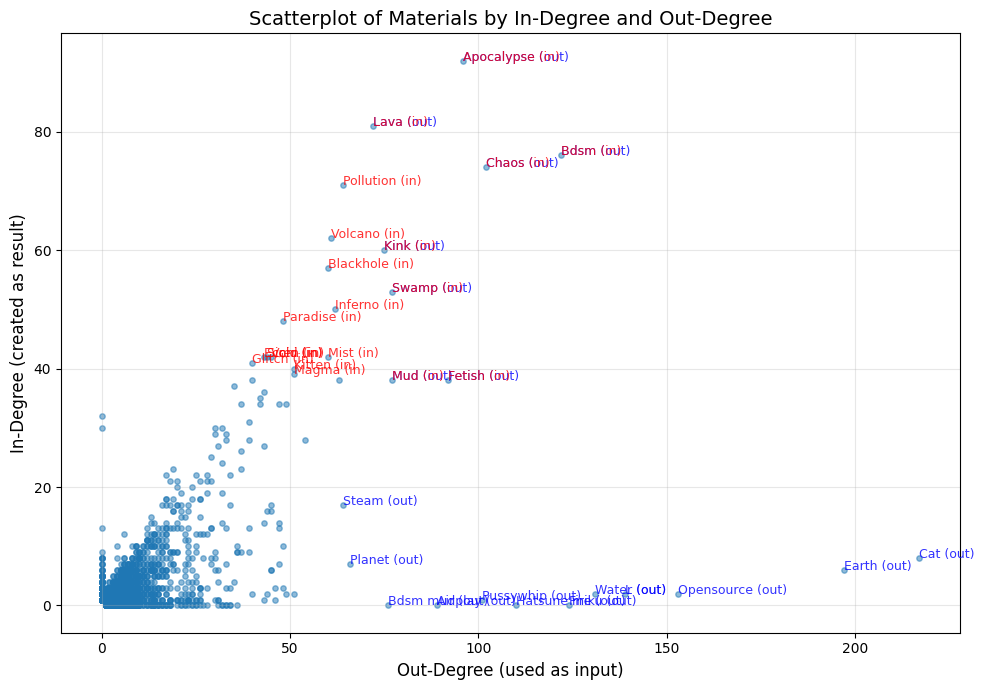

In [26]:
import matplotlib.pyplot as plt

# Extract in-degree and out-degree for all materials
in_degrees = [item['in_degree'] for item in sorted_by_out]
out_degrees = [item['out_degree'] for item in sorted_by_out]
names = [item['name'] for item in sorted_by_out]

plt.figure(figsize=(10, 7))
plt.scatter(out_degrees, in_degrees, alpha=0.5, s=15)

# Label top 20 by out-degree
for i in range(20):
    plt.annotate(f"{names[i]} (out)", (out_degrees[i], in_degrees[i]), fontsize=9, color='blue', alpha=0.8)

# Label top 20 by in-degree
sorted_by_in = sorted(sorted_by_out, key=lambda x: x['in_degree'], reverse=True)
for i in range(20):
    idx = names.index(sorted_by_in[i]['name'])
    plt.annotate(f"{sorted_by_in[i]['name']} (in)", (out_degrees[idx], in_degrees[idx]), fontsize=9, color='red', alpha=0.8)

plt.xlabel('Out-Degree (used as input)', fontsize=12)
plt.ylabel('In-Degree (created as result)', fontsize=12)
plt.title('Scatterplot of Materials by In-Degree and Out-Degree', fontsize=14)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [27]:
import sqlite3
import pandas as pd

# Query: Rank-to-Width Ratio per User
conn = sqlite3.connect('global.db')
query = '''
SELECT
  username,
  COUNT(DISTINCT resultName) AS unique_words,
  MAX(perUserRank) AS max_rank,
  CAST(MAX(perUserRank) AS FLOAT) / NULLIF(COUNT(DISTINCT resultName), 0) AS rank_to_width_ratio
FROM combinations
GROUP BY username
HAVING COUNT(DISTINCT resultName) >= 500
ORDER BY rank_to_width_ratio DESC;
'''
df = pd.read_sql_query(query, conn)
conn.close()
display(df)

,username,unique_words,max_rank,rank_to_width_ratio
0,ace,741,146,0.197031
1,tim,1158,224,0.193437
2,izzy,633,108,0.170616
3,isabel,2539,132,0.051989


In [28]:
import sqlite3
import pandas as pd

conn = sqlite3.connect('global.db')

# Find all combinations where 'maid' was used as an ingredient
maid_query = '''
SELECT 
    firstWord AS ingredient1,
    secondWord AS ingredient2,
    resultName AS result,
    COUNT(*) AS times_used
FROM combinations
WHERE LOWER(firstWord) = 'maid' OR LOWER(secondWord) = 'maid'
GROUP BY firstWord, secondWord, resultName
ORDER BY times_used DESC
'''

maid_combos = pd.read_sql_query(maid_query, conn)
conn.close()

# Count total times 'maid' was used
total_uses = maid_combos['times_used'].sum()

print(f"Total times 'maid' was used as an ingredient: {total_uses}")
print(f"Number of unique combinations involving 'maid': {len(maid_combos)}")
print()
print("| Ingredient 1 | Ingredient 2 | Result | Times Used |")
print("|--------------|--------------|--------|------------|")
for _, row in maid_combos.iterrows():
    print(f"| {row['ingredient1']} | {row['ingredient2']} | {row['result']} | {row['times_used']} |")

Total times 'maid' was used as an ingredient: 24
Number of unique combinations involving 'maid': 24

| Ingredient 1 | Ingredient 2 | Result | Times Used |
|--------------|--------------|--------|------------|
| Anarchy | Maid | Rebel Servant | 1 |
| Aquapunk | Maid | Mermaid | 1 |
| Bdsm mudplay | Maid | Kinkymaid | 1 |
| Bondage anime | Maid | Hentai | 1 |
| Globe | Maid | Geisha | 1 |
| Maid | Air | Flight Attendant | 1 |
| Maid | Army | Meido | 1 |
| Maid | Cat | Nekomaid | 1 |
| Maid | Cleaning | Housekeeping | 1 |
| Maid | Demon | Devil Maid | 1 |
| Maid | Fetish | Cosplay | 1 |
| Maid | Galaxy | Space Servant | 1 |
| Maid | Gumbo | Cajun Servant | 1 |
| Maid | Hurricane | Tornado Cleaner | 1 |
| Maid | Moe | Moemaid | 1 |
| Maid | Monika | Doki Doki | 1 |
| Maid | Mothra | Kaiju Maid | 1 |
| Maid | Planet | Alien Servant | 1 |
| Rebel | Maid | Punk Maid | 1 |
| Succubus | Maid | Succumaid | 1 |
| Vacuum warning | Maid | Cleaning | 1 |
| Vampire | Maid | Maiden Of The Night | 1 |


In [29]:
import sqlite3
import pandas as pd

conn = sqlite3.connect('global.db')

def analyze_word(word, conn):
    """Analyze usage of a word as ingredient and count results starting with that word"""
    query = f'''
    SELECT 
        firstWord AS ingredient1,
        secondWord AS ingredient2,
        resultName AS result,
        COUNT(*) AS times_used
    FROM combinations
    WHERE LOWER(firstWord) = LOWER('{word}') OR LOWER(secondWord) = LOWER('{word}')
    GROUP BY firstWord, secondWord, resultName
    ORDER BY times_used DESC
    '''
    df = pd.read_sql_query(query, conn)
    
    total_uses = df['times_used'].sum()
    starts_with = df[df['result'].str.lower().str.startswith(word.lower())]['times_used'].sum()
    
    print(f"=== Analysis for '{word}' ===")
    print(f"Total times '{word}' was used as an ingredient: {total_uses}")
    print(f"Number of unique combinations involving '{word}': {len(df)}")
    print(f"Results starting with '{word}': {starts_with} ({100*starts_with/total_uses:.1f}% of uses)")
    print()
    print(f"| Ingredient 1 | Ingredient 2 | Result | Times Used | Starts with '{word}'? |")
    print("|--------------|--------------|--------|------------|" + "-" * (len(word) + 17) + "|")
    for _, row in df.iterrows():
        starts = "✓" if row['result'].lower().startswith(word.lower()) else ""
        print(f"| {row['ingredient1']} | {row['ingredient2']} | {row['result']} | {row['times_used']} | {starts} |")
    print()
    return df

# Analyze 'L'
print()
l_combos = analyze_word('L', conn)

# Analyze 'BL'
print()
bl_combos = analyze_word('BL', conn)

conn.close()


=== Analysis for 'L' ===
Total times 'L' was used as an ingredient: 152
Number of unique combinations involving 'L': 138
Results starting with 'L': 75 (49.3% of uses)

| Ingredient 1 | Ingredient 2 | Result | Times Used | Starts with 'L'? |
|--------------|--------------|--------|------------|------------------|
| L | L | Llama | 3 | ✓ |
| All | L | Wall | 2 |  |
| Germany | L | Lederhosen | 2 | ✓ |
| Guided missile | L | Laser | 2 | ✓ |
| Hololens | L | Hologram | 2 |  |
| L | Error | Glitch | 2 |  |
| Laboratory | L | Lab | 2 | ✓ |
| Leather | L | Luxury | 2 | ✓ |
| Legend | L | Legend | 2 | ✓ |
| Llama | L | Learning | 2 | ✓ |
| Mirror | L | Reflection | 2 |  |
| Order | L | Law | 2 | ✓ |
| Tokyo tower | L | Licht | 2 | ✓ |
| Antihero | L | Loki | 1 | ✓ |
| Army | L | Legion | 1 | ✓ |
| Battleflag | L | Logo | 1 | ✓ |
| Blast | L | Laser | 1 | ✓ |
| Burro | L | Donkey | 1 |  |
| Casino | L | Lasvegas | 1 | ✓ |
| Chernobyl | L | Radiation | 1 |  |
| Crime | L | Law | 1 | ✓ |
| Destr

Connecting to DB and loading combinations ...
  12,045 raw combination rows
  4,848 materials with stored embeddings
  1,685 words missing embeddings – generating on-the-fly ...
Embeddings ready.
N-gram space: 4859 features
ASCII space ready.
Fitting PCA projectors for concat-project operation ...
Projectors ready. Total predictors: 24
Accumulating similarities and per-space baselines ...
  Done. Skipped 0 combos with missing embeddings.

Per-space cosine baselines:
  llm    mu=0.3083  sigma=0.2131  n=96,360
  ngram  mu=0.0388  sigma=0.1037  n=96,360
  ascii  mu=0.6703  sigma=0.3352  n=96,360

Words with predictability scores: 2,823
Predictability z-range: -0.229 to 7.356
Mean predictability z:  0.966

Most common best predictors (space-normalized):
  llm / average                    1193 words
  ascii / average                  477 words
  ngram / dominant-A               185 words
  ascii / min-pool                 174 words
  ascii / max-pool                 162 words
  ngram / domi

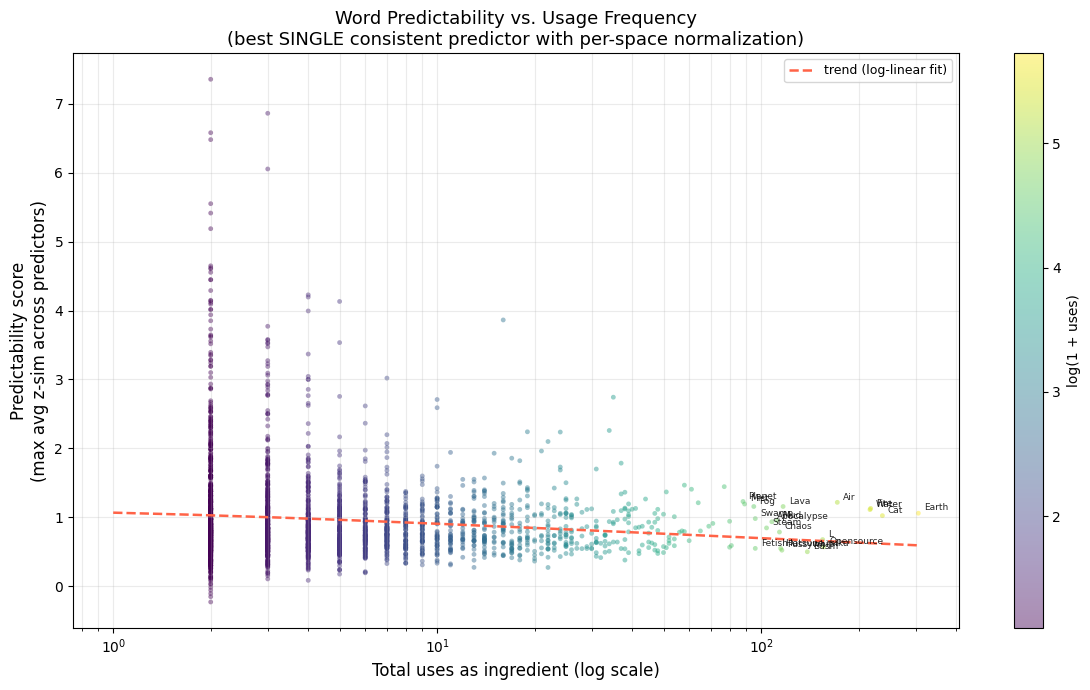


Top-20 most PREDICTABLE words (>=10 uses, space-normalized):
  Word                        zScore   rawAvg   Uses  Best predictor
  Evolution                    3.864    0.439     16  ngram / average
  Seduction                    2.743    0.323     35  ngram / dominant-A
  Candle                       2.709    0.320     10  ngram / dominant-A
  Emulation                    2.590    0.307     10  ngram / dominant-A
  Hello kitty                  2.260    0.273     34  ngram / dominant-B
  Omniverse                    2.241    0.271     19  ngram / dominant-B
  Bdsm kitten                  2.237    0.271     24  ngram / average
  Terror                       2.100    0.257     22  ngram / dominant-A
  Multiverse                   1.962    0.242     21  ngram / average
  Epidemic                     1.942    0.240     11  ngram / average
  United nations               1.930    0.239     15  ngram / dominant-B
  Fyora                        1.858    0.231     17  ngram / dominant-A
  Tem

In [32]:
"""
Word Predictability Analysis (Space-Normalized)
================================================
Goal: measure whether a SINGLE predictor function is consistently good for a word,
without letting one vector space dominate due to its raw cosine scale.

Vector spaces
-------------
1. LLM embedding space  — sentence-transformers/all-MiniLM-L6-v2 (384-d), stored in DB
2. Character n-gram space — each word → bag-of-character-bigrams TF-IDF vector
3. Ordinal-ASCII space  — each word → vector of ASCII codes of its characters (zero-padded)

Geometric operations (predictors), given vectors a, b for the two ingredients:
---------------------------------------------------------------------------
P1  average:           (a + b) / 2
P2  sum:               a + b
P3  max-pool:          element-wise max(a, b)
P4  min-pool:          element-wise min(a, b)
P5  dominant-A:        a
P6  dominant-B:        b
P7  abs-diff:          |a - b|
P8  concat-project:    PCA projection of [a; b]

Normalization
-------------
For each space separately, compute global mean/std of all predictor cosine scores.
Convert each cosine to z-score: z = (sim - mu_space) / sigma_space.

Predictability score for word W
---------------------------------
For every predictor (space × operation):
  average normalized z-similarity across ALL combinations involving W.
Take the MAX over predictors → predictability score of W.

This makes scores reflect predictor consistency, not raw space scale.
"""

import sqlite3
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict, Counter
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA
from sentence_transformers import SentenceTransformer

# ──────────────────────────────────────────────────────────────
# 1. Load data
# ──────────────────────────────────────────────────────────────
print("Connecting to DB and loading combinations ...")
conn = sqlite3.connect('global.db')
cursor = conn.cursor()

cursor.execute("""
    SELECT firstWord, secondWord, resultName
    FROM combinations
    WHERE perUserRank IS NOT NULL
""")
raw_combos = cursor.fetchall()   # [(a, b, result), ...]

cursor.execute("SELECT name, embedding FROM materials WHERE embedding IS NOT NULL")
emb_rows = cursor.fetchall()
conn.close()

print(f"  {len(raw_combos):,} raw combination rows")
print(f"  {len(emb_rows):,} materials with stored embeddings")

# ──────────────────────────────────────────────────────────────
# 2. Build embedding cache: word → np.ndarray (384)
# ──────────────────────────────────────────────────────────────
def blob_to_vec(blob):
    return np.frombuffer(blob, dtype=np.float32).copy()

db_emb: dict[str, np.ndarray] = {}
for name, blob in emb_rows:
    db_emb[name] = blob_to_vec(blob)

all_words = set()
for a, b, r in raw_combos:
    all_words.update([a, b, r])

missing_words = all_words - set(db_emb.keys())
print(f"  {len(missing_words):,} words missing embeddings – generating on-the-fly ...")

if missing_words:
    st_model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')
    missing_list = sorted(missing_words)
    vecs = st_model.encode(missing_list, batch_size=256, show_progress_bar=False, convert_to_numpy=True)
    for w, v in zip(missing_list, vecs):
        db_emb[w] = v.astype(np.float32)

print("Embeddings ready.")

# ──────────────────────────────────────────────────────────────
# 3. Character n-gram space (TF-IDF bigrams/trigrams)
# ──────────────────────────────────────────────────────────────
word_list = sorted(all_words)
vectorizer = TfidfVectorizer(analyzer='char_wb', ngram_range=(2, 3), sublinear_tf=True)
ngram_matrix = vectorizer.fit_transform(word_list)

ngram_emb: dict[str, np.ndarray] = {}
for i, w in enumerate(word_list):
    ngram_emb[w] = np.asarray(ngram_matrix[i].todense(), dtype=np.float32).ravel()

print(f"N-gram space: {ngram_matrix.shape[1]} features")

# ──────────────────────────────────────────────────────────────
# 4. Ordinal-ASCII space
# ──────────────────────────────────────────────────────────────
MAX_LEN = 30

def word_to_ascii(w: str) -> np.ndarray:
    codes = [ord(c) / 128.0 for c in w.lower()[:MAX_LEN]]
    codes += [0.0] * (MAX_LEN - len(codes))
    return np.array(codes, dtype=np.float32)

ascii_emb: dict[str, np.ndarray] = {w: word_to_ascii(w) for w in all_words}
print("ASCII space ready.")

# ──────────────────────────────────────────────────────────────
# 5. Geometric operations + PCA projectors
# ──────────────────────────────────────────────────────────────
def cosine_sim(u: np.ndarray, v: np.ndarray) -> float:
    nu, nv = np.linalg.norm(u), np.linalg.norm(v)
    if nu < 1e-9 or nv < 1e-9:
        return 0.0
    return float(np.dot(u, v) / (nu * nv))

OPS = {
    'average':    lambda a, b: (a + b) / 2,
    'sum':        lambda a, b: a + b,
    'max-pool':   lambda a, b: np.maximum(a, b),
    'min-pool':   lambda a, b: np.minimum(a, b),
    'dominant-A': lambda a, b: a,
    'dominant-B': lambda a, b: b,
    'abs-diff':   lambda a, b: np.abs(a - b),
}

print("Fitting PCA projectors for concat-project operation ...")

def fit_pca_projector(emb_dict, target_dim=None):
    keys = set(emb_dict.keys())
    valid = [(a, b) for a, b, r in raw_combos if a in keys and b in keys]
    sample = valid[:5000]
    X = np.vstack([np.concatenate([emb_dict[a], emb_dict[b]]) for a, b in sample])
    dim = len(emb_dict[next(iter(emb_dict))])
    if target_dim is None:
        target_dim = dim
    n_components = min(target_dim, X.shape[0], X.shape[1])
    pca = PCA(n_components=n_components)
    pca.fit(X)
    return pca, dim

pca_llm, dim_llm = fit_pca_projector(db_emb)
pca_ngram, dim_ngram = fit_pca_projector(ngram_emb)
pca_ascii, dim_ascii = fit_pca_projector(ascii_emb)

def concat_project(a, b, pca, target_dim):
    proj = pca.transform(np.concatenate([a, b]).reshape(1, -1))[0]
    if len(proj) < target_dim:
        proj = np.concatenate([proj, np.zeros(target_dim - len(proj), dtype=np.float32)])
    return proj[:target_dim].astype(np.float32)

spaces = {
    'llm':   (db_emb, pca_llm, dim_llm),
    'ngram': (ngram_emb, pca_ngram, dim_ngram),
    'ascii': (ascii_emb, pca_ascii, dim_ascii),
}

predictor_keys = []
for sp in spaces:
    for op in OPS:
        predictor_keys.append((sp, op))
    predictor_keys.append((sp, 'concat-project'))
print(f"Projectors ready. Total predictors: {len(predictor_keys)}")

# ──────────────────────────────────────────────────────────────
# 6. Accumulate per-word/per-predictor sims + per-space baselines
# ──────────────────────────────────────────────────────────────
print("Accumulating similarities and per-space baselines ...")

# word -> predictor_key -> [raw cosine sims]
word_pred_sims = defaultdict(lambda: defaultdict(list))
word_use_count = defaultdict(int)

# space -> all raw cosine sims (all predictors, all combos)
space_all_sims = defaultdict(list)

skipped = 0
for idx, (a, b, r) in enumerate(raw_combos):
    word_use_count[a] += 1
    word_use_count[b] += 1

    if a not in db_emb or b not in db_emb or r not in db_emb:
        skipped += 1
        continue

    for sp_name, (emb, pca, dim) in spaces.items():
        va, vb, vr = emb.get(a), emb.get(b), emb.get(r)
        if va is None or vb is None or vr is None:
            continue

        for op_name, op_fn in OPS.items():
            sim = cosine_sim(op_fn(va, vb), vr)
            key = (sp_name, op_name)
            word_pred_sims[a][key].append(sim)
            word_pred_sims[b][key].append(sim)
            space_all_sims[sp_name].append(sim)

        sim_cp = cosine_sim(concat_project(va, vb, pca, dim), vr)
        key_cp = (sp_name, 'concat-project')
        word_pred_sims[a][key_cp].append(sim_cp)
        word_pred_sims[b][key_cp].append(sim_cp)
        space_all_sims[sp_name].append(sim_cp)

    if (idx + 1) % 50000 == 0:
        print(f"  processed {idx + 1:,} / {len(raw_combos):,} combos ...")

print(f"  Done. Skipped {skipped:,} combos with missing embeddings.")

# Space normalization stats
space_stats = {}
print("\nPer-space cosine baselines:")
for sp_name, vals in space_all_sims.items():
    arr = np.array(vals, dtype=np.float32)
    mu = float(arr.mean())
    sigma = float(arr.std())
    if sigma < 1e-6:
        sigma = 1.0
    space_stats[sp_name] = (mu, sigma)
    print(f"  {sp_name:<6} mu={mu:.4f}  sigma={sigma:.4f}  n={len(arr):,}")

# ──────────────────────────────────────────────────────────────
# 7. Predictability = max over predictors of avg normalized score
# ──────────────────────────────────────────────────────────────
predictability = {}
best_predictor = {}
best_predictor_raw_avg = {}

for word, pred_dict in word_pred_sims.items():
    if word_use_count[word] < 2:
        continue

    best_norm_score = -1e18
    best_key = None
    best_raw_avg = None

    for key, sims in pred_dict.items():
        if not sims:
            continue
        sp_name = key[0]
        mu, sigma = space_stats[sp_name]
        sims_arr = np.array(sims, dtype=np.float32)

        # Normalize by the global scale of this space
        norm_avg = float(((sims_arr - mu) / sigma).mean())
        raw_avg = float(sims_arr.mean())

        if norm_avg > best_norm_score:
            best_norm_score = norm_avg
            best_key = key
            best_raw_avg = raw_avg

    if best_key is not None:
        predictability[word] = best_norm_score
        best_predictor[word] = best_key
        best_predictor_raw_avg[word] = best_raw_avg

uses = [word_use_count[w] for w in predictability]
pred_vals = [predictability[w] for w in predictability]
labels = list(predictability.keys())

print(f"\nWords with predictability scores: {len(predictability):,}")
print(f"Predictability z-range: {min(pred_vals):.3f} to {max(pred_vals):.3f}")
print(f"Mean predictability z:  {np.mean(pred_vals):.3f}")

pred_counts = Counter(best_predictor.values())
print("\nMost common best predictors (space-normalized):")
for pk, cnt in pred_counts.most_common(10):
    print(f"  {pk[0] + ' / ' + pk[1]:<32} {cnt} words")

# ──────────────────────────────────────────────────────────────
# 8. Plot
# ──────────────────────────────────────────────────────────────
uses_arr = np.array(uses, dtype=float)
pred_arr = np.array(pred_vals, dtype=float)

fig, ax = plt.subplots(figsize=(12, 7))

log_uses = np.log1p(uses_arr)
scatter = ax.scatter(
    uses_arr, pred_arr,
    c=log_uses, cmap='viridis',
    alpha=0.45, s=12, linewidths=0,
)
cbar = fig.colorbar(scatter, ax=ax)
cbar.set_label('log(1 + uses)', fontsize=10)

valid = uses_arr > 0
z = np.polyfit(np.log1p(uses_arr[valid]), pred_arr[valid], 1)
p = np.poly1d(z)
xs = np.linspace(1, uses_arr.max(), 400)
ax.plot(xs, p(np.log1p(xs)), color='tomato', linewidth=1.8, linestyle='--', label='trend (log-linear fit)')

top_idx = np.argsort(uses_arr)[-20:]
for i in top_idx:
    ax.annotate(
        labels[i],
        (uses_arr[i], pred_arr[i]),
        fontsize=6.5, alpha=0.85,
        xytext=(4, 2), textcoords='offset points',
    )

ax.set_xscale('log')
ax.set_xlabel('Total uses as ingredient (log scale)', fontsize=12)
ax.set_ylabel('Predictability score\n(max avg z-sim across predictors)', fontsize=12)
ax.set_title(
    'Word Predictability vs. Usage Frequency\n'
    '(best SINGLE consistent predictor with per-space normalization)',
    fontsize=13
)
ax.legend(fontsize=9)
ax.grid(True, which='both', alpha=0.25)
plt.tight_layout()
plt.show()

# Top / bottom words (>=10 uses)
freq_filtered = [
    (w, predictability[w], best_predictor_raw_avg[w], word_use_count[w], best_predictor[w])
    for w in predictability
    if word_use_count[w] >= 10
]
freq_filtered.sort(key=lambda x: -x[1])

print("\nTop-20 most PREDICTABLE words (>=10 uses, space-normalized):")
print(f"  {'Word':<25} {'zScore':>8} {'rawAvg':>8} {'Uses':>6}  Best predictor")
for w, zscore, rawavg, u, bp in freq_filtered[:20]:
    print(f"  {w:<25} {zscore:>8.3f} {rawavg:>8.3f} {u:>6}  {bp[0] + ' / ' + bp[1]}")

print("\nTop-20 LEAST predictable words (>=10 uses, space-normalized):")
for w, zscore, rawavg, u, bp in freq_filtered[-20:]:
    print(f"  {w:<25} {zscore:>8.3f} {rawavg:>8.3f} {u:>6}  {bp[0] + ' / ' + bp[1]}")

In [31]:
import requests
import sqlite3
import pandas as pd
from collections import defaultdict

# Get top 8 users by unique words discovered
conn = sqlite3.connect('global.db')
top_users_query = '''
SELECT username, COUNT(DISTINCT resultName) AS unique_words
FROM combinations
GROUP BY username
ORDER BY unique_words DESC
LIMIT 8;
'''
top_users = pd.read_sql_query(top_users_query, conn)['username'].tolist()

results = []

for username in top_users:
    # Get all unique materials discovered by this user
    user_words_query = '''
    SELECT DISTINCT resultName FROM combinations WHERE username = ?
    '''
    user_words = pd.read_sql_query(user_words_query, conn, params=(username,))['resultName'].tolist()
    if not user_words:
        continue
    # Get all combinations for this user
    combos_query = '''
    SELECT firstWord, secondWord, resultName FROM combinations WHERE username = ?
    '''
    combos = pd.read_sql_query(combos_query, conn, params=(username,))
    # Build undirected edges for community detection
    edges = []
    for _, row in combos.iterrows():
        edges.append((row['firstWord'], row['resultName']))
        edges.append((row['secondWord'], row['resultName']))
    # Build adjacency
    adj = defaultdict(set)
    for a, b in edges:
        adj[a].add(b)
        adj[b].add(a)
    # Simple label propagation for communities (fallback if no Louvain)
    # Assign each connected component as a community
    visited = set()
    communities = {}
    comm_id = 0
    for node in user_words:
        if node in visited:
            continue
        stack = [node]
        while stack:
            n = stack.pop()
            if n in visited:
                continue
            visited.add(n)
            communities[n] = comm_id
            for nb in adj[n]:
                if nb not in visited:
                    stack.append(nb)
        comm_id += 1
    # Call backend API for embedding stats
    api_url = 'http://localhost:3000/api/community-embedding-stats'
    resp = requests.post(api_url, json={"communities": communities})
    if resp.status_code != 200:
        print(f"API error for user {username}")
        continue
    stats = resp.json().get('stats', {})
    # Compute average centrality and spread (avgDistToCentroid)
    avg_centrality = sum(s.get('avgDistToCentroid', 0) for s in stats.values()) / max(len(stats), 1)
    avg_spread = sum(s.get('stdDistToCentroid', 0) for s in stats.values()) / max(len(stats), 1)
    results.append({
        'username': username,
        'avg_community_centrality': avg_centrality,
        'avg_community_spread': avg_spread,
        'num_communities': len(stats)
    })

conn.close()
df = pd.DataFrame(results)
display(df)
df

ConnectionError: HTTPConnectionPool(host='localhost', port=3000): Max retries exceeded with url: /api/community-embedding-stats (Caused by NewConnectionError("HTTPConnection(host='localhost', port=3000): Failed to establish a new connection: [Errno 61] Connection refused"))

In [ ]:
import numpy as np

def louvain_communities(nodes, edges, gamma=0.5, max_passes=50, min_gain=-1e-6):
    """
    Louvain-style modularity community detection (unweighted, undirected).
    nodes: list of node ids
    edges: list of (a, b) tuples
    Returns: dict of node_id -> community_id
    """
    # Build adjacency
    adjacency = {n: {} for n in nodes}
    for a, b in edges:
        if a == b: continue
        adjacency[a][b] = adjacency[a].get(b, 0) + 1
        adjacency[b][a] = adjacency[b].get(a, 0) + 1
    degrees = {n: sum(adjacency[n].values()) for n in nodes}
    m2 = sum(degrees.values())
    if m2 == 0:
        return {n: i for i, n in enumerate(nodes)}
    # Initial communities
    community = {n: n for n in nodes}
    community_weight = {n: degrees[n] for n in nodes}
    moved = True
    pass_num = 0
    while moved and pass_num < max_passes:
        moved = False
        pass_num += 1
        for n in nodes:
            current_comm = community[n]
            k_i = degrees[n]
            neighbors = adjacency[n]
            # Remove from current community
            community_weight[current_comm] -= k_i
            # Compute k_i_in for neighbor communities
            comm_conn = {}
            for nb, w in neighbors.items():
                comm_nb = community[nb]
                comm_conn[comm_nb] = comm_conn.get(comm_nb, 0) + w
            best_comm = current_comm
            best_gain = 0
            m = m2 / 2
            for comm, k_i_in in comm_conn.items():
                tot = community_weight[comm]
                gain = k_i_in - gamma * (k_i * tot) / m2
                if gain > best_gain:
                    best_gain = gain
                    best_comm = comm
            # Restore weight
            community_weight[current_comm] += k_i
            min_gain = min_gain
            if best_comm != current_comm and best_gain > min_gain:
                community[n] = best_comm
                community_weight[best_comm] += k_i
                community_weight[current_comm] -= k_i
                moved = True
    # Relabel communities to consecutive ints
    comm_map = {c: i for i, c in enumerate(sorted(set(community.values())))}
    return {n: comm_map[community[n]] for n in nodes}


In [ ]:
# Louvain community stats for top 8 users (exactly as in Graph.vue)
import requests
import sqlite3
import pandas as pd
from collections import defaultdict

# Ensure louvain_communities is defined in this cell
def louvain_communities(nodes, edges, gamma=0.5, max_passes=50, min_gain=-1e-6):
    """
    Louvain-style modularity community detection (unweighted, undirected).
    nodes: list of node ids
    edges: list of (a, b) tuples
    Returns: dict of node_id -> community_id
    """
    # Build adjacency
    adjacency = {n: {} for n in nodes}
    for a, b in edges:
        if a == b: continue
        if a not in adjacency or b not in adjacency:
            continue  # skip edges with nodes not in the node list
        adjacency[a][b] = adjacency[a].get(b, 0) + 1
        adjacency[b][a] = adjacency[b].get(a, 0) + 1
    degrees = {n: sum(adjacency[n].values()) for n in nodes}
    m2 = sum(degrees.values())
    if m2 == 0:
        return {n: i for i, n in enumerate(nodes)}
    # Initial communities
    community = {n: n for n in nodes}
    community_weight = {n: degrees[n] for n in nodes}
    moved = True
    pass_num = 0
    while moved and pass_num < max_passes:
        moved = False
        pass_num += 1
        for n in nodes:
            current_comm = community[n]
            k_i = degrees[n]
            neighbors = adjacency[n]
            # Remove from current community
            community_weight[current_comm] -= k_i
            # Compute k_i_in for neighbor communities
            comm_conn = {}
            for nb, w in neighbors.items():
                comm_nb = community[nb]
                comm_conn[comm_nb] = comm_conn.get(comm_nb, 0) + w
            best_comm = current_comm
            best_gain = 0
            m = m2 / 2
            for comm, k_i_in in comm_conn.items():
                tot = community_weight[comm]
                gain = k_i_in - gamma * (k_i * tot) / m2
                if gain > best_gain:
                    best_gain = gain
                    best_comm = comm
            # Restore weight
            community_weight[current_comm] += k_i
            min_gain = min_gain
            if best_comm != current_comm and best_gain > min_gain:
                community[n] = best_comm
                community_weight[best_comm] += k_i
                community_weight[current_comm] -= k_i
                moved = True
    # Relabel communities to consecutive ints
    comm_map = {c: i for i, c in enumerate(sorted(set(community.values())))}
    return {n: comm_map[community[n]] for n in nodes}

conn = sqlite3.connect('global.db')
top_users_query = '''
SELECT username, COUNT(DISTINCT resultName) AS unique_words
FROM combinations
GROUP BY username
ORDER BY unique_words DESC
LIMIT 8;
'''
top_users = pd.read_sql_query(top_users_query, conn)['username'].tolist()

results = []

for username in top_users:
    # Get all unique materials discovered by this user
    user_words_query = '''
    SELECT DISTINCT resultName FROM combinations WHERE username = ?
    '''
    user_words = pd.read_sql_query(user_words_query, conn, params=(username,))['resultName'].tolist()
    if not user_words:
        continue
    # Get all combinations for this user
    combos_query = '''
    SELECT firstWord, secondWord, resultName FROM combinations WHERE username = ?
    '''
    combos = pd.read_sql_query(combos_query, conn, params=(username,))
    # Build undirected edges for Louvain, but only include edges where all nodes are in user_words
    edges = []
    for _, row in combos.iterrows():
        if row['firstWord'] in user_words and row['resultName'] in user_words:
            edges.append((row['firstWord'], row['resultName']))
        if row['secondWord'] in user_words and row['resultName'] in user_words:
            edges.append((row['secondWord'], row['resultName']))
    # Run Louvain
    comm_assignments = louvain_communities(user_words, edges, gamma=0.5, max_passes=50, min_gain=-1e-6)
    # Convert to backend format: {community_id: [node, ...]}
    comms = defaultdict(list)
    for node, comm_id in comm_assignments.items():
        comms[comm_id].append(node)
    comms = dict(comms)
    # Call backend API for embedding stats
    api_url = 'http://localhost:3000/api/community-embedding-stats'
    resp = requests.post(api_url, json={"communities": comms})
    if resp.status_code != 200:
        print(f"API error for user {username}")
        continue
    stats = resp.json().get('stats', {})
    # Compute average centrality and spread (avgDistToCentroid)
    avg_centrality = sum(s.get('avgDistToCentroid', 0) for s in stats.values()) / max(len(stats), 1)
    avg_spread = sum(s.get('stdDistToCentroid', 0) for s in stats.values()) / max(len(stats), 1)
    results.append({
        'username': username,
        'avg_community_centrality': avg_centrality,
        'avg_community_spread': avg_spread,
        'num_communities': len(stats)
    })

conn.close()
df = pd.DataFrame(results)
display(df)
df

,username,avg_community_centrality,avg_community_spread,num_communities
0,isabel,0.0,0.0,730
1,tim,0.0,0.0,315
2,ace,0.0,0.0,213
3,izzy,0.0,0.0,175
4,diana,0.0,0.0,81
5,Connor,0.0,0.0,88
6,vann,0.0,0.0,53
7,example,0.0,0.0,53


,username,avg_community_centrality,avg_community_spread,num_communities
0,isabel,0.0,0.0,730
1,tim,0.0,0.0,315
2,ace,0.0,0.0,213
3,izzy,0.0,0.0,175
4,diana,0.0,0.0,81
5,Connor,0.0,0.0,88
6,vann,0.0,0.0,53
7,example,0.0,0.0,53


## Throw Score Analysis

The "throw score" measures how well the LLM adheres to semantic interpolation when combining words.

- **Expected output**: The normalized average of the two component embeddings
- **Throw score**: Cosine similarity between the expected output and the actual result embedding

A throw score of 1.0 means the result is exactly at the semantic midpoint of the two inputs.
Lower scores indicate the LLM "threw" the result further from the expected interpolation.

In [ ]:
import numpy as np
import struct

def deserialize_float32(blob):
    """Deserialize a BLOB to a numpy float32 array (384 dimensions for MiniLM)."""
    if blob is None:
        return None
    return np.frombuffer(blob, dtype=np.float32)

def load_embeddings(db_path='global.db', normalize_vectors=True):
    """Load all material embeddings from the database.
    
    Args:
        db_path: Path to the SQLite database
        normalize_vectors: If True, normalize all embeddings to unit length
    """
    conn = sqlite3.connect(db_path)
    cursor = conn.cursor()
    cursor.execute("SELECT name, embedding FROM materials WHERE embedding IS NOT NULL")
    embeddings = {}
    for name, blob in cursor.fetchall():
        emb = deserialize_float32(blob)
        if emb is not None and len(emb) > 0:
            if normalize_vectors:
                norm = np.linalg.norm(emb)
                if norm > 1e-10:
                    emb = emb / norm
                else:
                    continue  # Skip zero-norm embeddings
            embeddings[name] = emb
    conn.close()
    return embeddings

def cosine_similarity(a, b):
    """Compute cosine similarity between two vectors."""
    norm_a = np.linalg.norm(a)
    norm_b = np.linalg.norm(b)
    if norm_a == 0 or norm_b == 0:
        return 0.0
    return np.dot(a, b) / (norm_a * norm_b)

def normalize(v):
    """Normalize a vector to unit length."""
    norm = np.linalg.norm(v)
    if norm < 1e-10:
        return None
    return v / norm

# ============================================================
# COMBINATION FUNCTIONS
# Each takes two unit vectors v1, v2 and returns a unit vector
# ============================================================

def midpoint_average(v1, v2):
    """
    Midpoint / Average: Point on the unit sphere halfway between v1 and v2 along the chord.
    Meaning: "Blend" or "interpolation" — equal contribution from both concepts.
    """
    return normalize((v1 + v2) / 2.0)

def slerp_midpoint(v1, v2):
    """
    Spherical Linear Interpolation (SLERP): Midpoint along the geodesic (great circle arc).
    Meaning: Smooth interpolation that respects the curved geometry of the sphere.
    """
    dot = np.clip(np.dot(v1, v2), -1.0, 1.0)
    theta = np.arccos(dot)
    if theta < 1e-10:
        return v1  # Vectors are nearly identical
    if np.abs(theta - np.pi) < 1e-10:
        return normalize(v1)  # Vectors are opposite, midpoint is undefined
    # SLERP formula at t=0.5
    sin_theta = np.sin(theta)
    return (np.sin(0.5 * theta) / sin_theta) * v1 + (np.sin(0.5 * theta) / sin_theta) * v2

def hadamard_product(v1, v2):
    """
    Element-wise Product (Hadamard): Emphasizes dimensions where both vectors are strong.
    Meaning: "Intersection" — what both concepts share, dimension-wise.
    """
    product = v1 * v2
    return normalize(product)

def rejection_v1_from_v2(v1, v2):
    """
    Rejection: Component of v1 perpendicular to v2.
    Meaning: "What's in v1 that's NOT in v2" — the novel/unique part.
    """
    # v1 - proj_{v2}(v1)
    projection = np.dot(v1, v2) * v2
    rejection = v1 - projection
    return normalize(rejection)

def reflection(v1, v2):
    """
    Reflection: Reflect v1 across the hyperplane whose normal is v2.
    Meaning: v2 "inverts" or "negates" aspects of v1 that align with it.
    """
    # H(v2) * v1 = v1 - 2 * (v2 · v1) * v2
    reflected = v1 - 2 * np.dot(v1, v2) * v2
    return normalize(reflected)

def element_max(v1, v2):
    """
    Element-wise Maximum: Takes the most extreme value in each dimension.
    Meaning: "Union" of features — keep the strongest signal from either.
    """
    return normalize(np.maximum(v1, v2))

def element_min(v1, v2):
    """
    Element-wise Minimum: Takes the least extreme value in each dimension.
    Meaning: "Intersection" — only keep what both agree on.
    """
    return normalize(np.minimum(v1, v2))

def rotation_composition(v1, v2):
    """
    Rotation Composition: Treat each vector as a rotation from e1, compose them.
    R2(R1(e1)) where R1 takes e1->v1 and R2 takes e1->v2.
    Meaning: Sequential transformation — v2 modifies the direction established by v1.
    """
    dim = len(v1)
    e1 = np.zeros(dim)
    e1[0] = 1.0
    
    # Apply R2 (rotation from e1 to v2) to v1
    # Decompose v1 into components in the e1-v2 plane and orthogonal to it
    
    v1_e1 = np.dot(v1, e1) * e1
    v2_perp_e1 = v2 - np.dot(v2, e1) * e1
    norm_v2_perp = np.linalg.norm(v2_perp_e1)
    
    if norm_v2_perp < 1e-10:
        return v1  # v2 is parallel to e1, rotation is trivial
    
    v2_perp_e1_normalized = v2_perp_e1 / norm_v2_perp
    v1_v2perp = np.dot(v1, v2_perp_e1_normalized) * v2_perp_e1_normalized
    v1_orth = v1 - v1_e1 - v1_v2perp
    
    cos_theta = np.dot(e1, v2)
    sin_theta = norm_v2_perp
    
    a = np.dot(v1, e1)
    b = np.dot(v1, v2_perp_e1_normalized)
    
    new_a = cos_theta * a - sin_theta * b
    new_b = sin_theta * a + cos_theta * b
    
    result = new_a * e1 + new_b * v2_perp_e1_normalized + v1_orth
    return normalize(result)

def weighted_by_angle(v1, v2):
    """
    Weighted by Angle: Weight contribution by how different the vectors are.
    Similar inputs favor v1; dissimilar inputs contribute more equally.
    """
    theta = np.arccos(np.clip(np.dot(v1, v2), -1.0, 1.0))
    weight = theta / np.pi  # 0 when parallel, 1 when opposite
    return normalize(weight * v1 + (1 - weight) * v2)

def geometric_mean(v1, v2):
    """
    Geometric Mean: sqrt(|v1 * v2|) * sign(v1 * v2) per dimension.
    A multiplicative combination that's less sensitive to outliers.
    """
    signs = np.sign(v1 * v2)
    magnitudes = np.sqrt(np.abs(v1 * v2))
    return normalize(signs * magnitudes)

# ============================================================
# THROW SCORE COMPUTATION
# ============================================================

def compute_throw_scores(combinations, embeddings, expected_func, func_name=""):
    """
    Compute throw scores for all unique combinations using a given expected result function.
    
    Args:
        combinations: List of combination dicts with 'from1', 'from2', 'to' keys
        embeddings: Dict of material name -> embedding vector
        expected_func: Function(v1, v2) -> expected unit vector
        func_name: Name of the function for logging
    
    Returns:
        List of dicts with 'from1', 'from2', 'result', 'throw_score'
    """
    scores = []
    seen = set()
    skipped = 0
    
    for combo in combinations:
        from1, from2, result = combo['from1'], combo['from2'], combo['to']
        
        # Create canonical key to avoid duplicates
        key = tuple(sorted([from1, from2])) + (result,)
        if key in seen:
            continue
        seen.add(key)
        
        # Skip if any word is missing embeddings
        if from1 not in embeddings or from2 not in embeddings or result not in embeddings:
            continue
        
        emb1 = embeddings[from1]
        emb2 = embeddings[from2]
        actual = embeddings[result]
        
        # Compute expected result using the provided function
        expected = expected_func(emb1, emb2)
        
        if expected is None:
            skipped += 1
            continue
        
        # Throw score = cosine similarity between expected and actual
        throw_score = cosine_similarity(expected, actual)
        
        scores.append({
            'from1': from1,
            'from2': from2,
            'result': result,
            'throw_score': throw_score
        })
    
    if skipped > 0:
        print(f"  [{func_name}] Skipped {skipped} combinations due to normalization issues")
    
    return scores

# Load embeddings (normalized to unit vectors)
print("Loading embeddings from database (normalizing to unit vectors)...")
embeddings = load_embeddings(normalize_vectors=True)
print(f"Loaded normalized embeddings for {len(embeddings)} materials")

Loading embeddings from database (normalizing to unit vectors)...
Loaded normalized embeddings for 4846 materials


In [ ]:
# Define all combination methods to test
combination_methods = {
    'Midpoint Average': midpoint_average,
    'SLERP Midpoint': slerp_midpoint,
    'Hadamard Product': hadamard_product,
    'Rejection (v1 ⊥ v2)': rejection_v1_from_v2,
    'Reflection': reflection,
    'Element-wise Max': element_max,
    'Element-wise Min': element_min,
    'Rotation Composition': rotation_composition,
    'Weighted by Angle': weighted_by_angle,
    'Geometric Mean': geometric_mean,
}

# Compute throw scores for each method
all_results = {}
print("Computing throw scores for each combination method...")
print("=" * 60)

for name, func in combination_methods.items():
    print(f"\nProcessing: {name}")
    scores = compute_throw_scores(combinations, embeddings, func, name)
    scores_array = np.array([s['throw_score'] for s in scores])
    
    all_results[name] = {
        'scores': scores,
        'scores_array': scores_array,
        'mean': np.mean(scores_array),
        'std': np.std(scores_array),
        'median': np.median(scores_array),
        'min': np.min(scores_array),
        'max': np.max(scores_array),
    }
    
    print(f"  Mean: {all_results[name]['mean']:.4f}, Std: {all_results[name]['std']:.4f}, Median: {all_results[name]['median']:.4f}")

print("\n" + "=" * 60)
print("Done!")

Computing throw scores for each combination method...

Processing: Midpoint Average
  Mean: 0.4740, Std: 0.1303, Median: 0.4739

Processing: SLERP Midpoint
  Mean: 0.4740, Std: 0.1303, Median: 0.4739

Processing: Hadamard Product
  Mean: 0.1301, Std: 0.0677, Median: 0.1312

Processing: Rejection (v1 ⊥ v2)
  [Rejection (v1 ⊥ v2)] Skipped 359 combinations due to normalization issues
  Mean: 0.2633, Std: 0.2052, Median: 0.2572

Processing: Reflection
  Mean: 0.1032, Std: 0.2509, Median: 0.1256

Processing: Element-wise Max
  Mean: 0.3966, Std: 0.1178, Median: 0.3909

Processing: Element-wise Min
  Mean: 0.1301, Std: 0.0677, Median: 0.1312

Processing: Rejection (v1 ⊥ v2)
  [Rejection (v1 ⊥ v2)] Skipped 359 combinations due to normalization issues
  Mean: 0.2633, Std: 0.2052, Median: 0.2572

Processing: Reflection
  Mean: 0.1032, Std: 0.2509, Median: 0.1256

Processing: Element-wise Max
  Mean: 0.3966, Std: 0.1178, Median: 0.3909

Processing: Element-wise Min
  Mean: 0.3830, Std: 0.1209, M

In [ ]:
# Summary statistics table
print("=" * 90)
print("THROW SCORE SUMMARY BY COMBINATION METHOD")
print("=" * 90)
print(f"{'Method':<25} {'Mean':>10} {'Std':>10} {'Median':>10} {'Min':>10} {'Max':>10}")
print("-" * 90)

# Sort by mean throw score (descending)
sorted_methods = sorted(all_results.items(), key=lambda x: x[1]['mean'], reverse=True)

for name, stats in sorted_methods:
    print(f"{name:<25} {stats['mean']:>10.4f} {stats['std']:>10.4f} {stats['median']:>10.4f} {stats['min']:>10.4f} {stats['max']:>10.4f}")

print("-" * 90)
print("\nHigher mean = LLM outputs are closer to this geometric expectation")

THROW SCORE SUMMARY BY COMBINATION METHOD
Method                          Mean        Std     Median        Min        Max
------------------------------------------------------------------------------------------
Midpoint Average              0.4740     0.1303     0.4739     0.0865     1.0000
SLERP Midpoint                0.4740     0.1303     0.4739     0.0865     1.0000
Weighted by Angle             0.4684     0.1298     0.4647     0.0554     1.0000
Element-wise Max              0.3966     0.1178     0.3909     0.0740     1.0000
Element-wise Min              0.3830     0.1209     0.3752     0.0598     1.0000
Rejection (v1 ⊥ v2)           0.2633     0.2052     0.2572    -0.9819     0.9738
Rotation Composition          0.2436     0.1647     0.2269    -0.1380     0.9395
Hadamard Product              0.1301     0.0677     0.1312    -0.1028     0.3524
Reflection                    0.1032     0.2509     0.1256    -1.0000     0.8966
Geometric Mean                0.0687     0.0515     0.068

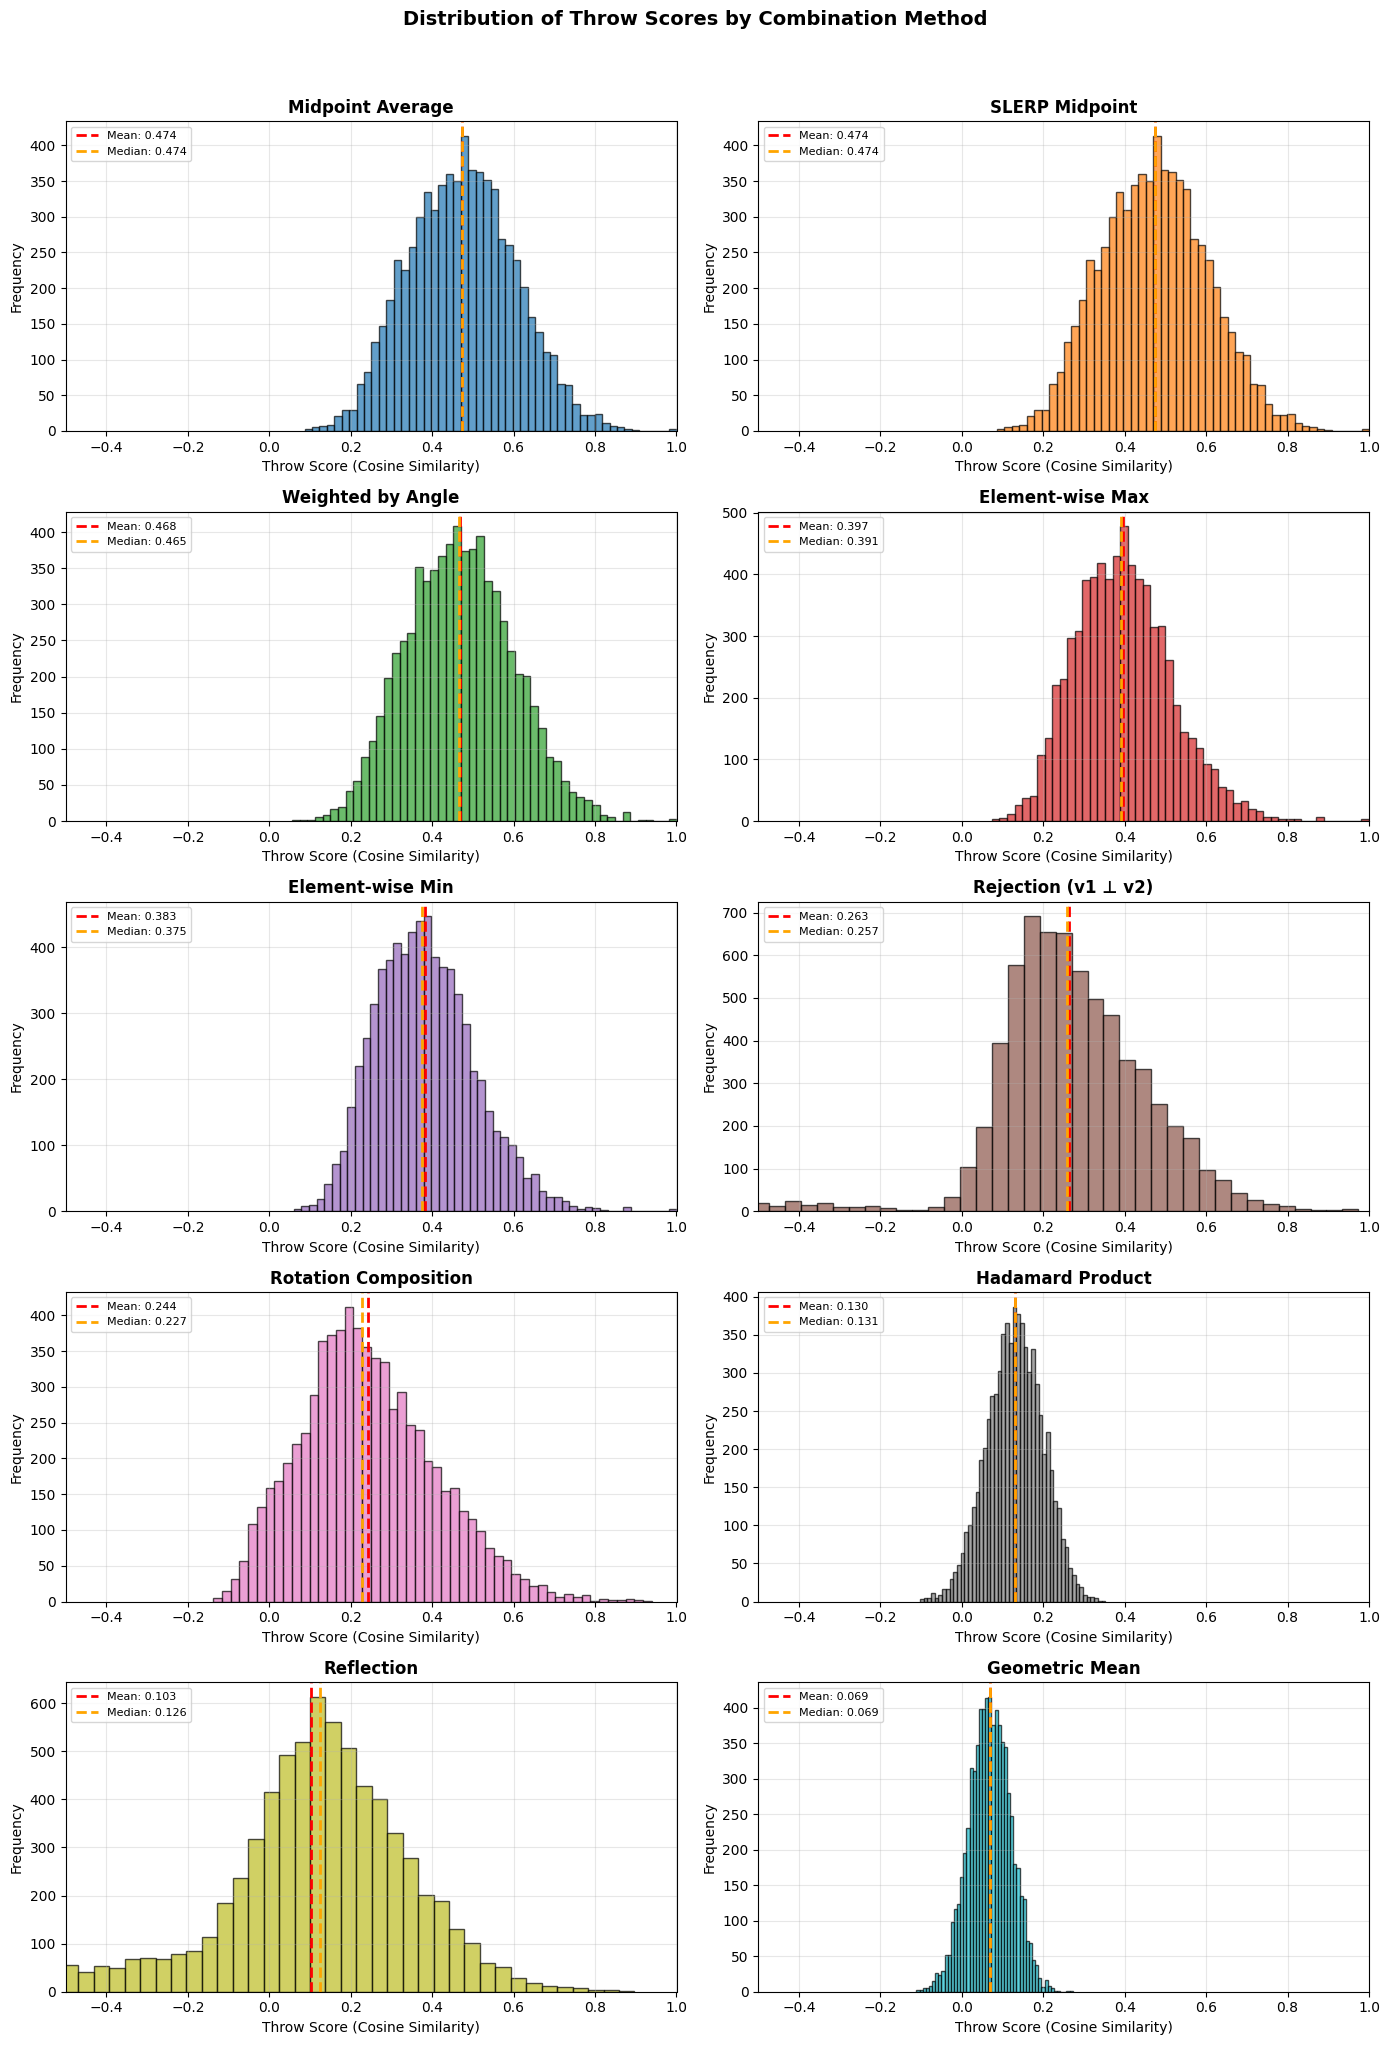


Total combinations analyzed: 7,013


In [ ]:
# Create frequency plots for all combination methods
n_methods = len(all_results)
n_cols = 2
n_rows = (n_methods + 1) // 2

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))
axes = axes.flatten()

# Sort methods by mean for consistent ordering
sorted_methods = sorted(all_results.items(), key=lambda x: x[1]['mean'], reverse=True)

colors = plt.cm.tab10(np.linspace(0, 1, n_methods))

for idx, (name, stats) in enumerate(sorted_methods):
    ax = axes[idx]
    scores_array = stats['scores_array']
    
    ax.hist(scores_array, bins=50, edgecolor='black', alpha=0.7, color=colors[idx])
    ax.axvline(stats['mean'], color='red', linestyle='--', linewidth=2, label=f"Mean: {stats['mean']:.3f}")
    ax.axvline(stats['median'], color='orange', linestyle='--', linewidth=2, label=f"Median: {stats['median']:.3f}")
    
    ax.set_xlabel('Throw Score (Cosine Similarity)', fontsize=10)
    ax.set_ylabel('Frequency', fontsize=10)
    ax.set_title(f'{name}', fontsize=12, fontweight='bold')
    ax.legend(fontsize=8, loc='upper left')
    ax.grid(True, alpha=0.3)
    ax.set_xlim(-0.5, 1.0)

# Hide any unused subplots
for idx in range(n_methods, len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Distribution of Throw Scores by Combination Method', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"\nTotal combinations analyzed: {len(all_results[list(all_results.keys())[0]]['scores']):,}")

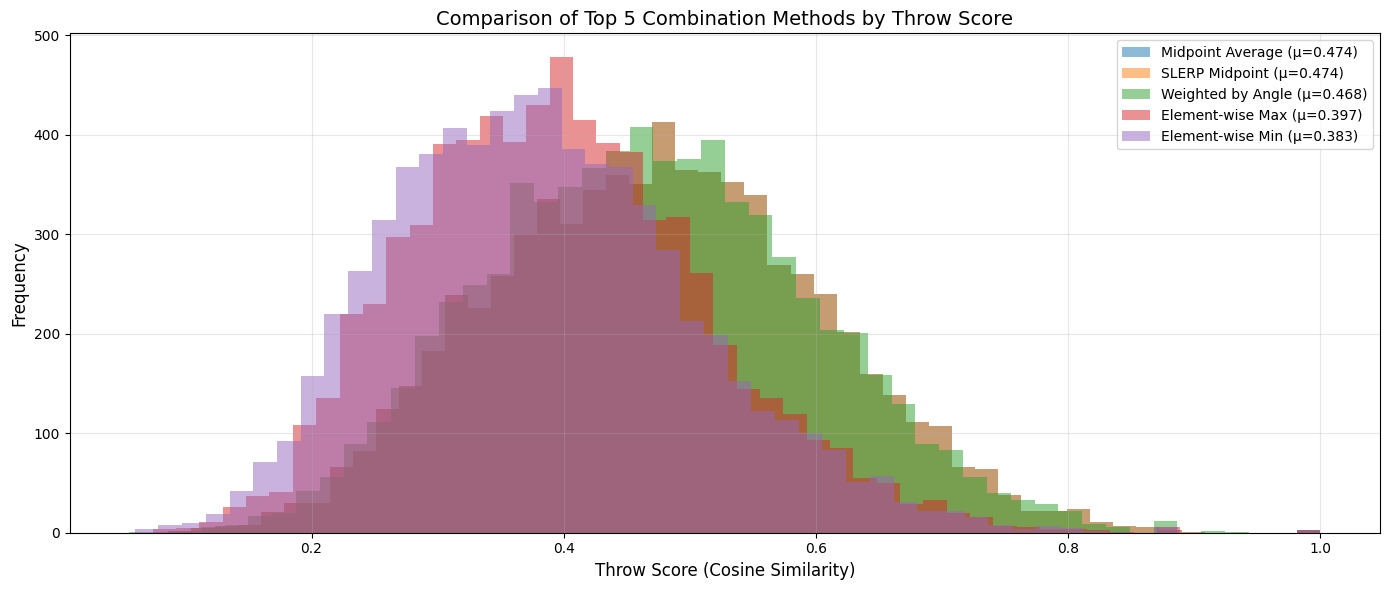

In [ ]:
# Overlay comparison of top methods
plt.figure(figsize=(14, 6))

# Pick top 5 methods by mean
top_methods = sorted_methods[:5]

for idx, (name, stats) in enumerate(top_methods):
    scores_array = stats['scores_array']
    plt.hist(scores_array, bins=50, alpha=0.5, label=f"{name} (μ={stats['mean']:.3f})")

plt.xlabel('Throw Score (Cosine Similarity)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Comparison of Top 5 Combination Methods by Throw Score', fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

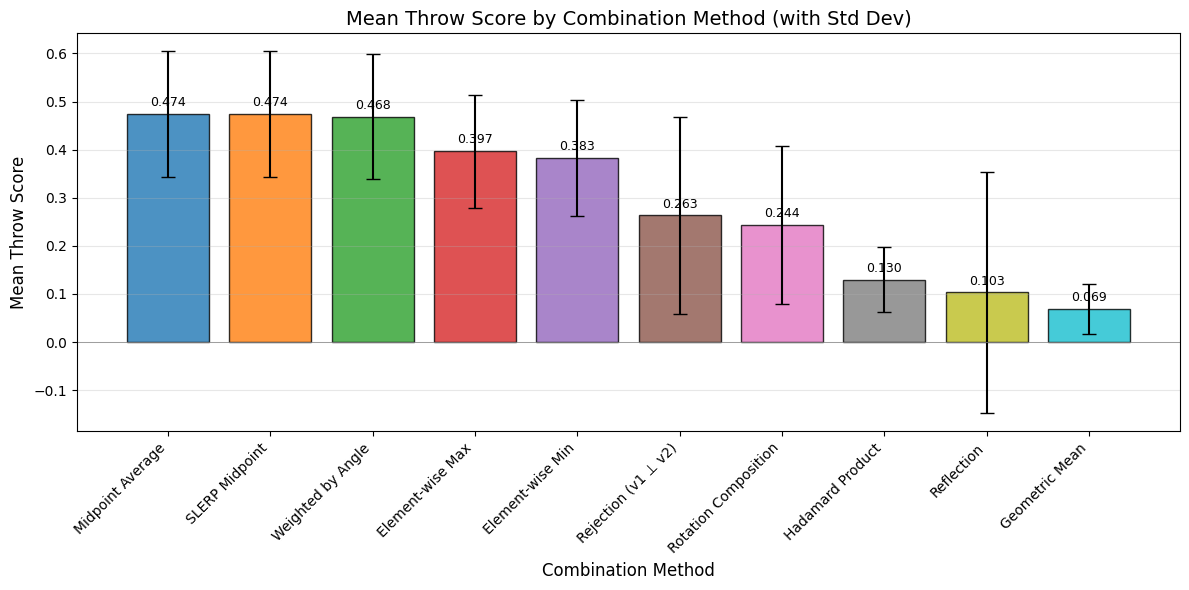


INTERPRETATION

Higher throw scores indicate the LLM's output is closer to that geometric expectation.

- Midpoint/SLERP: Does the LLM create semantic "blends" of the two inputs?
- Hadamard Product: Does the LLM emphasize shared dimensions?
- Rejection: Does the LLM output something orthogonal to one input?
- Reflection: Does the LLM "invert" one concept through another?
- Rotation Composition: Does the LLM apply transformations sequentially?
- Element-wise Max/Min: Does the LLM take extreme or conservative values?

The method with the highest mean throw score best describes the LLM's actual behavior.



In [ ]:
# Bar chart comparison of means
plt.figure(figsize=(12, 6))

methods = [name for name, _ in sorted_methods]
means = [stats['mean'] for _, stats in sorted_methods]
stds = [stats['std'] for _, stats in sorted_methods]

bars = plt.bar(methods, means, yerr=stds, capsize=5, color=colors[:len(methods)], alpha=0.8, edgecolor='black')
plt.axhline(y=0, color='gray', linestyle='-', linewidth=0.5)

plt.xlabel('Combination Method', fontsize=12)
plt.ylabel('Mean Throw Score', fontsize=12)
plt.title('Mean Throw Score by Combination Method (with Std Dev)', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar, mean in zip(bars, means):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{mean:.3f}', 
             ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# Print interpretation
print("\n" + "=" * 80)
print("INTERPRETATION")
print("=" * 80)
print("""
Higher throw scores indicate the LLM's output is closer to that geometric expectation.

- Midpoint/SLERP: Does the LLM create semantic "blends" of the two inputs?
- Hadamard Product: Does the LLM emphasize shared dimensions?
- Rejection: Does the LLM output something orthogonal to one input?
- Reflection: Does the LLM "invert" one concept through another?
- Rotation Composition: Does the LLM apply transformations sequentially?
- Element-wise Max/Min: Does the LLM take extreme or conservative values?

The method with the highest mean throw score best describes the LLM's actual behavior.
""")

## ML-Learned Combination Function

Train a neural network to learn the actual combination function from the data, then evaluate how well it predicts held-out combinations compared to the geometric methods.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split

# Prepare training data from combinations
print("Preparing training data...")

X_list = []  # Input: concatenated embeddings [emb1, emb2]
y_list = []  # Output: result embedding

seen = set()
for combo in combinations:
    from1, from2, result = combo['from1'], combo['from2'], combo['to']
    
    # Canonical key to avoid duplicates
    key = tuple(sorted([from1, from2])) + (result,)
    if key in seen:
        continue
    seen.add(key)
    
    if from1 not in embeddings or from2 not in embeddings or result not in embeddings:
        continue
    
    emb1 = embeddings[from1]
    emb2 = embeddings[from2]
    result_emb = embeddings[result]
    
    # Concatenate inputs (order-invariant: sort by first element)
    if emb1[0] > emb2[0]:
        emb1, emb2 = emb2, emb1
    
    X_list.append(np.concatenate([emb1, emb2]))
    y_list.append(result_emb)

X = np.array(X_list, dtype=np.float32)
y = np.array(y_list, dtype=np.float32)

print(f"Total samples: {len(X)}")
print(f"Input dimension: {X.shape[1]} (2 x {X.shape[1]//2})")
print(f"Output dimension: {y.shape[1]}")

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training samples: {len(X_train)}, Test samples: {len(X_test)}")

Preparing training data...
Total samples: 7013
Input dimension: 768 (2 x 384)
Output dimension: 384
Training samples: 5610, Test samples: 1403


In [ ]:
# Define neural network architectures

class CombinationMLP(nn.Module):
    """Simple MLP that learns to combine two embeddings."""
    def __init__(self, embed_dim=384, hidden_dims=[512, 384]):
        super().__init__()
        layers = []
        input_dim = embed_dim * 2
        
        for hidden_dim in hidden_dims:
            layers.append(nn.Linear(input_dim, hidden_dim))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(0.1))
            input_dim = hidden_dim
        
        layers.append(nn.Linear(input_dim, embed_dim))
        self.network = nn.Sequential(*layers)
    
    def forward(self, x):
        out = self.network(x)
        # Normalize output to unit sphere
        return out / (torch.norm(out, dim=1, keepdim=True) + 1e-10)


class ResidualCombination(nn.Module):
    """Network that predicts a residual from the midpoint."""
    def __init__(self, embed_dim=384, hidden_dim=256):
        super().__init__()
        self.embed_dim = embed_dim
        self.residual_net = nn.Sequential(
            nn.Linear(embed_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, embed_dim)
        )
    
    def forward(self, x):
        # Compute midpoint
        emb1 = x[:, :self.embed_dim]
        emb2 = x[:, self.embed_dim:]
        midpoint = (emb1 + emb2) / 2
        midpoint = midpoint / (torch.norm(midpoint, dim=1, keepdim=True) + 1e-10)
        
        # Add learned residual
        residual = self.residual_net(x)
        out = midpoint + 0.1 * residual  # Scale residual
        return out / (torch.norm(out, dim=1, keepdim=True) + 1e-10)


class AttentionCombination(nn.Module):
    """Uses attention to weight dimensions differently based on input."""
    def __init__(self, embed_dim=384, hidden_dim=128):
        super().__init__()
        self.embed_dim = embed_dim
        
        # Attention weights for each dimension
        self.attention = nn.Sequential(
            nn.Linear(embed_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, embed_dim),
            nn.Sigmoid()
        )
        
        # Transformation after weighted combination
        self.transform = nn.Sequential(
            nn.Linear(embed_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, embed_dim)
        )
    
    def forward(self, x):
        emb1 = x[:, :self.embed_dim]
        emb2 = x[:, self.embed_dim:]
        
        # Compute attention weights
        attn = self.attention(x)
        
        # Weighted combination
        combined = attn * emb1 + (1 - attn) * emb2
        
        # Transform
        out = combined + 0.1 * self.transform(combined)
        return out / (torch.norm(out, dim=1, keepdim=True) + 1e-10)


print("Defined 3 neural network architectures:")
print("  1. CombinationMLP: Simple feedforward network")
print("  2. ResidualCombination: Learns residual from midpoint")
print("  3. AttentionCombination: Attention-weighted combination")

Defined 3 neural network architectures:
  1. CombinationMLP: Simple feedforward network
  2. ResidualCombination: Learns residual from midpoint
  3. AttentionCombination: Attention-weighted combination


In [ ]:
def train_model(model, X_train, y_train, X_test, y_test, epochs=100, batch_size=256, lr=0.001):
    """Train a model and return training history."""
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Training on: {device}")
    
    model = model.to(device)
    
    # Convert to tensors
    X_train_t = torch.tensor(X_train, dtype=torch.float32)
    y_train_t = torch.tensor(y_train, dtype=torch.float32)
    X_test_t = torch.tensor(X_test, dtype=torch.float32).to(device)
    y_test_t = torch.tensor(y_test, dtype=torch.float32).to(device)
    
    train_dataset = TensorDataset(X_train_t, y_train_t)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    
    # Cosine similarity loss (we want to maximize similarity, so minimize negative)
    def cosine_loss(pred, target):
        cos_sim = torch.sum(pred * target, dim=1)
        return -cos_sim.mean()  # Negative because we minimize
    
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=10, factor=0.5)
    
    history = {'train_loss': [], 'test_loss': [], 'test_sim': []}
    
    for epoch in range(epochs):
        model.train()
        train_losses = []
        
        for batch_X, batch_y in train_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            
            optimizer.zero_grad()
            pred = model(batch_X)
            loss = cosine_loss(pred, batch_y)
            loss.backward()
            optimizer.step()
            
            train_losses.append(-loss.item())  # Store positive similarity
        
        # Evaluate on test set
        model.eval()
        with torch.no_grad():
            test_pred = model(X_test_t)
            test_loss = cosine_loss(test_pred, y_test_t)
            test_sim = -test_loss.item()
        
        train_sim = np.mean(train_losses)
        history['train_loss'].append(train_sim)
        history['test_loss'].append(test_sim)
        history['test_sim'].append(test_sim)
        
        scheduler.step(-test_sim)
        
        if (epoch + 1) % 20 == 0:
            print(f"  Epoch {epoch+1:3d}: Train Sim = {train_sim:.4f}, Test Sim = {test_sim:.4f}")
    
    return model, history


def evaluate_model_throw_scores(model, X_test, y_test):
    """Evaluate model predictions as throw scores."""
    device = next(model.parameters()).device
    model.eval()
    
    with torch.no_grad():
        X_test_t = torch.tensor(X_test, dtype=torch.float32).to(device)
        predictions = model(X_test_t).cpu().numpy()
    
    # Compute throw scores (cosine similarity between prediction and actual)
    throw_scores = []
    for pred, actual in zip(predictions, y_test):
        sim = np.dot(pred, actual) / (np.linalg.norm(pred) * np.linalg.norm(actual) + 1e-10)
        throw_scores.append(sim)
    
    return np.array(throw_scores)


print("Training functions defined.")

Training functions defined.


In [ ]:
# Train all models
embed_dim = X.shape[1] // 2
models_to_train = {
    'MLP': CombinationMLP(embed_dim=embed_dim, hidden_dims=[512, 384]),
    'Residual': ResidualCombination(embed_dim=embed_dim, hidden_dim=256),
    'Attention': AttentionCombination(embed_dim=embed_dim, hidden_dim=128),
}

trained_models = {}
model_histories = {}
ml_throw_scores = {}

print("=" * 70)
print("TRAINING ML MODELS")
print("=" * 70)

for name, model in models_to_train.items():
    print(f"\n--- Training {name} ---")
    trained_model, history = train_model(model, X_train, y_train, X_test, y_test, epochs=100)
    trained_models[name] = trained_model
    model_histories[name] = history
    
    # Evaluate throw scores on test set
    scores = evaluate_model_throw_scores(trained_model, X_test, y_test)
    ml_throw_scores[name] = {
        'scores_array': scores,
        'mean': np.mean(scores),
        'std': np.std(scores),
        'median': np.median(scores),
        'min': np.min(scores),
        'max': np.max(scores),
    }
    print(f"  Final Test Throw Score: Mean = {ml_throw_scores[name]['mean']:.4f}, Std = {ml_throw_scores[name]['std']:.4f}")

print("\n" + "=" * 70)
print("Training complete!")

TRAINING ML MODELS

--- Training MLP ---
Training on: cpu
  Epoch  20: Train Sim = 0.7070, Test Sim = 0.5511
  Epoch  20: Train Sim = 0.7070, Test Sim = 0.5511
  Epoch  40: Train Sim = 0.7880, Test Sim = 0.5327
  Epoch  40: Train Sim = 0.7880, Test Sim = 0.5327
  Epoch  60: Train Sim = 0.8030, Test Sim = 0.5275
  Epoch  60: Train Sim = 0.8030, Test Sim = 0.5275
  Epoch  80: Train Sim = 0.8070, Test Sim = 0.5262
  Epoch  80: Train Sim = 0.8070, Test Sim = 0.5262
  Epoch 100: Train Sim = 0.8077, Test Sim = 0.5260
  Final Test Throw Score: Mean = 0.5260, Std = 0.1800

--- Training Residual ---
Training on: cpu
  Epoch 100: Train Sim = 0.8077, Test Sim = 0.5260
  Final Test Throw Score: Mean = 0.5260, Std = 0.1800

--- Training Residual ---
Training on: cpu
  Epoch  20: Train Sim = 0.5941, Test Sim = 0.5624
  Epoch  20: Train Sim = 0.5941, Test Sim = 0.5624
  Epoch  40: Train Sim = 0.6396, Test Sim = 0.5648
  Epoch  40: Train Sim = 0.6396, Test Sim = 0.5648
  Epoch  60: Train Sim = 0.6631,

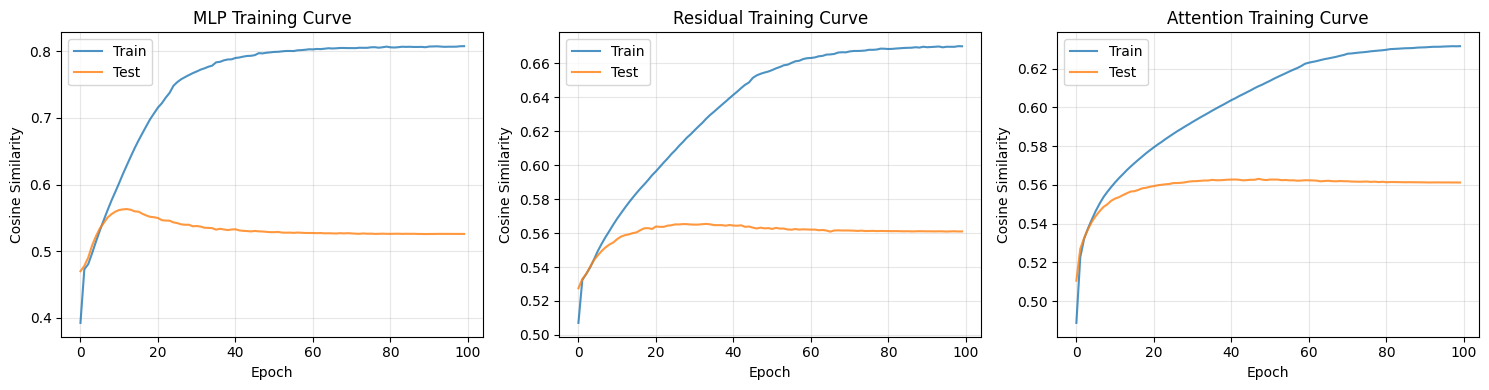

In [ ]:
# Plot training curves
fig, axes = plt.subplots(1, len(model_histories), figsize=(5*len(model_histories), 4))
if len(model_histories) == 1:
    axes = [axes]

for ax, (name, history) in zip(axes, model_histories.items()):
    ax.plot(history['train_loss'], label='Train', alpha=0.8)
    ax.plot(history['test_loss'], label='Test', alpha=0.8)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Cosine Similarity')
    ax.set_title(f'{name} Training Curve')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Compare ML models with geometric methods
# Note: ML models were evaluated on test set, geometric methods on all data
# For fair comparison, also compute geometric baselines on test set

print("Computing geometric baselines on test set for fair comparison...")

# We need to reconstruct which combinations are in test set
# Rebuild test set indices
test_indices = []
seen = set()
idx = 0
for combo in combinations:
    from1, from2, result = combo['from1'], combo['from2'], combo['to']
    key = tuple(sorted([from1, from2])) + (result,)
    if key in seen:
        continue
    seen.add(key)
    if from1 not in embeddings or from2 not in embeddings or result not in embeddings:
        continue
    test_indices.append(idx)
    idx += 1

# Get test combo details
_, test_combo_indices = train_test_split(range(len(X)), test_size=0.2, random_state=42)

# Compute geometric baselines on test combinations only
geo_test_results = {}
seen = set()
combo_list = []
idx = 0
for combo in combinations:
    from1, from2, result = combo['from1'], combo['from2'], combo['to']
    key = tuple(sorted([from1, from2])) + (result,)
    if key in seen:
        continue
    seen.add(key)
    if from1 not in embeddings or from2 not in embeddings or result not in embeddings:
        continue
    combo_list.append(combo)

test_combos = [combo_list[i] for i in test_combo_indices]

for name, func in combination_methods.items():
    scores = compute_throw_scores(test_combos, embeddings, func, name)
    scores_array = np.array([s['throw_score'] for s in scores])
    geo_test_results[name] = {
        'scores_array': scores_array,
        'mean': np.mean(scores_array),
        'std': np.std(scores_array),
    }

print(f"Computed baselines on {len(test_combos)} test combinations")

Computing geometric baselines on test set for fair comparison...
  [Rejection (v1 ⊥ v2)] Skipped 79 combinations due to normalization issues
Computed baselines on 1403 test combinations
  [Rejection (v1 ⊥ v2)] Skipped 79 combinations due to normalization issues
Computed baselines on 1403 test combinations


In [ ]:
# Combined comparison table
print("=" * 100)
print("COMPARISON: ML MODELS vs GEOMETRIC METHODS (on test set)")
print("=" * 100)
print(f"{'Method':<30} {'Type':<12} {'Mean':>10} {'Std':>10} {'Median':>10}")
print("-" * 100)

# Combine all results
all_test_results = []

for name, stats in ml_throw_scores.items():
    all_test_results.append((f"ML: {name}", 'ML', stats['mean'], stats['std'], stats['median']))

for name, stats in geo_test_results.items():
    all_test_results.append((name, 'Geometric', stats['mean'], stats['std'], np.median(stats['scores_array'])))

# Sort by mean
all_test_results.sort(key=lambda x: x[2], reverse=True)

for name, method_type, mean, std, median in all_test_results:
    print(f"{name:<30} {method_type:<12} {mean:>10.4f} {std:>10.4f} {median:>10.4f}")

print("-" * 100)

# Find best overall
best = all_test_results[0]
print(f"\nBest method: {best[0]} ({best[1]}) with mean throw score = {best[2]:.4f}")

COMPARISON: ML MODELS vs GEOMETRIC METHODS (on test set)
Method                         Type               Mean        Std     Median
----------------------------------------------------------------------------------------------------
ML: Attention                  ML               0.5612     0.1271     0.5544
ML: Residual                   ML               0.5610     0.1365     0.5539
ML: MLP                        ML               0.5260     0.1800     0.5004
Midpoint Average               Geometric        0.4726     0.1351     0.4703
SLERP Midpoint                 Geometric        0.4726     0.1351     0.4703
Weighted by Angle              Geometric        0.4661     0.1340     0.4605
Element-wise Max               Geometric        0.3969     0.1228     0.3893
Element-wise Min               Geometric        0.3827     0.1268     0.3729
Rejection (v1 ⊥ v2)            Geometric        0.2675     0.2042     0.2599
Rotation Composition           Geometric        0.2455     0.1641     0.

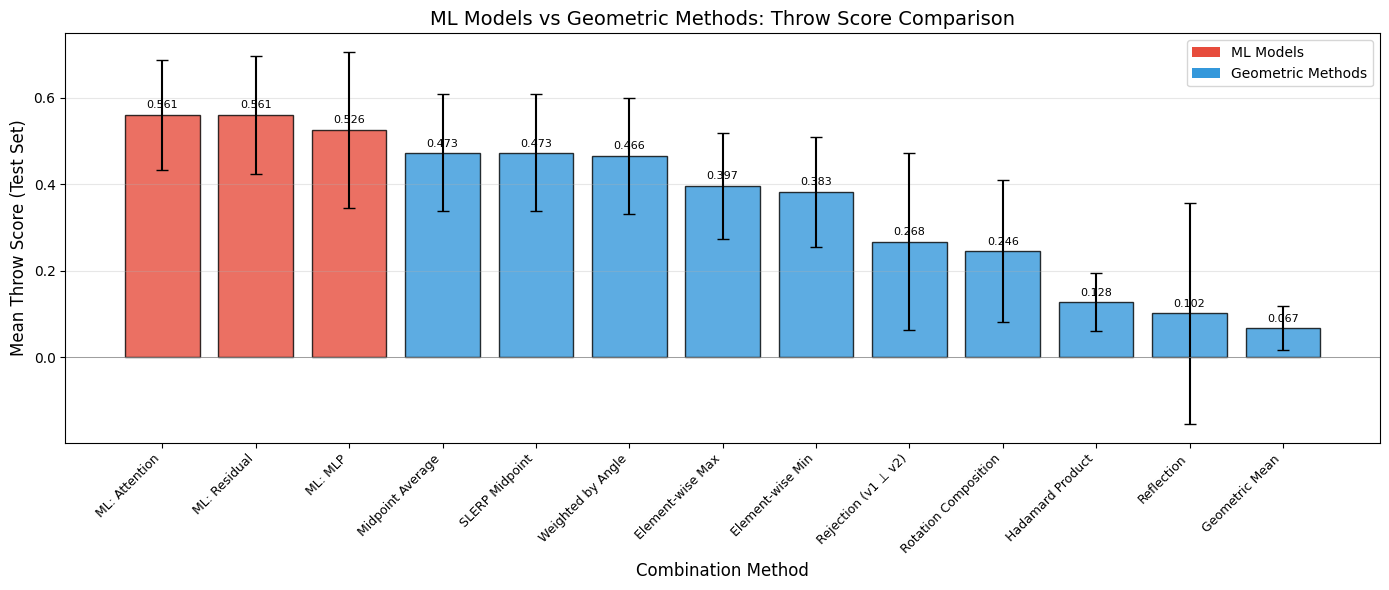

In [ ]:
# Bar chart comparison: ML vs Geometric
plt.figure(figsize=(14, 6))

# Prepare data
names = [r[0] for r in all_test_results]
means = [r[2] for r in all_test_results]
stds = [r[3] for r in all_test_results]
types = [r[1] for r in all_test_results]

# Color by type
colors = ['#e74c3c' if t == 'ML' else '#3498db' for t in types]

bars = plt.bar(names, means, yerr=stds, capsize=4, color=colors, alpha=0.8, edgecolor='black')

plt.axhline(y=0, color='gray', linestyle='-', linewidth=0.5)
plt.xlabel('Combination Method', fontsize=12)
plt.ylabel('Mean Throw Score (Test Set)', fontsize=12)
plt.title('ML Models vs Geometric Methods: Throw Score Comparison', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.grid(True, alpha=0.3, axis='y')

# Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#e74c3c', label='ML Models'),
                   Patch(facecolor='#3498db', label='Geometric Methods')]
plt.legend(handles=legend_elements, loc='upper right')

# Add value labels
for bar, mean in zip(bars, means):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{mean:.3f}', 
             ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

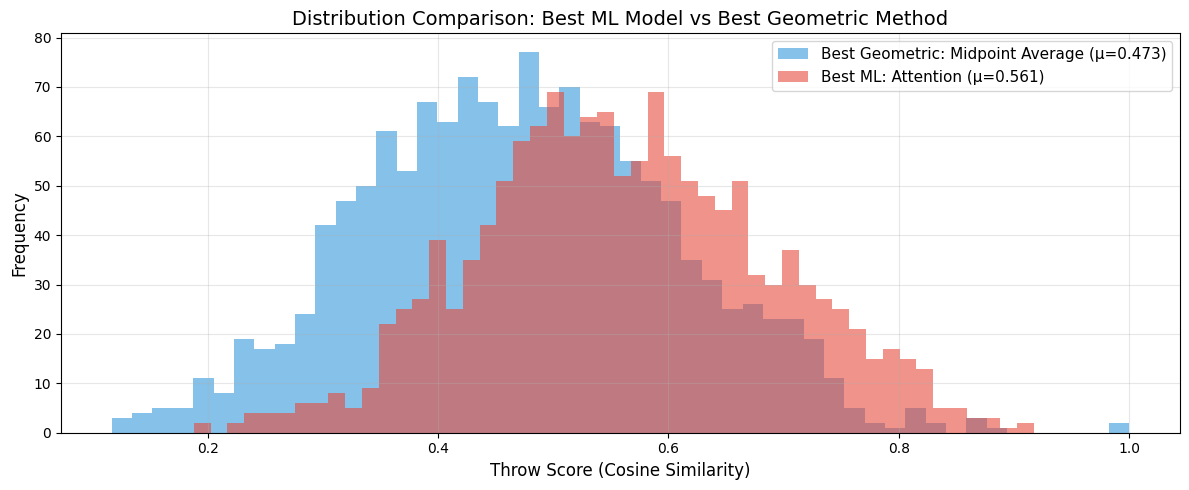


INTERPRETATION

Best ML Model: Attention
  - Mean throw score: 0.5612
  - This represents how well the learned function predicts LLM outputs

Best Geometric Method: Midpoint Average
  - Mean throw score: 0.4726
  - This is a fixed mathematical formula

Improvement from ML: +0.0886 (+18.8%)

If ML significantly outperforms geometric methods, it suggests the LLM's combination
behavior is complex and not well-captured by simple geometric operations.

If geometric methods are competitive, the LLM may be doing something close to
semantic interpolation (midpoint/SLERP) in embedding space.



In [ ]:
# Histogram comparison: Best ML vs Best Geometric
best_ml = max(ml_throw_scores.items(), key=lambda x: x[1]['mean'])
best_geo = max(geo_test_results.items(), key=lambda x: x[1]['mean'])

plt.figure(figsize=(12, 5))

plt.hist(best_geo[1]['scores_array'], bins=50, alpha=0.6, label=f"Best Geometric: {best_geo[0]} (μ={best_geo[1]['mean']:.3f})", color='#3498db')
plt.hist(best_ml[1]['scores_array'], bins=50, alpha=0.6, label=f"Best ML: {best_ml[0]} (μ={best_ml[1]['mean']:.3f})", color='#e74c3c')

plt.xlabel('Throw Score (Cosine Similarity)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Distribution Comparison: Best ML Model vs Best Geometric Method', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Interpretation
improvement = best_ml[1]['mean'] - best_geo[1]['mean']
print(f"\n{'=' * 80}")
print("INTERPRETATION")
print(f"{'=' * 80}")
print(f"""
Best ML Model: {best_ml[0]}
  - Mean throw score: {best_ml[1]['mean']:.4f}
  - This represents how well the learned function predicts LLM outputs

Best Geometric Method: {best_geo[0]}
  - Mean throw score: {best_geo[1]['mean']:.4f}
  - This is a fixed mathematical formula

Improvement from ML: {improvement:+.4f} ({improvement/best_geo[1]['mean']*100:+.1f}%)

If ML significantly outperforms geometric methods, it suggests the LLM's combination
behavior is complex and not well-captured by simple geometric operations.

If geometric methods are competitive, the LLM may be doing something close to
semantic interpolation (midpoint/SLERP) in embedding space.
""")

## Per-Resource Throw Score Analysis

Using the midpoint average method, analyze how throw scores vary by resource.
Calculate the average incoming throw score for each resource (averaging all combinations that produce it).

In [ ]:
# Compute throw scores for all combinations using midpoint average
print("Computing throw scores using Midpoint Average method...")

throw_scores_all = []
seen = set()

for combo in combinations:
    from1, from2, result = combo['from1'], combo['from2'], combo['to']
    
    # Canonical key to avoid duplicates
    key = tuple(sorted([from1, from2])) + (result,)
    if key in seen:
        continue
    seen.add(key)
    
    if from1 not in embeddings or from2 not in embeddings or result not in embeddings:
        continue
    
    emb1 = embeddings[from1]
    emb2 = embeddings[from2]
    actual = embeddings[result]
    
    # Compute expected using midpoint average
    expected = midpoint_average(emb1, emb2)
    
    if expected is None:
        continue
    
    # Throw score = cosine similarity between expected and actual
    throw_score = cosine_similarity(expected, actual)
    
    throw_scores_all.append({
        'from1': from1,
        'from2': from2,
        'result': result,
        'throw_score': throw_score
    })

# Overall statistics
all_scores = np.array([s['throw_score'] for s in throw_scores_all])
print(f"\n{'=' * 60}")
print("OVERALL THROW SCORE STATISTICS (Midpoint Average)")
print(f"{'=' * 60}")
print(f"Total combinations analyzed: {len(throw_scores_all):,}")
print(f"Mean throw score:   {np.mean(all_scores):.4f}")
print(f"Std throw score:    {np.std(all_scores):.4f}")
print(f"Median throw score: {np.median(all_scores):.4f}")
print(f"Min throw score:    {np.min(all_scores):.4f}")
print(f"Max throw score:    {np.max(all_scores):.4f}")

Computing throw scores using Midpoint Average method...

OVERALL THROW SCORE STATISTICS (Midpoint Average)
Total combinations analyzed: 7,013
Mean throw score:   0.4740
Std throw score:    0.1303
Median throw score: 0.4739
Min throw score:    0.0865
Max throw score:    1.0000


In [ ]:
# Calculate average incoming throw score for each resource
from collections import defaultdict

# Group throw scores by result
scores_by_result = defaultdict(list)
for entry in throw_scores_all:
    scores_by_result[entry['result']].append(entry['throw_score'])

# Compute average and count for each resource
resource_stats = []
for resource, scores in scores_by_result.items():
    resource_stats.append({
        'resource': resource,
        'avg_throw_score': np.mean(scores),
        'std_throw_score': np.std(scores) if len(scores) > 1 else 0,
        'incoming_edges': len(scores),  # Number of combinations that produce this resource
        'min_score': np.min(scores),
        'max_score': np.max(scores),
    })

# Convert to arrays for plotting
resource_df = sorted(resource_stats, key=lambda x: x['incoming_edges'], reverse=True)

incoming_edges = np.array([r['incoming_edges'] for r in resource_df])
avg_throw_scores = np.array([r['avg_throw_score'] for r in resource_df])
resource_names = [r['resource'] for r in resource_df]

print(f"Analyzed {len(resource_df)} unique resources")
print(f"Incoming edges range: {incoming_edges.min()} to {incoming_edges.max()}")
print(f"Average throw score range: {avg_throw_scores.min():.4f} to {avg_throw_scores.max():.4f}")

Analyzed 3135 unique resources
Incoming edges range: 1 to 65
Average throw score range: 0.0865 to 1.0000


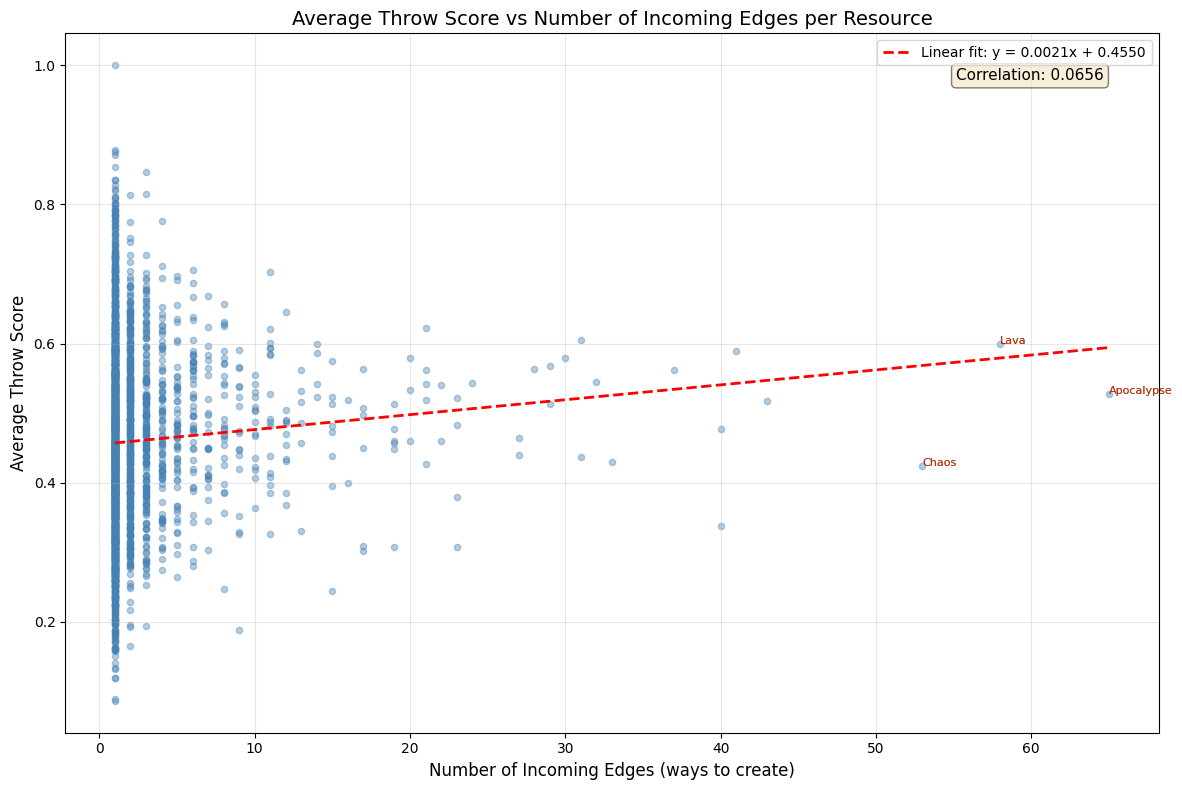


Pearson correlation coefficient: 0.0656


In [ ]:
# Scatterplot: Incoming edges vs Average throw score
plt.figure(figsize=(12, 8))

plt.scatter(incoming_edges, avg_throw_scores, alpha=0.4, s=20, c='steelblue')

# Add trend line
z = np.polyfit(incoming_edges, avg_throw_scores, 1)
p = np.poly1d(z)
x_line = np.linspace(incoming_edges.min(), incoming_edges.max(), 100)
plt.plot(x_line, p(x_line), 'r--', linewidth=2, label=f'Linear fit: y = {z[0]:.4f}x + {z[1]:.4f}')

# Label some interesting points (highest/lowest avg throw scores with many edges)
# High incoming edges with notable throw scores
high_edge_resources = [r for r in resource_df if r['incoming_edges'] >= 50]
if high_edge_resources:
    # Top 5 highest throw scores among high-edge resources
    top_high_edge = sorted(high_edge_resources, key=lambda x: x['avg_throw_score'], reverse=True)[:5]
    for r in top_high_edge:
        plt.annotate(r['resource'], (r['incoming_edges'], r['avg_throw_score']), 
                     fontsize=8, alpha=0.8, color='green')
    # Bottom 5 lowest throw scores among high-edge resources
    bottom_high_edge = sorted(high_edge_resources, key=lambda x: x['avg_throw_score'])[:5]
    for r in bottom_high_edge:
        plt.annotate(r['resource'], (r['incoming_edges'], r['avg_throw_score']), 
                     fontsize=8, alpha=0.8, color='red')

plt.xlabel('Number of Incoming Edges (ways to create)', fontsize=12)
plt.ylabel('Average Throw Score', fontsize=12)
plt.title('Average Throw Score vs Number of Incoming Edges per Resource', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)

# Compute correlation
correlation = np.corrcoef(incoming_edges, avg_throw_scores)[0, 1]
plt.text(0.95, 0.95, f'Correlation: {correlation:.4f}', transform=plt.gca().transAxes,
         fontsize=11, verticalalignment='top', horizontalalignment='right',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

print(f"\nPearson correlation coefficient: {correlation:.4f}")

In [ ]:
# Show top and bottom resources by average throw score
print("=" * 90)
print("TOP 20 RESOURCES BY AVERAGE THROW SCORE (most predictable)")
print("=" * 90)
print(f"{'Resource':<35} {'Avg Score':>12} {'Std':>10} {'Incoming Edges':>15}")
print("-" * 90)

sorted_by_score = sorted(resource_df, key=lambda x: x['avg_throw_score'], reverse=True)
for r in sorted_by_score[:20]:
    print(f"{r['resource']:<35} {r['avg_throw_score']:>12.4f} {r['std_throw_score']:>10.4f} {r['incoming_edges']:>15}")

print("\n" + "=" * 90)
print("BOTTOM 20 RESOURCES BY AVERAGE THROW SCORE (least predictable)")
print("=" * 90)
print(f"{'Resource':<35} {'Avg Score':>12} {'Std':>10} {'Incoming Edges':>15}")
print("-" * 90)

for r in sorted_by_score[-20:]:
    print(f"{r['resource']:<35} {r['avg_throw_score']:>12.4f} {r['std_throw_score']:>10.4f} {r['incoming_edges']:>15}")

TOP 20 RESOURCES BY AVERAGE THROW SCORE (most predictable)
Resource                               Avg Score        Std  Incoming Edges
------------------------------------------------------------------------------------------
Kinkysushi                                1.0000     0.0000               1
Railroad                                  0.8783     0.0000               1
Buttons                                   0.8755     0.0000               1
Candlelight                               0.8708     0.0000               1
Pooglepet                                 0.8532     0.0000               1
Sea                                       0.8458     0.0282               3
Kitty Bee                                 0.8354     0.0000               1
Spiderman                                 0.8349     0.0000               1
Devil Maid                                0.8274     0.0000               1
Double Rainbow                            0.8216     0.0000               1
Jeans         

/var/folders/44/p5k6fqc94zggtcj6fvjx5vr40000gn/T/ipykernel_55921/4086603165.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax1.boxplot(non_empty_scores, labels=non_empty_labels, patch_artist=True)


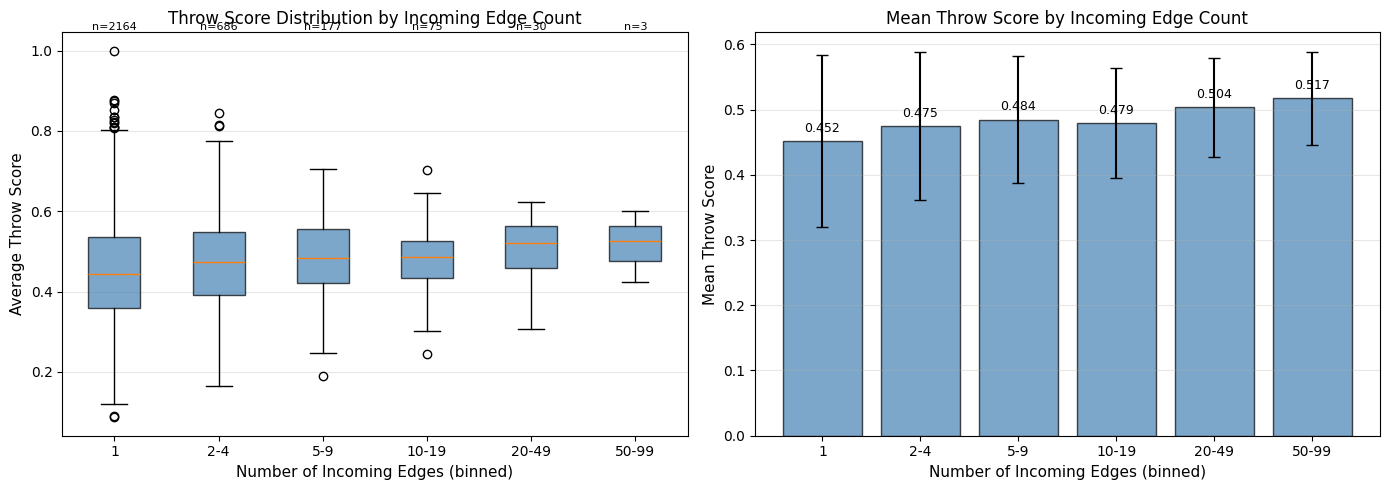


Binned Summary:
Bin             Count       Mean        Std
---------------------------------------------
1                2164     0.4517     0.1319
2-4               686     0.4747     0.1141
5-9               177     0.4843     0.0976
10-19              75     0.4790     0.0844
20-49              30     0.5036     0.0760
50-99               3     0.5172     0.0718


In [ ]:
# Binned analysis: Average throw score by incoming edge count buckets
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Box plot by edge count buckets
ax1 = axes[0]
bins = [1, 2, 5, 10, 20, 50, 100, 500, max(incoming_edges)+1]
bin_labels = ['1', '2-4', '5-9', '10-19', '20-49', '50-99', '100-499', '500+']
binned_scores = {label: [] for label in bin_labels}

for r in resource_df:
    edges = r['incoming_edges']
    score = r['avg_throw_score']
    for i, (low, high) in enumerate(zip(bins[:-1], bins[1:])):
        if low <= edges < high:
            binned_scores[bin_labels[i]].append(score)
            break

# Filter out empty bins
non_empty_labels = [l for l in bin_labels if len(binned_scores[l]) > 0]
non_empty_scores = [binned_scores[l] for l in non_empty_labels]

bp = ax1.boxplot(non_empty_scores, labels=non_empty_labels, patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('steelblue')
    patch.set_alpha(0.7)

ax1.set_xlabel('Number of Incoming Edges (binned)', fontsize=11)
ax1.set_ylabel('Average Throw Score', fontsize=11)
ax1.set_title('Throw Score Distribution by Incoming Edge Count', fontsize=12)
ax1.grid(True, alpha=0.3, axis='y')

# Add count labels
for i, label in enumerate(non_empty_labels):
    count = len(binned_scores[label])
    ax1.text(i+1, ax1.get_ylim()[1], f'n={count}', ha='center', va='bottom', fontsize=8)

# Right: Mean throw score per bin with error bars
ax2 = axes[1]
bin_means = [np.mean(binned_scores[l]) for l in non_empty_labels]
bin_stds = [np.std(binned_scores[l]) for l in non_empty_labels]
bin_counts = [len(binned_scores[l]) for l in non_empty_labels]

bars = ax2.bar(non_empty_labels, bin_means, yerr=bin_stds, capsize=4, 
               color='steelblue', alpha=0.7, edgecolor='black')
ax2.set_xlabel('Number of Incoming Edges (binned)', fontsize=11)
ax2.set_ylabel('Mean Throw Score', fontsize=11)
ax2.set_title('Mean Throw Score by Incoming Edge Count', fontsize=12)
ax2.grid(True, alpha=0.3, axis='y')

# Add mean labels
for bar, mean in zip(bars, bin_means):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{mean:.3f}', 
             ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# Print summary
print("\nBinned Summary:")
print(f"{'Bin':<12} {'Count':>8} {'Mean':>10} {'Std':>10}")
print("-" * 45)
for label, mean, std, count in zip(non_empty_labels, bin_means, bin_stds, bin_counts):
    print(f"{label:<12} {count:>8} {mean:>10.4f} {std:>10.4f}")

In [ ]:
# Calculate average outgoing throw score for each resource
# (average score of all combinations where the resource is a component)

outgoing_scores_by_resource = defaultdict(list)
combinations_by_resource = defaultdict(list)  # Track the actual combinations

for entry in throw_scores_all:
    # Add score to both input resources
    outgoing_scores_by_resource[entry['from1']].append(entry['throw_score'])
    outgoing_scores_by_resource[entry['from2']].append(entry['throw_score'])
    
    # Track the combinations
    combinations_by_resource[entry['from1']].append(entry)
    combinations_by_resource[entry['from2']].append(entry)

# Compute stats for each resource
outgoing_stats = []
for resource, scores in outgoing_scores_by_resource.items():
    outgoing_stats.append({
        'resource': resource,
        'avg_outgoing_score': np.mean(scores),
        'std_outgoing_score': np.std(scores) if len(scores) > 1 else 0,
        'outgoing_edges': len(scores),
        'min_score': np.min(scores),
        'max_score': np.max(scores),
    })

# Filter to resources with 5+ combinations
MIN_COMBINATIONS = 5
filtered_stats = [r for r in outgoing_stats if r['outgoing_edges'] >= MIN_COMBINATIONS]
print(f"Filtered to {len(filtered_stats)} resources with {MIN_COMBINATIONS}+ outgoing combinations")

# Sort by average outgoing score
sorted_outgoing = sorted(filtered_stats, key=lambda x: x['avg_outgoing_score'], reverse=True)

def print_resource_details(r, rank, total):
    """Print details for a resource including its combinations."""
    print(f"\n{'=' * 100}")
    print(f"#{rank}/{total}: {r['resource']}")
    print(f"{'=' * 100}")
    print(f"  Avg Outgoing Score: {r['avg_outgoing_score']:.4f}")
    print(f"  Std: {r['std_outgoing_score']:.4f}")
    print(f"  Outgoing Edges: {r['outgoing_edges']}")
    print()
    
    # Get and sort combinations for this resource
    combos = combinations_by_resource[r['resource']]
    combos_sorted = sorted(combos, key=lambda x: x['throw_score'], reverse=True)
    
    print(f"  {'From1':<25} {'From2':<25} {'Result':<25} {'Score':>10}")
    print(f"  {'-' * 90}")
    for c in combos_sorted:
        print(f"  {c['from1']:<25} {c['from2']:<25} {c['result']:<25} {c['throw_score']:>10.4f}")

# TOP 10
print("\n" + "#" * 100)
print("TOP 10 RESOURCES BY AVERAGE OUTGOING THROW SCORE")
print(f"(Resources with {MIN_COMBINATIONS}+ combinations that produce the most predictable results)")
print("#" * 100)

for i, r in enumerate(sorted_outgoing[:10], 1):
    print_resource_details(r, i, len(sorted_outgoing))

# BOTTOM 10
print("\n\n" + "#" * 100)
print("BOTTOM 10 RESOURCES BY AVERAGE OUTGOING THROW SCORE")
print(f"(Resources with {MIN_COMBINATIONS}+ combinations that produce the least predictable results)")
print("#" * 100)

for i, r in enumerate(sorted_outgoing[-10:][::-1], 1):
    rank = len(sorted_outgoing) - 10 + (10 - i + 1)
    print_resource_details(r, rank, len(sorted_outgoing))

# Look up specific resources
print("\n\n" + "=" * 90)
print("SPECIFIC RESOURCE LOOKUP")
print("=" * 90)

lookup_resources = ['L', 'Porcupine']
outgoing_dict = {r['resource']: r for r in outgoing_stats}

for name in lookup_resources:
    if name in outgoing_dict:
        r = outgoing_dict[name]
        # Find rank in filtered list
        if r['outgoing_edges'] >= MIN_COMBINATIONS:
            rank = next((i+1 for i, x in enumerate(sorted_outgoing) if x['resource'] == name), 'N/A')
            rank_str = f"{rank} / {len(sorted_outgoing)}"
        else:
            rank_str = f"N/A (only {r['outgoing_edges']} combinations, need {MIN_COMBINATIONS}+)"
        
        print(f"\n{name}:")
        print(f"  Rank:                  {rank_str}")
        print(f"  Avg Outgoing Score:    {r['avg_outgoing_score']:.4f}")
        print(f"  Std:                   {r['std_outgoing_score']:.4f}")
        print(f"  Outgoing Edges:        {r['outgoing_edges']}")
        print(f"  Min Score:             {r['min_score']:.4f}")
        print(f"  Max Score:             {r['max_score']:.4f}")
    else:
        print(f"\n{name}: Not found in outgoing stats (may not be used as a component)")

Filtered to 771 resources with 5+ outgoing combinations

####################################################################################################
TOP 10 RESOURCES BY AVERAGE OUTGOING THROW SCORE
(Resources with 5+ combinations that produce the most predictable results)
####################################################################################################

#1/771: Railway
  Avg Outgoing Score: 0.7290
  Std: 0.1250
  Outgoing Edges: 6

  From1                     From2                     Result                         Score
  ------------------------------------------------------------------------------------------
  Railway                   Railway                   Railroad                      0.8783
  Railway                   Railway                   Railroad                      0.8783
  Railway                   Freight                   Train                         0.7539
  Railway                   Headlamp                  Locomotive               

/var/folders/44/p5k6fqc94zggtcj6fvjx5vr40000gn/T/ipykernel_55921/3410425066.py:34: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax2.boxplot(data, labels=labels, vert=True, patch_artist=True)


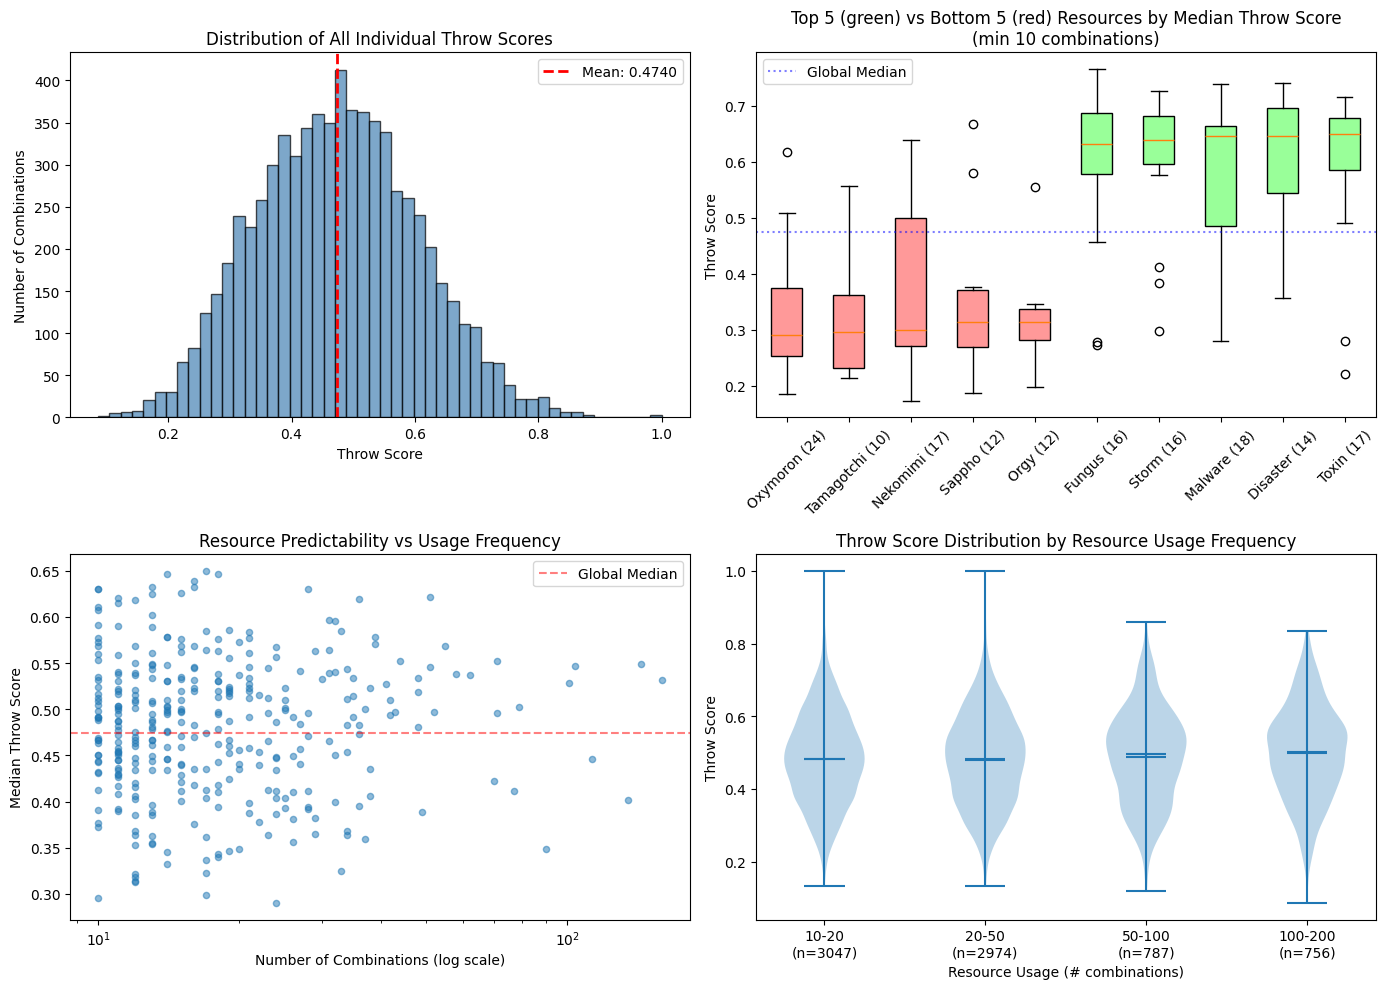


Resources with 10+ combinations: 348

Top 5 Most Predictable Resources (by median throw score):
  Fungus: median=0.6323, mean=0.5984, n=16
  Storm: median=0.6385, mean=0.5987, n=16
  Malware: median=0.6463, mean=0.5775, n=18
  Disaster: median=0.6465, mean=0.6114, n=14
  Toxin: median=0.6499, mean=0.5890, n=17

Bottom 5 Least Predictable Resources (by median throw score):
  Oxymoron: median=0.2903, mean=0.3190, n=24
  Tamagotchi: median=0.2959, mean=0.3129, n=10
  Nekomimi: median=0.2985, mean=0.3897, n=17
  Sappho: median=0.3130, mean=0.3492, n=12
  Orgy: median=0.3143, mean=0.3208, n=12


In [ ]:
# Distribution of throw scores by resource - weighted properly
# Instead of averaging, we show all individual scores to see which resources 
# are involved in more/less predictable combinations

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Histogram of individual throw scores (baseline)
ax1 = axes[0, 0]
all_individual_scores = [entry['throw_score'] for entry in throw_scores_all]
ax1.hist(all_individual_scores, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
ax1.axvline(np.mean(all_individual_scores), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(all_individual_scores):.4f}')
ax1.set_xlabel('Throw Score')
ax1.set_ylabel('Number of Combinations')
ax1.set_title('Distribution of All Individual Throw Scores')
ax1.legend()

# 2. Box plot of top/bottom resources by MEDIAN throw score (not mean)
ax2 = axes[0, 1]
MIN_COMBOS = 10  # Require more combinations for reliable median
resource_scores = {}
for resource, scores in outgoing_scores_by_resource.items():
    if len(scores) >= MIN_COMBOS:
        resource_scores[resource] = scores

# Sort by median
sorted_resources = sorted(resource_scores.items(), key=lambda x: np.median(x[1]))
top_5 = sorted_resources[-5:]  # Highest median (most predictable)
bottom_5 = sorted_resources[:5]  # Lowest median (least predictable)

selected = bottom_5 + top_5
labels = [f"{r[0][:15]}... ({len(r[1])})" if len(r[0]) > 15 else f"{r[0]} ({len(r[1])})" for r in selected]
data = [r[1] for r in selected]

bp = ax2.boxplot(data, labels=labels, vert=True, patch_artist=True)
colors = ['#ff9999'] * 5 + ['#99ff99'] * 5
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
ax2.set_ylabel('Throw Score')
ax2.set_title(f'Top 5 (green) vs Bottom 5 (red) Resources by Median Throw Score\n(min {MIN_COMBOS} combinations)')
ax2.tick_params(axis='x', rotation=45)
ax2.axhline(np.median(all_individual_scores), color='blue', linestyle=':', alpha=0.5, label='Global Median')
ax2.legend()

# 3. Scatter: Number of combinations vs Median throw score per resource
ax3 = axes[1, 0]
n_combos = [len(scores) for scores in resource_scores.values()]
medians = [np.median(scores) for scores in resource_scores.values()]
ax3.scatter(n_combos, medians, alpha=0.5, s=20)
ax3.set_xlabel('Number of Combinations (log scale)')
ax3.set_ylabel('Median Throw Score')
ax3.set_title('Resource Predictability vs Usage Frequency')
ax3.set_xscale('log')
ax3.axhline(np.median(all_individual_scores), color='red', linestyle='--', alpha=0.5, label='Global Median')
ax3.legend()

# 4. Violin plot showing score distributions for resources binned by usage
ax4 = axes[1, 1]
# Bin resources by number of combinations
usage_bins = [(10, 20), (20, 50), (50, 100), (100, 200), (200, float('inf'))]
bin_labels = ['10-20', '20-50', '50-100', '100-200', '200+']
binned_scores = {label: [] for label in bin_labels}

for resource, scores in resource_scores.items():
    n = len(scores)
    for (low, high), label in zip(usage_bins, bin_labels):
        if low <= n < high:
            binned_scores[label].extend(scores)  # Add ALL individual scores
            break

# Filter out empty bins
non_empty_labels = [l for l in bin_labels if len(binned_scores[l]) > 0]
non_empty_scores = [binned_scores[l] for l in non_empty_labels]

parts = ax4.violinplot(non_empty_scores, positions=range(len(non_empty_labels)), showmeans=True, showmedians=True)
ax4.set_xticks(range(len(non_empty_labels)))
ax4.set_xticklabels([f"{l}\n(n={len(binned_scores[l])})" for l in non_empty_labels])
ax4.set_xlabel('Resource Usage (# combinations)')
ax4.set_ylabel('Throw Score')
ax4.set_title('Throw Score Distribution by Resource Usage Frequency')

plt.tight_layout()
plt.show()

# Print summary statistics
print(f"\nResources with {MIN_COMBOS}+ combinations: {len(resource_scores)}")
print(f"\nTop 5 Most Predictable Resources (by median throw score):")
for r, scores in top_5:
    print(f"  {r}: median={np.median(scores):.4f}, mean={np.mean(scores):.4f}, n={len(scores)}")

print(f"\nBottom 5 Least Predictable Resources (by median throw score):")
for r, scores in bottom_5:
    print(f"  {r}: median={np.median(scores):.4f}, mean={np.mean(scores):.4f}, n={len(scores)}")

In [ ]:
# List all combinations for top 5 and bottom 5 resources by median throw score
# Including cosine similarity between input vectors

def cosine_similarity(v1, v2):
    """Compute cosine similarity between two vectors."""
    dot = np.dot(v1, v2)
    norm1 = np.linalg.norm(v1)
    norm2 = np.linalg.norm(v2)
    if norm1 == 0 or norm2 == 0:
        return 0.0
    return dot / (norm1 * norm2)

def print_resource_combinations_with_input_sim(resource_name, combos, embeddings):
    """Print all combinations involving a resource, sorted by throw score, with input cosine similarity."""
    # Filter combinations that involve this resource
    relevant_combos = [c for c in combos if c['from1'] == resource_name or c['from2'] == resource_name]
    relevant_combos = sorted(relevant_combos, key=lambda x: x['throw_score'], reverse=True)
    
    print(f"\n{'='*95}")
    print(f"Resource: {resource_name}")
    print(f"Median throw score: {np.median([c['throw_score'] for c in relevant_combos]):.4f}")
    print(f"Number of combinations: {len(relevant_combos)}")
    print(f"{'='*95}")
    print(f"{'From1':<18} {'From2':<18} {'Result':<22} {'Throw':>8} {'InputSim':>10}")
    print(f"{'-'*95}")
    for c in relevant_combos:
        # Compute cosine similarity between input embeddings
        if c['from1'] in embeddings and c['from2'] in embeddings:
            input_sim = cosine_similarity(embeddings[c['from1']], embeddings[c['from2']])
        else:
            input_sim = float('nan')
        print(f"{c['from1']:<18} {c['from2']:<18} {c['result']:<22} {c['throw_score']:>8.4f} {input_sim:>10.4f}")

# Top 5 most predictable resources (highest median throw score)
print("#" * 95)
print("TOP 5 MOST PREDICTABLE RESOURCES")
print("(Combinations involving these resources have higher throw scores)")
print("InputSim = cosine similarity between the two input resource embeddings")
print("#" * 95)

for resource_name, scores in top_5:
    print_resource_combinations_with_input_sim(resource_name, throw_scores_all, embeddings)

# Bottom 5 least predictable resources (lowest median throw score)
print("\n\n" + "#" * 95)
print("BOTTOM 5 LEAST PREDICTABLE RESOURCES")  
print("(Combinations involving these resources have lower throw scores)")
print("InputSim = cosine similarity between the two input resource embeddings")
print("#" * 95)

for resource_name, scores in bottom_5:
    print_resource_combinations_with_input_sim(resource_name, throw_scores_all, embeddings)

###############################################################################################
TOP 5 MOST PREDICTABLE RESOURCES
(Combinations involving these resources have higher throw scores)
InputSim = cosine similarity between the two input resource embeddings
###############################################################################################

Resource: Fungus
Median throw score: 0.6298
Number of combinations: 15
From1              From2              Result                    Throw   InputSim
-----------------------------------------------------------------------------------------------
Fungus             Kitty              Mushroom Cat             0.7664     0.2014
Fungus             Fungus             Mushroom                 0.7390     1.0000
Flower             Fungus             Mushroom                 0.7085     0.3386
Fungus             Ultimate           Mushroom                 0.6790     0.2420
Fungus             Earth              Mushroom                 0.

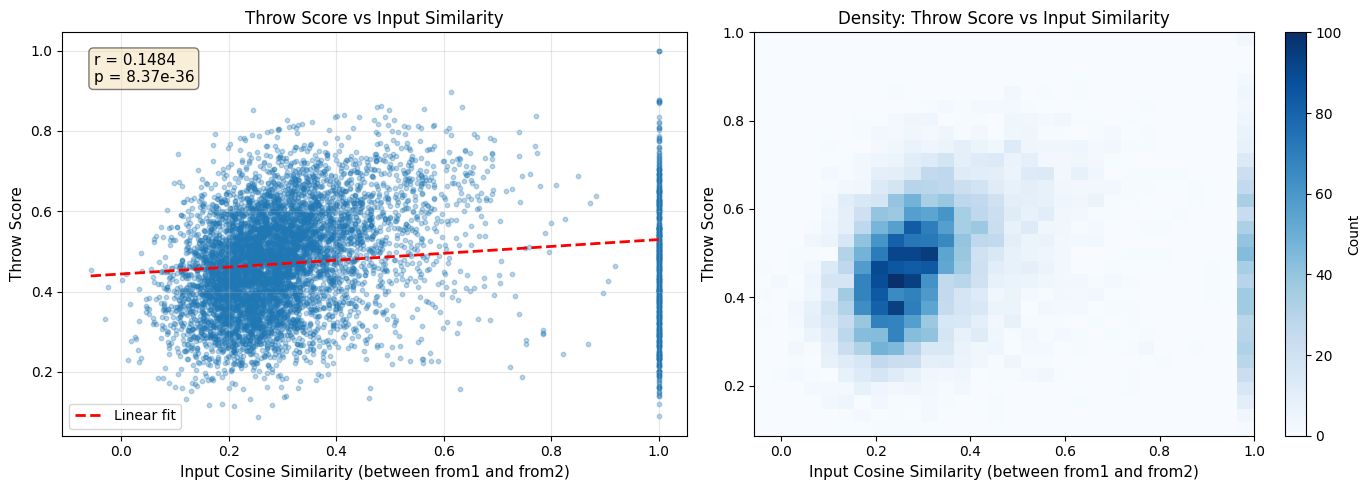


Linear Regression Analysis:
  Number of combinations: 7013
  Slope: 0.085735
  Intercept: 0.443776
  Pearson r: 0.1484
  R-squared: 0.0220
  P-value: 8.37e-36
  Standard error: 0.006825

  Input similarity range: [-0.0573, 1.0000]
  Mean input similarity: 0.3523

  Mean throw score when input sim < 0.3: 0.4416 (n=3838)
  Mean throw score when input sim > 0.7: 0.4659 (n=622)


In [ ]:
# Plot throw score vs cosine similarity of input vectors for ALL combinations
from scipy import stats

# Compute input similarity for all combinations
input_similarities = []
throw_scores = []

for entry in throw_scores_all:
    from1, from2 = entry['from1'], entry['from2']
    if from1 in embeddings and from2 in embeddings:
        input_sim = cosine_similarity(embeddings[from1], embeddings[from2])
        input_similarities.append(input_sim)
        throw_scores.append(entry['throw_score'])

input_similarities = np.array(input_similarities)
throw_scores = np.array(throw_scores)

# Compute linear regression with p-value
slope, intercept, r_value, p_value, std_err = stats.linregress(input_similarities, throw_scores)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Scatter plot
ax1 = axes[0]
ax1.scatter(input_similarities, throw_scores, alpha=0.3, s=10)
ax1.set_xlabel('Input Cosine Similarity (between from1 and from2)', fontsize=11)
ax1.set_ylabel('Throw Score', fontsize=11)
ax1.set_title('Throw Score vs Input Similarity', fontsize=12)

# Add regression line
x_line = np.linspace(input_similarities.min(), input_similarities.max(), 100)
y_line = slope * x_line + intercept
ax1.plot(x_line, y_line, 'r--', linewidth=2, label=f'Linear fit')

# Display stats on plot
stats_str = f'r = {r_value:.4f}\np = {p_value:.2e}' if p_value < 0.001 else f'r = {r_value:.4f}\np = {p_value:.4f}'
ax1.text(0.05, 0.95, stats_str, transform=ax1.transAxes, 
         fontsize=11, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
ax1.legend()
ax1.grid(alpha=0.3)

# Right: 2D histogram / heatmap for density
ax2 = axes[1]
h = ax2.hist2d(input_similarities, throw_scores, bins=30, cmap='Blues')
plt.colorbar(h[3], ax=ax2, label='Count')
ax2.set_xlabel('Input Cosine Similarity (between from1 and from2)', fontsize=11)
ax2.set_ylabel('Throw Score', fontsize=11)
ax2.set_title('Density: Throw Score vs Input Similarity', fontsize=12)

plt.tight_layout()
plt.show()

print(f"\nLinear Regression Analysis:")
print(f"  Number of combinations: {len(throw_scores)}")
print(f"  Slope: {slope:.6f}")
print(f"  Intercept: {intercept:.6f}")
print(f"  Pearson r: {r_value:.4f}")
print(f"  R-squared: {r_value**2:.4f}")
print(f"  P-value: {p_value:.2e}")
print(f"  Standard error: {std_err:.6f}")
print(f"\n  Input similarity range: [{input_similarities.min():.4f}, {input_similarities.max():.4f}]")
print(f"  Mean input similarity: {input_similarities.mean():.4f}")

# Additional insight: what happens at extremes?
low_sim_mask = input_similarities < 0.3
high_sim_mask = input_similarities > 0.7
print(f"\n  Mean throw score when input sim < 0.3: {throw_scores[low_sim_mask].mean():.4f} (n={low_sim_mask.sum()})")
print(f"  Mean throw score when input sim > 0.7: {throw_scores[high_sim_mask].mean():.4f} (n={high_sim_mask.sum()})")

In [ ]:
# Pseudo-sink analysis
# A pseudo-sink is a resource that, when combined with many resources, produces the same result
# Score = combinations / unique_results (higher = more sink-like)

# First, build a set of unique combinations (ignoring input order)
# Key: (sorted inputs as tuple, result)
unique_combinations_set = set()
unique_combinations_list = []

for entry in throw_scores_all:
    # Create canonical key (sorted inputs + result)
    inputs = tuple(sorted([entry['from1'], entry['from2']]))
    key = (inputs, entry['result'])
    
    if key not in unique_combinations_set:
        unique_combinations_set.add(key)
        unique_combinations_list.append(entry)

print(f"Total combinations: {len(throw_scores_all)}")
print(f"Unique combinations (ignoring input order): {len(unique_combinations_list)}")

# Now build combinations_by_resource using only unique combinations
unique_combos_by_resource = defaultdict(list)

for entry in unique_combinations_list:
    # Add to both input resources
    unique_combos_by_resource[entry['from1']].append(entry)
    unique_combos_by_resource[entry['from2']].append(entry)

# Compute pseudo-sink stats
pseudo_sink_stats = []

for resource, combos in unique_combos_by_resource.items():
    # Count unique "other" resources this resource combines with
    other_resources = set()
    for c in combos:
        other = c['from2'] if c['from1'] == resource else c['from1']
        other_resources.add(other)
    
    n_combinations = len(combos)  # Unique combinations involving this resource
    n_unique_partners = len(other_resources)  # Unique resources it combines with
    unique_results = set(c['result'] for c in combos)
    n_unique_results = len(unique_results)
    
    # Pseudo-sink score: ratio of combinations to unique results
    # A perfect sink would have many combinations but only 1 unique result
    pseudo_sink_score = n_combinations / n_unique_results if n_unique_results > 0 else 0
    
    pseudo_sink_stats.append({
        'resource': resource,
        'n_combinations': n_combinations,
        'n_unique_partners': n_unique_partners,
        'n_unique_results': n_unique_results,
        'pseudo_sink_score': pseudo_sink_score,
        'combinations': combos,
        'unique_results': unique_results,
    })

# Filter by 5+ combinations and sort by pseudo-sink score
MIN_COMBOS = 5
filtered_sinks = [r for r in pseudo_sink_stats if r['n_combinations'] >= MIN_COMBOS]
sorted_sinks = sorted(filtered_sinks, key=lambda x: x['pseudo_sink_score'], reverse=True)

print(f"\nFiltered to {len(filtered_sinks)} resources with {MIN_COMBOS}+ unique combinations")
print()

print("=" * 120)
print("TOP 10 PSEUDO-SINKS")
print("(Resources that produce few unique results despite many unique combinations)")
print("=" * 120)
print(f"{'Rank':<6} {'Resource':<30} {'Unique Combos':>14} {'Unique Partners':>16} {'Unique Results':>16} {'Sink Score':>12}")
print("-" * 120)

for i, r in enumerate(sorted_sinks[:10], 1):
    print(f"{i:<6} {r['resource']:<30} {r['n_combinations']:>14} {r['n_unique_partners']:>16} {r['n_unique_results']:>16} {r['pseudo_sink_score']:>12.2f}")

# Show details for top 10
print("\n" + "#" * 120)
print("DETAILED BREAKDOWN OF TOP 10 PSEUDO-SINKS")
print("#" * 120)

for i, r in enumerate(sorted_sinks[:10], 1):
    print(f"\n{'=' * 120}")
    print(f"#{i}: {r['resource']}")
    print(f"{'=' * 120}")
    print(f"  Unique Combinations: {r['n_combinations']}, Unique Partners: {r['n_unique_partners']}, Unique Results: {r['n_unique_results']}, Sink Score: {r['pseudo_sink_score']:.2f}")
    print()
    
    # Group combinations by result
    combos_by_result = defaultdict(list)
    for c in r['combinations']:
        combos_by_result[c['result']].append(c)
    
    # Sort results by count (most common first)
    sorted_results = sorted(combos_by_result.items(), key=lambda x: len(x[1]), reverse=True)
    
    print(f"  Results (sorted by frequency):")
    print(f"  {'-' * 110}")
    
    for result, combos in sorted_results:
        print(f"\n  → {result} ({len(combos)} combinations):")
        # Show first few combinations for this result
        for c in combos[:5]:
            other = c['from2'] if c['from1'] == r['resource'] else c['from1']
            print(f"      {r['resource']} + {other} → {result} (score: {c['throw_score']:.4f})")
        if len(combos) > 5:
            print(f"      ... and {len(combos) - 5} more")

Total combinations: 7013
Unique combinations (ignoring input order): 7013

Filtered to 771 resources with 5+ unique combinations

TOP 10 PSEUDO-SINKS
(Resources that produce few unique results despite many unique combinations)
Rank   Resource                        Unique Combos  Unique Partners   Unique Results   Sink Score
------------------------------------------------------------------------------------------------------------------------
1      Fable                                       6                5                1         6.00
2      Polygamy                                    5                5                1         5.00
3      Pandemonium                                 9                8                2         4.50
4      Pushover                                    7                6                2         3.50
5      Muse                                        9                8                3         3.00
6      Coral                                       6

In [ ]:
# Lookup specific resource: "Opensource"
lookup_resource = "Opensource"

# Find in pseudo_sink_stats
sink_dict = {r['resource']: r for r in pseudo_sink_stats}

if lookup_resource in sink_dict:
    r = sink_dict[lookup_resource]
    
    # Find rank in sorted list
    rank = next((i+1 for i, x in enumerate(sorted_sinks) if x['resource'] == lookup_resource), None)
    
    print("=" * 120)
    print(f"PSEUDO-SINK DATA FOR: {lookup_resource}")
    print("=" * 120)
    
    if rank:
        print(f"  Rank: {rank} / {len(sorted_sinks)} (among resources with {MIN_COMBOS}+ combinations)")
    else:
        print(f"  Rank: N/A (fewer than {MIN_COMBOS} combinations)")
    
    print(f"  Unique Combinations: {r['n_combinations']}")
    print(f"  Unique Partners: {r['n_unique_partners']}")
    print(f"  Unique Results: {r['n_unique_results']}")
    print(f"  Pseudo-Sink Score: {r['pseudo_sink_score']:.2f}")
    print()
    
    # Group combinations by result
    combos_by_result = defaultdict(list)
    for c in r['combinations']:
        combos_by_result[c['result']].append(c)
    
    # Sort results by count (most common first)
    sorted_results = sorted(combos_by_result.items(), key=lambda x: len(x[1]), reverse=True)
    
    print(f"  Results (sorted by frequency):")
    print(f"  {'-' * 110}")
    
    for result, combos in sorted_results:
        print(f"\n  → {result} ({len(combos)} combinations):")
        # Show all combinations for this result
        for c in combos:
            other = c['from2'] if c['from1'] == lookup_resource else c['from1']
            print(f"      {lookup_resource} + {other} → {result} (score: {c['throw_score']:.4f})")
else:
    print(f"Resource '{lookup_resource}' not found in the combinations data.")

PSEUDO-SINK DATA FOR: Opensource
  Rank: 228 / 771 (among resources with 5+ combinations)
  Unique Combinations: 135
  Unique Partners: 134
  Unique Results: 93
  Pseudo-Sink Score: 1.45

  Results (sorted by frequency):
  --------------------------------------------------------------------------------------------------------------

  → Linux (27 combinations):
      Opensource + All → Linux (score: 0.3970)
      Opensource + Battleflag → Linux (score: 0.3758)
      Opensource + Empire → Linux (score: 0.4259)
      Opensource + Euro → Linux (score: 0.3881)
      Opensource + Industry → Linux (score: 0.3647)
      Opensource + L → Linux (score: 0.4009)
      Opensource + Legend → Linux (score: 0.3618)
      Opensource + Logo → Linux (score: 0.4102)
      Opensource + Mosaic → Linux (score: 0.3479)
      Opensource + Obsession → Linux (score: 0.3434)
      Opensource + Opensource → Linux (score: 0.3715)
      Opensource + Opensource → Linux (score: 0.3715)
      Opensource + Rl → Linux (

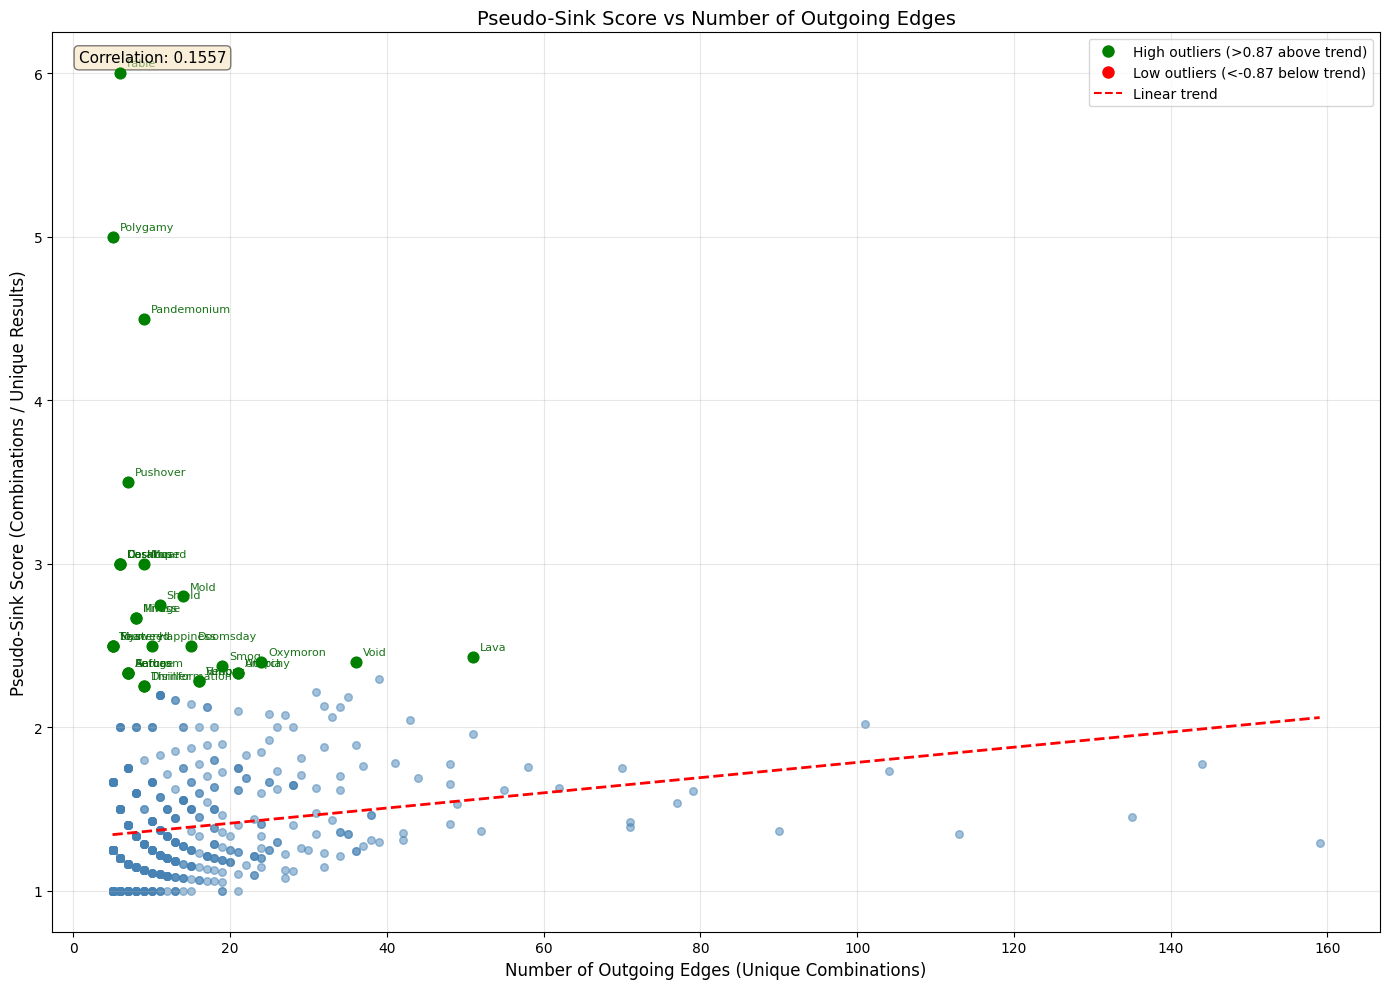


High outliers (30 resources with unusually HIGH sink scores):
  Muse                           edges=9      score=3.00 (expected=1.36, residual=+1.64)
  Lava                           edges=51     score=2.43 (expected=1.56, residual=+0.87)
  Smog                           edges=19     score=2.38 (expected=1.41, residual=+0.97)
  Void                           edges=36     score=2.40 (expected=1.49, residual=+0.91)
  Thriller                       edges=9      score=2.25 (expected=1.36, residual=+0.89)
  Mirage                         edges=8      score=2.67 (expected=1.36, residual=+1.31)
  Doomsday                       edges=15     score=2.50 (expected=1.39, residual=+1.11)
  Utopia                         edges=21     score=2.33 (expected=1.42, residual=+0.92)
  Venom                          edges=16     score=2.29 (expected=1.39, residual=+0.89)
  Refuge                         edges=7      score=2.33 (expected=1.35, residual=+0.98)
  Coral                          edges=6      s

In [ ]:
# Plot pseudo-sink score vs number of outgoing edges (combinations)
# Filter to resources with MIN_COMBOS+ combinations

outgoing_edges = np.array([r['n_combinations'] for r in filtered_sinks])
sink_scores = np.array([r['pseudo_sink_score'] for r in filtered_sinks])
names = [r['resource'] for r in filtered_sinks]

plt.figure(figsize=(14, 10))
plt.scatter(outgoing_edges, sink_scores, alpha=0.5, s=30, c='steelblue')

# Fit a trend line
z = np.polyfit(outgoing_edges, sink_scores, 1)
p = np.poly1d(z)
x_line = np.linspace(outgoing_edges.min(), outgoing_edges.max(), 100)
plt.plot(x_line, p(x_line), 'r--', linewidth=2, label=f'Linear fit: y = {z[0]:.4f}x + {z[1]:.4f}')

# Calculate residuals to find outliers
predicted = p(outgoing_edges)
residuals = sink_scores - predicted
std_residuals = np.std(residuals)

# Identify outliers (> 2 std deviations from trend)
outlier_threshold = 2 * std_residuals
high_outliers = residuals > outlier_threshold
low_outliers = residuals < -outlier_threshold

# Label high outliers (unusually high sink score for their edge count)
for i in np.where(high_outliers)[0]:
    plt.annotate(names[i], (outgoing_edges[i], sink_scores[i]), 
                 fontsize=8, alpha=0.9, color='darkgreen',
                 xytext=(5, 5), textcoords='offset points')
    plt.scatter([outgoing_edges[i]], [sink_scores[i]], c='green', s=60, zorder=5)

# Label low outliers (unusually low sink score for their edge count)
for i in np.where(low_outliers)[0]:
    plt.annotate(names[i], (outgoing_edges[i], sink_scores[i]), 
                 fontsize=8, alpha=0.9, color='darkred',
                 xytext=(5, -10), textcoords='offset points')
    plt.scatter([outgoing_edges[i]], [sink_scores[i]], c='red', s=60, zorder=5)

# Also label top 5 by sink score regardless of outlier status
top_5_indices = np.argsort(sink_scores)[-5:]
for i in top_5_indices:
    if not high_outliers[i]:  # Don't double-label
        plt.annotate(names[i], (outgoing_edges[i], sink_scores[i]), 
                     fontsize=8, alpha=0.8, color='purple',
                     xytext=(5, 5), textcoords='offset points')

plt.xlabel('Number of Outgoing Edges (Unique Combinations)', fontsize=12)
plt.ylabel('Pseudo-Sink Score (Combinations / Unique Results)', fontsize=12)
plt.title('Pseudo-Sink Score vs Number of Outgoing Edges', fontsize=14)
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

# Add correlation
correlation = np.corrcoef(outgoing_edges, sink_scores)[0, 1]
plt.text(0.02, 0.98, f'Correlation: {correlation:.4f}', transform=plt.gca().transAxes,
         fontsize=11, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Add legend for outlier colors
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='green', markersize=10, label=f'High outliers (>{outlier_threshold:.2f} above trend)'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=10, label=f'Low outliers (<{-outlier_threshold:.2f} below trend)'),
    Line2D([0], [0], color='red', linestyle='--', label='Linear trend'),
]
plt.legend(handles=legend_elements, loc='upper right')

plt.tight_layout()
plt.show()

# Print outlier summary
print(f"\nHigh outliers ({high_outliers.sum()} resources with unusually HIGH sink scores):")
for i in np.where(high_outliers)[0]:
    print(f"  {names[i]:<30} edges={outgoing_edges[i]:<6} score={sink_scores[i]:.2f} (expected={predicted[i]:.2f}, residual=+{residuals[i]:.2f})")

print(f"\nLow outliers ({low_outliers.sum()} resources with unusually LOW sink scores):")
for i in np.where(low_outliers)[0]:
    print(f"  {names[i]:<30} edges={outgoing_edges[i]:<6} score={sink_scores[i]:.2f} (expected={predicted[i]:.2f}, residual={residuals[i]:.2f})")

In [ ]:
import sqlite3

conn = sqlite3.connect('global.db')
cursor = conn.cursor()

cursor.execute("""
    SELECT DISTINCT firstWord, secondWord, resultName
    FROM combinations
    WHERE LOWER(firstWord) = 'porcupine squad' 
       OR LOWER(secondWord) = 'porcupine squad'
       OR LOWER(resultName) = 'porcupine squad'
    ORDER BY resultName
"""
)
print(f"{'First Word':<30} {'Second Word':<30} {'Result':<30}")
print("-" * 90)
for row in cursor.fetchall():
    print(f"{row[0]:<30} {row[1]:<30} {row[2]:<30}")

conn.close()

First Word                     Second Word                    Result                        
------------------------------------------------------------------------------------------
Porcupine squad                Depeche mode                   Darkwave                      
Neon genesis                   Porcupine squad                Evangelion Quill              
Porcupine squad                Neon genesis                   Evangelion Quill              
Porcupine squad                Bdsm musician                  Nineinchnails                 
Prickly harmony                Army                           Porcupine Squad               
Porcupine squad                Bdsm wedding                   Prickly Bondage               
Porcupine squad                Bdsm art                       Prickly Bondage               
Porcupine squad                Bdsm relationship              Prickly Bondage               
Porcupine squad                Porcelain figurine             Prickly Do

In [ ]:
# Find words that appear in their combination results (e.g., "Spider" + X = "Spiderman")
# These are "prefix/suffix" words that tend to compound with other words

# Use unique combinations to avoid duplicates
substring_stats = defaultdict(lambda: {'total_combos': 0, 'substring_matches': 0, 'examples': []})

for entry in unique_combinations_list:
    from1 = entry['from1']
    from2 = entry['from2']
    result = entry['result'].lower()
    
    # Check if from1 appears as substring in result (case-insensitive)
    from1_in_result = from1.lower() in result and from1.lower() != result
    # Check if from2 appears as substring in result (case-insensitive)
    from2_in_result = from2.lower() in result and from2.lower() != result
    
    # Track stats for from1
    substring_stats[from1]['total_combos'] += 1
    if from1_in_result:
        substring_stats[from1]['substring_matches'] += 1
        substring_stats[from1]['examples'].append((from1, from2, entry['result']))
    
    # Track stats for from2
    substring_stats[from2]['total_combos'] += 1
    if from2_in_result:
        substring_stats[from2]['substring_matches'] += 1
        substring_stats[from2]['examples'].append((from1, from2, entry['result']))

# Calculate ratio and filter
substring_results = []
for word, stats in substring_stats.items():
    if stats['total_combos'] >= 5:  # Filter by minimum combinations
        ratio = stats['substring_matches'] / stats['total_combos']
        substring_results.append({
            'word': word,
            'total_combos': stats['total_combos'],
            'substring_matches': stats['substring_matches'],
            'ratio': ratio,
            'examples': stats['examples']
        })

# Sort by number of substring matches (descending)
sorted_by_matches = sorted(substring_results, key=lambda x: x['substring_matches'], reverse=True)

print("=" * 120)
print("WORDS THAT APPEAR IN THEIR COMBINATION RESULTS (TOP 30 BY COUNT)")
print("(e.g., 'Spider' + 'Hero' = 'Spiderman')")
print("=" * 120)
print(f"{'Rank':<6} {'Word':<25} {'Substring Matches':>18} {'Total Combos':>14} {'Ratio':>10}")
print("-" * 120)

for i, r in enumerate(sorted_by_matches[:30], 1):
    print(f"{i:<6} {r['word']:<25} {r['substring_matches']:>18} {r['total_combos']:>14} {r['ratio']:>10.2%}")

# Show examples for top 10
print("\n" + "#" * 120)
print("EXAMPLES FOR TOP 10 SUBSTRING WORDS")
print("#" * 120)

for i, r in enumerate(sorted_by_matches[:10], 1):
    print(f"\n{'=' * 120}")
    print(f"#{i}: {r['word']} ({r['substring_matches']} matches / {r['total_combos']} combos = {r['ratio']:.1%})")
    print(f"{'=' * 120}")
    
    # Show up to 10 examples
    for j, (f1, f2, result) in enumerate(r['examples'][:10], 1):
        print(f"  {j:2}. {f1} + {f2} = {result}")
    
    if len(r['examples']) > 10:
        print(f"  ... and {len(r['examples']) - 10} more examples")

WORDS THAT APPEAR IN THEIR COMBINATION RESULTS (TOP 30 BY COUNT)
(e.g., 'Spider' + 'Hero' = 'Spiderman')
Rank   Word                       Substring Matches   Total Combos      Ratio
------------------------------------------------------------------------------------------------------------------------
1      L                                         76            113     67.26%
2      Cat                                       30            159     18.87%
3      Bl                                        18             27     66.67%
4      Maid                                       8             19     42.11%
5      Water                                      4            104      3.85%
6      Dragon                                     4             23     17.39%
7      Neko                                       4             17     23.53%
8      Bdsm                                       4             90      4.44%
9      Mud                                        3             58      